In [ ]:

import os
import math
import random
from typing import Tuple, List, Dict  # Only for type hints, not for instantiation
import copy
import time
import psutil
import inspect
import gc

import h5py
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════════════
# CONDITIONAL IMPORTS - Only import what you need based on backend
# ═══════════════════════════════════════════════════════════════════════════════

# TensorFlow/Keras imports (always needed for Keras backend)
import tensorflow as tf
from tensorflow.keras import mixed_precision

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, top_k_accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

# ═══════════════════════════════════════════════════════════════════════════════
# PyTorch imports - ONLY if using PyTorch backend
# Comment these out if using Keras
# ═══════════════════════════════════════════════════════════════════════════════
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader, random_split
# from torch.nn.utils import weight_norm

# Set device for pytorch
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)



In [ ]:
# Set device for TensorFlow
print("TensorFlow version:", tf.__version__)
print('Keras version:', tf.keras.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))
device = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"
print("Device:", device)

In [ ]:
gc.collect()

In [ ]:

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
gc.collect()

## Configurations

In [ ]:
file_path = f'combined_matches.csv'
# file_path = f'combined_matches_2068, 2269, 2417.csv'

USE_PREPROCESSED = True
PREPROCESSED_DIR = 'preprocessed_data'  # Change path if needed for Kaggle: '/kaggle/input/preprocessed-sequences/'



N_ROWS = 4
N_COLS = 16
NUM_ZONES = N_ROWS * N_COLS

# Sequence & horizon
SEQ_LEN =100      # number of past frames used
FPS = 10            # adjust based on your data (often 25fps for football)
HORIZON_SECONDS =3 # predict location after 3/5 seconds
HORIZON_FRAMES = HORIZON_SECONDS * FPS

# Training params
BATCH_SIZE =256
LR = 5e-4   # 🔧 FIXED: Lowered from 3e-3 to 1e-4 for stability
EPOCHS =40
PATIENCE = 3 # for early stopping

# Enhanced features for better zone prediction
# FEATURE_COLS = [
#     # Position
#     "x_normalized", "y_normalized",

#     # Basic movement
#     "dx", "dy", "speed_normalized", "acceleration",
#     "movement_angle",

#     # # Multi-window velocities (NEW)
#     "dx_avg_3", "dy_avg_3", "dx_avg_5", "dy_avg_5", "dx_avg_10", "dy_avg_10",
#     "speed_avg_3", "speed_avg_5", "speed_avg_10",

#     # Movement trends (NEW)
#     "acceleration_trend", "angle_change", "angle_stability", "speed_change_rate",

#     # Spatial context
#     "distance_from_center", "distance_from_goal_home", "distance_from_goal_away",
#     "distance_from_sideline",

#     # Ball & team
#     "distance_to_ball", "ball_possession_proximity", "team_has_possession", "team_spread",

#     'home_score', 'away_score','nearest_opponent_1', 'nearest_opponent_2', 'nearest_opponent_3', 
#     'defensive_line_distance','team_centroid_distance',

#     "is_goalkeeper","is_defender","is_midfielder","is_forward","has_possession","team_has_possession","opponent_has_possession"


# ]
FEATURE_COLS = [
    "x_normalized", "y_normalized",
    "dx", "dy", "speed_normalized", "acceleration",
    "movement_angle",
    "dx_avg_3", "dy_avg_3", "dx_avg_5", "dy_avg_5", "dx_avg_10", "dy_avg_10",
    "speed_avg_3", "speed_avg_5", "speed_avg_10",
    "acceleration_trend", "angle_change", "angle_stability", "speed_change_rate",
    "distance_from_center", "distance_from_goal_home", "distance_from_goal_away",
    "distance_from_sideline",
]
# FEATURE_COLS = [
#     "x_normalized", "y_normalized",
#     "dx", "dy", "speed_normalized",
#     "movement_angle",
#     # Keep smoothed averages, drop raw acceleration trends
#     "dx_avg_5", "dy_avg_5", "speed_avg_5",
#     "distance_from_goal_home", "distance_from_center"
# ]

coord_cols=("x_normalized", "y_normalized")

some_number= 42

worker_num=4

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL SELECTION
# ═══════════════════════════════════════════════════════════════════════════════
# Available MODEL_TYPE options:
#   - "Keras_tcn"     : Keras TCN for classification/regression
#   - "MDN_TCN"       : 🆕 Mixture Density Network (multi-modal probabilistic)
# ═══════════════════════════════════════════════════════════════════════════════

MODEL_TYPE = "MDN_TCN"  # Change to "MDN_TCN" for probabilistic predictions
BACKEND = "keras"       # keras/torch

# Configuration for enhanced training
USE_COSINE_LR = True           # Toggle cosine LR vs ReduceLROnPlateau
WARMUP_EPOCHS = 5              # Linear warmup epochs
LABEL_SMOOTHING = 0.1          # Label smoothing for classification (0 = off)
MAX_LR = LR                # Peak learning rate
MIN_LR = 1e-5                  # Final learning rate

# ═══════════════════════════════════════════════════════════════════════════════
# MDN-SPECIFIC CONFIGURATION (only used when MODEL_TYPE == "MDN_TCN")
# ═══════════════════════════════════════════════════════════════════════════════
MDN_NUM_MIXTURES = 5      # Number of Gaussian components (K)
MDN_SIGMA_MIN = 1e-4      # Minimum sigma to prevent collapse
MDN_LEARNING_RATE = 1e-4  # Lower LR for MDN stability

# ═══════════════════════════════════════════════════════════════════════════════
# CO_ORDINATES FLAG
# ═══════════════════════════════════════════════════════════════════════════════
CO_ORDINATES = True
if MODEL_TYPE == "MDN_TCN":   
    print("⚠️  MDN_TCN selected: CO_ORDINATES auto-set to True")
    CO_ORDINATES = True  # MDN always uses coordinates

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
print(f"{'═'*60}")
print(f"📋 CONFIGURATION SUMMARY")
print(f"{'═'*60}")
print(f"  • Model: {MODEL_TYPE}")
print(f"  • Framework: {BACKEND}")
print(f"  • Target: {'Coordinates (x,y)' if CO_ORDINATES else 'Zones (classification)'}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Horizon: {HORIZON_SECONDS}s ({HORIZON_FRAMES} frames)")
print(f"  • Grid: {N_ROWS}x{N_COLS} = {NUM_ZONES} zones")
print(f"  • Features: {len(FEATURE_COLS)}")
if MODEL_TYPE == "MDN_TCN":
    print(f"  • MDN Mixtures: {MDN_NUM_MIXTURES}")
print(f"{'═'*60}")

In [ ]:
def xy_to_zone_vectorized(xs, ys, n_rows=N_ROWS, n_cols=N_COLS, flip_y=False):
    xs = np.asarray(xs)
    ys = np.asarray(ys)

    if flip_y:
        ys = 1 - ys

    row = np.clip((ys * n_rows).astype(int), 0, n_rows - 1)
    col = np.clip((xs * n_cols).astype(int), 0, n_cols - 1)
    return row * n_cols + col


In [ ]:
def split_by_match_df(df, train_frac=0.7, val_frac=0.15, seed=42, fixed_split=False):
    """
    Splits a dataframe into train/val/test by unique match_id.
    Ensures no leakage across matches.

    If fixed_split=True:
        3 matches -> train
        1 match   -> val
        1 match   -> test
    """
    unique_matches = df["match_id"].unique()
    np.random.seed(seed)
    np.random.shuffle(unique_matches)

    n_total = len(unique_matches)

    if fixed_split:
        if n_total < 5:
            raise ValueError("Need at least 5 unique matches for fixed split (3/1/1).")

        train_matches = unique_matches[:3]
        val_matches   = unique_matches[3:4]
        test_matches  = unique_matches[4:5]

    else:
        n_train = max(1, int(train_frac * n_total))
        n_val   = max(1, int(val_frac * n_total))
        n_train = min(n_train, n_total - n_val)

        train_matches = unique_matches[:n_train]
        val_matches   = unique_matches[n_train:n_train + n_val]
        test_matches  = unique_matches[n_train + n_val:]

    train_df = df[df["match_id"].isin(train_matches)].reset_index(drop=True)
    val_df   = df[df["match_id"].isin(val_matches)].reset_index(drop=True)
    test_df  = df[df["match_id"].isin(test_matches)].reset_index(drop=True)

    print("Split matches:", len(train_matches), len(val_matches), len(test_matches))
    print("Rows per split:", len(train_df), len(val_df), len(test_df))

    return train_df, val_df, test_df


## Keras Sequence & Keras

In [ ]:
def keras_sequence_generator(df, feature_cols, scaler, seq_len, horizon,
                             coordinate_targets, n_rows=None, n_cols=None):
    """
    Generator that yields sequences one by one (or in small batches) instead of storing all.
    """
    for _, player_df in df.groupby(["match_id", "player_id"]):
        feats = player_df[feature_cols].values.astype(np.float32)
        if scaler is not None:
            feats = scaler.transform(feats)
        coords = player_df[list(coord_cols)].values.astype(np.float32)

        if coordinate_targets:
            # regression: dx, dy
            for i in range(len(player_df) - seq_len - horizon + 1):
                seq = feats[i:i+seq_len]
                t_curr = i + seq_len - 1
                t_fut = t_curr + horizon
                # delta = coords[t_fut] - coords[t_curr]
                # yield seq, delta.astype(np.float32)
                yield seq, coords[t_fut].astype(np.float32)

        else:
            zones = xy_to_zone_vectorized(
                player_df["x_normalized"].values,
                player_df["y_normalized"].values,
                n_rows, n_cols
            )
            for i in range(len(player_df) - seq_len - horizon + 1):
                seq = feats[i:i+seq_len]
                t_fut = i + seq_len - 1 + horizon
                zone = zones[t_fut]
                yield seq, np.int32(zone)
print("Keras_seq_gen_done")

In [ ]:
def make_tf_dataset(df, batch_size, shuffle=False, coordinate_targets=False, repeat=False):

    min_frames_needed = SEQ_LEN + HORIZON_FRAMES
    df = df.groupby(["match_id", "player_id"]).filter(
        lambda x: len(x) >= min_frames_needed
    )
    """Optimized tf.data pipeline with parallel processing and known cardinality"""
    output_types = (tf.float32, tf.float32 if coordinate_targets else tf.int32)
    output_shapes = (
    (SEQ_LEN, len(FEATURE_COLS)),  # input sequence shape
    (2,) if coordinate_targets else ()  # regression: (2,), classification: scalar ()
)


    # 🔧 PRE-CALCULATE: Count sequences for progress bar
    total_sequences = 0
    for _, player_df in df.groupby(["match_id", "player_id"]):
        total_sequences += max(0, len(player_df) - SEQ_LEN - HORIZON_FRAMES + 1)

    expected_batches = total_sequences // batch_size
    print(f"   Dataset: {total_sequences:,} sequences → {expected_batches} batches")

    ds = tf.data.Dataset.from_generator(
        lambda: keras_sequence_generator(
            df, FEATURE_COLS, scaler, SEQ_LEN, HORIZON_FRAMES,
            coordinate_targets, n_rows=N_ROWS, n_cols=N_COLS
        ),
        output_types=output_types,
        output_shapes=output_shapes
    )

    if shuffle:
        ds = ds.shuffle(4096)  # 🔧 INCREASED: Better randomization

    # 🔧 OPTIMIZATION: Batch before cache for memory efficiency
    # ensure labels are always correct shape

    def map_fn(x, y):
        if coordinate_targets:
            y = tf.reshape(y, [-1])
        return x, y

    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    # 🔧 FIXED: drop_remainder=True prevents 'ran out of data' warnings
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    # Only repeat if requested (e.g. for training)
    if repeat:
        ds = ds.repeat()
        

    return ds,expected_batches
print("make_tf_done")

## Velocity addition Func

In [ ]:

def add_velocity_features(df):
    """Enhanced velocity and movement features for better coordinate prediction"""
    df = df.sort_values(["match_id", "player_id", "frame_number"])

    # === BASIC VELOCITY (existing) ===
    df["dx"] = df.groupby(["match_id", "player_id"])["x_normalized"].diff().fillna(0)
    df["dy"] = df.groupby(["match_id", "player_id"])["y_normalized"].diff().fillna(0)

    # Smooth velocities
    df["dx"] = df.groupby(["match_id", "player_id"])["dx"].rolling(3, min_periods=1).mean().reset_index(level=[0,1], drop=True)
    df["dy"] = df.groupby(["match_id", "player_id"])["dy"].rolling(3, min_periods=1).mean().reset_index(level=[0,1], drop=True)

    # === MULTI-WINDOW VELOCITY (NEW) ===
    for window in [3, 5, 10]:
        df[f"dx_avg_{window}"] = df.groupby(["match_id", "player_id"])["dx"].rolling(window, min_periods=1).mean().reset_index(level=[0,1], drop=True)
        df[f"dy_avg_{window}"] = df.groupby(["match_id", "player_id"])["dy"].rolling(window, min_periods=1).mean().reset_index(level=[0,1], drop=True)
        df[f"speed_avg_{window}"] = np.sqrt(df[f"dx_avg_{window}"]**2 + df[f"dy_avg_{window}"]**2)

    # === EXISTING FEATURES ===
    df["speed_normalized"] = np.sqrt(df["dx"]**2 + df["dy"]**2)
    df["acceleration"] = df.groupby(["match_id", "player_id"])["speed_normalized"].diff().fillna(0)
    df["movement_angle"] = np.arctan2(df["dy"], df["dx"])

    # === NEW: ACCELERATION TRENDS ===
    df["acceleration_trend"] = df.groupby(["match_id", "player_id"])["acceleration"].rolling(5, min_periods=1).mean().reset_index(level=[0,1], drop=True)

    # === NEW: DIRECTION PERSISTENCE ===
    df["angle_change"] = df.groupby(["match_id", "player_id"])["movement_angle"].diff().fillna(0)
    df["angle_stability"] = df.groupby(["match_id", "player_id"])["angle_change"].rolling(5, min_periods=1).std().reset_index(level=[0,1], drop=True).fillna(0)

    # === NEW: SPEED MOMENTUM ===
    df["speed_change_rate"] = df.groupby(["match_id", "player_id"])["speed_normalized"].diff().fillna(0)

    # === SPATIAL FEATURES (existing) ===
    df["distance_from_center"] = np.sqrt((df["x_normalized"] - 0.5)**2 + (df["y_normalized"] - 0.5)**2)
    df["distance_from_goal_home"] = df["x_normalized"]
    df["distance_from_goal_away"] = 1 - df["x_normalized"]
    df["distance_from_sideline"] = np.minimum(df["y_normalized"], 1 - df["y_normalized"])

    # === BALL & TEAM FEATURES (existing) ===
    if "team_spread" not in df.columns:
        df["team_spread"] = df.groupby(["match_id", "frame_number", "team_type"])["x_normalized"].transform("std").fillna(0)
    if "distance_to_ball" not in df.columns:
        df["distance_to_ball"] = 0.5
    if "ball_possession_proximity" not in df.columns:
        df["ball_possession_proximity"] = df["distance_to_ball"]

    print("\n📌 Enhanced velocity features added!")
    print(f"New multi-window features: dx_avg_3/5/10, dy_avg_3/5/10, speed_avg_3/5/10")
    print(f"New trend features: acceleration_trend, angle_change, angle_stability, speed_change_rate")

    return df

In [ ]:
def add_contextual_features(df):
    """Add contextual features based on game state"""
    # Time-based features
    df["period_progress"] = df["timestamp_seconds"] / df.groupby(["match_id", "period"])["timestamp_seconds"].transform("max")

    # Formation-based features (simplified)
    if "position_category" in df.columns:
        # Create position-based features
        position_encoding = {"goalkeeper": 0, "defender": 1, "midfielder": 2, "forward": 3, "unknown": 4}
        df["position_encoded"] = df["position_category"].map(position_encoding).fillna(4)
    else:
        df["position_encoded"] = 2  # default to midfielder
    print("\n📌 add_contextual_features sample:")
    print(df.head(5)[[
        "period_progress",
        "position_encoded"
    ]])

    return df

## Keras TCN enhanced

In [ ]:
try:
    # pylint: disable=E0611,E0401
    from tensorflow.keras.utils import register_keras_serializable
  # For recent Keras
except ImportError:
    # pylint: disable=E0611,E0401
    from tensorflow.keras.utils import register_keras_serializable  # For older versions

# pylint: disable=E0611,E0401
from tensorflow.keras import backend as K, Model, Input, optimizers
# pylint: disable=E0611,E0401
from tensorflow.keras import layers
# pylint: disable=E0611,E0401
from tensorflow.keras.layers import Activation, SpatialDropout1D, Lambda
# pylint: disable=E0611,E0401
from tensorflow.keras.layers import Layer, Conv1D, Dense, BatchNormalization, LayerNormalization


In [ ]:
import tensorflow as tf
import numpy as np

zone_coords = np.zeros((NUM_ZONES, 2), dtype=np.float32)

for z in range(NUM_ZONES):
    r = z // N_COLS
    c = z % N_COLS
    zone_coords[z] = [r, c]

ZONE_COORDS = tf.constant(zone_coords)  # (144, 2)

MAX_DIST = tf.constant(
    np.sqrt((N_ROWS - 1)**2 + (N_COLS - 1)**2),
    dtype=tf.float32
)

register_keras_serializable()
class SpatialCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, alpha=2.0, name="spatial_ce"):
        super().__init__(name=name)
        self.alpha = alpha
        self.ce = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            reduction="none"
        )

    def call(self, y_true, y_pred):
        # y_true: (batch,)
        # y_pred: (batch, num_zones)

        y_true = tf.cast(y_true, tf.int32)

        # 1️⃣ Standard CE
        ce_loss = self.ce(y_true, y_pred)  # (batch,)

        # 2️⃣ Predicted zone
        pred_zone = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        # 3️⃣ Look up grid coordinates
        true_xy = tf.gather(ZONE_COORDS, y_true)
        pred_xy = tf.gather(ZONE_COORDS, pred_zone)

        # 4️⃣ Grid distance
        dist = tf.norm(true_xy - pred_xy, axis=1)  # Euclidean

        # 5️⃣ Normalize + weight
        weight = 1.0 + self.alpha * (dist / MAX_DIST)

        return ce_loss * weight


In [ ]:
def focal_loss_sparse(gamma=2.0, alpha=0.25):
    """
    Focal Loss - helps with class imbalance.
    
    FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)
    
    Benefits:
        - Down-weights easy examples
        - Focuses learning on hard examples
        - Great for imbalanced datasets
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        # Get class probabilities
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes)
        
        # Compute focal weights
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        focal_weight = alpha * tf.pow(1.0 - p_t, gamma)
        
        # Cross entropy
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        

        return focal_weight * ce

    return loss
print("   • train_classification_model_enhanced - Full training function")

print("   • focal_loss_sparse - For class imbalance")

print("   • label_smoothing_sparse_categorical_crossentropy - Smoothed loss")

print("✅ Enhanced Classification Training Components Loaded")
print("   • WarmupCosineDecaySchedule - LR schedule for optimizer")

print("─" * 60)
print("   • CosineAnnealingWarmupScheduler - LR callback")
print("📦 Available Components:")

In [ ]:
register_keras_serializable()
def spatial_loss(y_true, y_pred, alpha=0.1):
    y_true = tf.squeeze(y_true)
    y_true = tf.cast(y_true, tf.int32)

    # Cross-entropy (stable, handled by TF)
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    # Cast CE to float32 explicitly (recommended with mixed precision)
    ce = tf.cast(ce, tf.float32)

    # True row/col
    true_r = tf.cast(y_true // N_COLS, tf.float32)
    true_c = tf.cast(y_true % N_COLS, tf.float32)

    # ---- IMPORTANT FIX HERE ----
    num_zones = tf.shape(y_pred)[-1]

    zones = tf.range(num_zones, dtype=tf.int32)   # ✅ int
    zones = tf.cast(zones, tf.float32)             # → float

    zone_r = tf.floor(zones / tf.cast(N_COLS, tf.float32))
    zone_c = tf.math.floormod(zones, tf.cast(N_COLS, tf.float32))

    # Expected predicted row/col
    y_pred_f = tf.cast(y_pred, tf.float32)         # align dtypes

    pred_r = tf.reduce_sum(y_pred_f * zone_r, axis=-1)
    pred_c = tf.reduce_sum(y_pred_f * zone_c, axis=-1)

    spatial_dist = tf.abs(true_r - pred_r) + tf.abs(true_c - pred_c)

    return ce + alpha * spatial_dist


In [ ]:
#CUSTOM LOSS FUNCTIONS FOR BETTER COORDINATE PREDICTION

def huber_loss_tf(delta=0.1):
    """
    Huber loss - less sensitive to outliers than MSE
    Better for coordinate prediction with occasional large errors
    """
    def loss(y_true, y_pred):
        error = y_true - y_pred
        is_small = tf.abs(error) <= delta
        squared_loss = 0.5 * tf.square(error)
        linear_loss = delta * (tf.abs(error) - 0.5 * delta)
        return tf.where(is_small, squared_loss, linear_loss)
    return loss

def weighted_mse_loss():
    """
    Weighted MSE that penalizes x and y errors differently
    (x-axis errors might be more critical in football)
    """
    def loss(y_true, y_pred):
        x_error = tf.square(y_true[:, 0] - y_pred[:, 0])
        y_error = tf.square(y_true[:, 1] - y_pred[:, 1])
        return 1.2 * x_error + 0.8 * y_error  # weight x-direction more
    return loss

print("✓ Custom loss functions loaded")

In [ ]:


# @misc{KerasTCN,
#   author = {Philippe Remy},
#   title = {Temporal Convolutional Networks for Keras},
#   year = {2020},
#   publisher = {GitHub},
#   journal = {GitHub repository},
#   howpublished = {\url{https://github.com/philipperemy/keras-tcn}},
# }



def is_power_of_two(num: int):
    return num != 0 and ((num & (num - 1)) == 0)


def adjust_dilations(dilations: list):
    if all([is_power_of_two(i) for i in dilations]):
        return dilations
    else:
        new_dilations = [2 ** i for i in dilations]
        return new_dilations


class ResidualBlock(Layer):

    def __init__(self,
                 dilation_rate: int,
                 nb_filters: int,
                 kernel_size: int,
                 padding: str,
                 activation: str = 'relu',
                 dropout_rate: float = 0,
                 kernel_initializer: str = 'he_normal',
                 use_batch_norm: bool = False,
                 use_layer_norm: bool = False,
                 **kwargs):
        """Defines the residual block for the WaveNet TCN
        Args:
            x: The previous layer in the model
            training: boolean indicating whether the layer should behave in training mode or in inference mode
            dilation_rate: The dilation power of 2 we are using for this residual block
            nb_filters: The number of convolutional filters to use in this block
            kernel_size: The size of the convolutional kernel
            padding: The padding used in the convolutional layers, 'same' or 'causal'.
            activation: The final activation used in o = Activation(x + F(x))
            dropout_rate: Float between 0 and 1. Fraction of the input units to drop.
            kernel_initializer: Initializer for the kernel weights matrix (Conv1D).
            use_batch_norm: Whether to use batch normalization in the residual layers or not.
            use_layer_norm: Whether to use layer normalization in the residual layers or not.
            kwargs: Any initializers for Layer class.
        """

        self.dilation_rate = dilation_rate
        self.nb_filters = nb_filters
        self.kernel_size = kernel_size
        self.padding = padding
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.use_batch_norm = use_batch_norm
        self.use_layer_norm = use_layer_norm
        self.kernel_initializer = kernel_initializer
        self.layers = []
        self.shape_match_conv = None
        self.res_output_shape = None
        self.final_activation = None
        self.batch_norm_layers = []
        self.layer_norm_layers = []

        super(ResidualBlock, self).__init__(**kwargs)

    def _build_layer(self, layer):
        """Helper function for building layer
        Args:
            layer: Appends layer to internal layer list and builds it based on the current output
                   shape of ResidualBlocK. Updates current output shape.
        """
        self.layers.append(layer)
        self.layers[-1].build(self.res_output_shape)
        self.res_output_shape = self.layers[-1].compute_output_shape(self.res_output_shape)

    def build(self, input_shape):

        with K.name_scope(self.name):  # name scope used to make sure weights get unique names
            self.layers = []
            self.res_output_shape = input_shape

            for k in range(2):  # dilated conv block.
                name = 'conv1D_{}'.format(k)
                with K.name_scope(name):  # name scope used to make sure weights get unique names
                    conv = Conv1D(
                        filters=self.nb_filters,
                        kernel_size=self.kernel_size,
                        dilation_rate=self.dilation_rate,
                        padding=self.padding,
                        name=name,
                        kernel_initializer=self.kernel_initializer
                    )
                    self._build_layer(conv)

                with K.name_scope('norm_{}'.format(k)):
                    if self.use_batch_norm:
                        bn_layer = BatchNormalization()
                        self.batch_norm_layers.append(bn_layer)
                        self._build_layer(bn_layer)
                    elif self.use_layer_norm:
                        ln_layer = LayerNormalization()
                        self.layer_norm_layers.append(ln_layer)
                        self._build_layer(ln_layer)

                with K.name_scope('act_and_dropout_{}'.format(k)):
                    self._build_layer(Activation(self.activation, name='Act_Conv1D_{}'.format(k)))
                    self._build_layer(SpatialDropout1D(rate=self.dropout_rate, name='SDropout_{}'.format(k)))

            if self.nb_filters != input_shape[-1]:
                # 1x1 conv to match the shapes (channel dimension).
                name = 'matching_conv1D'
                with K.name_scope(name):
                    # make and build this layer separately because it directly uses input_shape.
                    # 1x1 conv.
                    self.shape_match_conv = Conv1D(
                        filters=self.nb_filters,
                        kernel_size=1,
                        padding='same',
                        name=name,
                        kernel_initializer=self.kernel_initializer
                    )
            else:
                name = 'matching_identity'
                self.shape_match_conv = Lambda(lambda x: x, name=name)

            with K.name_scope(name):
                self.shape_match_conv.build(input_shape)
                self.res_output_shape = self.shape_match_conv.compute_output_shape(input_shape)

            self._build_layer(Activation(self.activation, name='Act_Conv_Blocks'))
            self.final_activation = Activation(self.activation, name='Act_Res_Block')
            self.final_activation.build(self.res_output_shape)  # probably isn't necessary

            # this is done to force Keras to add the layers in the list to self._layers
            for layer in self.layers:
                self.__setattr__(layer.name, layer)
            self.__setattr__(self.shape_match_conv.name, self.shape_match_conv)
            self.__setattr__(self.final_activation.name, self.final_activation)

            super(ResidualBlock, self).build(input_shape)  # done to make sure self.built is set True

    def call(self, inputs, training=None, **kwargs):
        """
        Returns: A tuple where the first element is the residual model tensor, and the second
                 is the skip connection tensor.
        """
        # https://arxiv.org/pdf/1803.01271.pdf  page 4, Figure 1 (b).
        # x1: Dilated Conv -> Norm -> Dropout (x2).
        # x2: Residual (1x1 matching conv - optional).
        # Output: x1 + x2.
        # x1 -> connected to skip connections.
        # x1 + x2 -> connected to the next block.
        #       input
        #     x1      x2
        #   conv1D    1x1 Conv1D (optional)
        #    ...
        #   conv1D
        #    ...
        #       x1 + x2
        x1 = inputs
        for layer in self.layers:
            training_flag = 'training' in dict(inspect.signature(layer.call).parameters)
            x1 = layer(x1, training=training) if training_flag else layer(x1)
        x2 = self.shape_match_conv(inputs)
        x1_x2 = self.final_activation(layers.add([x2, x1], name='Add_Res'))
        return [x1_x2, x1]

    def compute_output_shape(self, input_shape):
        return [self.res_output_shape, self.res_output_shape]


@register_keras_serializable()
class TCN(Layer):
    """Creates a TCN layer.

        Input shape:
            A 3D tensor with shape (batch_size, timesteps, input_dim).

        Args:
            nb_filters: The number of filters to use in the convolutional layers. Can be a list.
            kernel_size: The size of the kernel to use in each convolutional layer.
            dilations: The list of the dilations. Example is: [1, 2, 4, 8, 16, 32, 64].
            nb_stacks : The number of stacks of residual blocks to use.
            padding: The padding to use in the convolutional layers, 'causal' or 'same'.
            use_skip_connections: Boolean. If we want to add skip connections from input to each residual blocK.
            return_sequences: Boolean. Whether to return the last output in the output sequence, or the full sequence.
            activation: The activation used in the residual blocks o = Activation(x + F(x)).
            dropout_rate: Float between 0 and 1. Fraction of the input units to drop.
            kernel_initializer: Initializer for the kernel weights matrix (Conv1D).
            use_batch_norm: Whether to use batch normalization in the residual layers or not.
            use_layer_norm: Whether to use layer normalization in the residual layers or not.
            go_backwards: Boolean (default False). If True, process the input sequence backwards and
            return the reversed sequence.
            return_state: Boolean. Whether to return the last state in addition to the output. Default: False.
            kwargs: Any other arguments for configuring parent class Layer. For example "name=str", Name of the model.
                    Use unique names when using multiple TCN.
        Returns:
            A TCN layer.
        """

    def __init__(self,
                 nb_filters=64,
                 kernel_size=3,
                 nb_stacks=1,
                 dilations=(1, 2, 4, 8, 16, 32),
                 padding='causal',
                 use_skip_connections=True,
                 dropout_rate=0.0,
                 return_sequences=False,
                 activation='relu',
                 kernel_initializer='he_normal',
                 use_batch_norm=False,
                 use_layer_norm=False,
                 go_backwards=False,
                 return_state=False,
                 **kwargs):
        self.stateful = False  # TCN are not stateful. Keras requires this parameter.
        self.return_sequences = return_sequences
        self.dropout_rate = dropout_rate
        self.use_skip_connections = use_skip_connections
        self.dilations = dilations
        self.nb_stacks = nb_stacks
        self.kernel_size = kernel_size
        self.nb_filters = nb_filters
        self.activation_name = activation
        self.padding = padding
        self.kernel_initializer = kernel_initializer
        self.use_batch_norm = use_batch_norm
        self.use_layer_norm = use_layer_norm
        self.go_backwards = go_backwards
        self.return_state = return_state
        self.skip_connections = []
        self.residual_blocks = []
        self.layers_outputs = []
        self.build_output_shape = None
        self.slicer_layer = None  # in case return_sequence=False
        self.output_slice_index = None  # in case return_sequence=False
        self.padding_same_and_time_dim_unknown = False  # edge case if padding='same' and time_dim = None

        if self.use_batch_norm + self.use_layer_norm > 1:
            raise ValueError('Only one normalization can be specified at once.')

        if isinstance(self.nb_filters, list):
            assert len(self.nb_filters) == len(self.dilations)
            if len(set(self.nb_filters)) > 1 and self.use_skip_connections:
                raise ValueError('Skip connections are not compatible '
                                 'with a list of filters, unless they are all equal.')

        if padding != 'causal' and padding != 'same':
            raise ValueError("Only 'causal' or 'same' padding are compatible for this layer.")

        # initialize parent class
        super(TCN, self).__init__(**kwargs)

    @property
    def receptive_field(self):
        return 1 + 2 * (self.kernel_size - 1) * self.nb_stacks * sum(self.dilations)

    def tolist(self, shape):
        # noinspection PyBroadException
        try:
            return shape.as_list()
        except Exception:
            return list(shape)

    def build(self, input_shape):

        # member to hold current output shape of the layer for building purposes
        self.build_output_shape = input_shape

        # list to hold all the member ResidualBlocks
        self.residual_blocks = []
        total_num_blocks = self.nb_stacks * len(self.dilations)
        if not self.use_skip_connections:
            total_num_blocks += 1  # cheap way to do a false case for below

        for s in range(self.nb_stacks):
            for i, d in enumerate(self.dilations):
                res_block_filters = self.nb_filters[i] if isinstance(self.nb_filters, list) else self.nb_filters
                self.residual_blocks.append(ResidualBlock(dilation_rate=d,
                                                          nb_filters=res_block_filters,
                                                          kernel_size=self.kernel_size,
                                                          padding=self.padding,
                                                          activation=self.activation_name,
                                                          dropout_rate=self.dropout_rate,
                                                          use_batch_norm=self.use_batch_norm,
                                                          use_layer_norm=self.use_layer_norm,
                                                          kernel_initializer=self.kernel_initializer,
                                                          name='residual_block_{}'.format(len(self.residual_blocks))))
                # build newest residual block
                self.residual_blocks[-1].build(self.build_output_shape)
                self.build_output_shape = self.residual_blocks[-1].res_output_shape

        # this is done to force keras to add the layers in the list to self._layers
        for layer in self.residual_blocks:
            self.__setattr__(layer.name, layer)

        self.output_slice_index = None
        if self.padding == 'same':
            time = self.tolist(self.build_output_shape)[1]
            if time is not None:  # if time dimension is defined. e.g. shape = (bs, 500, input_dim).
                self.output_slice_index = int(self.tolist(self.build_output_shape)[1] / 2)
            else:
                # It will known at call time. c.f. self.call.
                self.padding_same_and_time_dim_unknown = True

        else:
            self.output_slice_index = -1  # causal case.
        self.slicer_layer = Lambda(lambda tt: tt[:, self.output_slice_index, :], name='Slice_Output')
        self.slicer_layer.build(self.tolist(self.build_output_shape))

    def compute_output_shape(self, input_shape):
        """
        Overridden in case keras uses it somewhere... no idea. Just trying to avoid future errors.
        """
        if not self.built:
            self.build(input_shape)
        if not self.return_sequences:
            batch_size = self.build_output_shape[0]
            batch_size = batch_size.value if hasattr(batch_size, 'value') else batch_size
            nb_filters = self.build_output_shape[-1]
            return [batch_size, nb_filters]
        else:
            # Compatibility tensorflow 1.x
            return [v.value if hasattr(v, 'value') else v for v in self.build_output_shape]

    def call(self, inputs, training=None, **kwargs):
        x = inputs

        if self.go_backwards:
            # reverse x in the time axis
            x = tf.reverse(x, axis=[1])

        self.layers_outputs = [x]
        self.skip_connections = []
        for res_block in self.residual_blocks:
            try:
                x, skip_out = res_block(x, training=training)
            except TypeError:  # compatibility with tensorflow 1.x
                x, skip_out = res_block(K.cast(x, 'float32'), training=training)
            self.skip_connections.append(skip_out)
            self.layers_outputs.append(x)

        if self.use_skip_connections:
            if len(self.skip_connections) > 1:
                # Keras: A merge layer should be called on a list of at least 2 inputs. Got 1 input.
                x = layers.add(self.skip_connections, name='Add_Skip_Connections')
            else:
                x = self.skip_connections[0]
            self.layers_outputs.append(x)

        if not self.return_sequences:
            # case: time dimension is unknown. e.g. (bs, None, input_dim).
            if self.padding_same_and_time_dim_unknown:
                self.output_slice_index = K.shape(self.layers_outputs[-1])[1] // 2
            x = self.slicer_layer(x)
            self.layers_outputs.append(x)
        return x

    def get_config(self):
        """
        Returns the config of a the layer. This is used for saving and loading from a model
        :return: python dictionary with specs to rebuild layer
        """
        config = super(TCN, self).get_config()
        config['nb_filters'] = self.nb_filters
        config['kernel_size'] = self.kernel_size
        config['nb_stacks'] = self.nb_stacks
        config['dilations'] = self.dilations
        config['padding'] = self.padding
        config['use_skip_connections'] = self.use_skip_connections
        config['dropout_rate'] = self.dropout_rate
        config['return_sequences'] = self.return_sequences
        config['activation'] = self.activation_name
        config['use_batch_norm'] = self.use_batch_norm
        config['use_layer_norm'] = self.use_layer_norm
        config['kernel_initializer'] = self.kernel_initializer
        config['go_backwards'] = self.go_backwards
        config['return_state'] = self.return_state
        return config


def compiled_tcn(num_feat,  # type: int
                 num_classes,  # type: int
                 nb_filters,  # type: int
                 kernel_size,  # type: int
                 dilations,  # type: List[int]
                 nb_stacks,  # type: int
                 max_len,  # type: int
                 output_len=1,  # type: int
                 padding='causal',  # type: str
                 use_skip_connections=False,  # type: bool
                 return_sequences=True,
                 regression=False,  # type: bool
                 dropout_rate=0.05,  # type: float
                 name='tcn',  # type: str,
                 kernel_initializer='he_normal',  # type: str,
                 activation='relu',  # type:str,
                 opt='adam',
                 lr=0.002,
                 use_batch_norm=False,
                 use_layer_norm=False):
    # type: (...) -> Model
    """Creates a compiled TCN model for a given task (i.e. regression or classification).
    Classification uses a sparse categorical loss. Please input class ids and not one-hot encodings.

    Args:
        num_feat: The number of features of your input, i.e. the last dimension of: (batch_size, timesteps, input_dim).
        num_classes: The size of the final dense layer, how many classes we are predicting.
        nb_filters: The number of filters to use in the convolutional layers.
        kernel_size: The size of the kernel to use in each convolutional layer.
        dilations: The list of the dilations. Example is: [1, 2, 4, 8, 16, 32, 64].
        nb_stacks : The number of stacks of residual blocks to use.
        max_len: The maximum sequence length, use None if the sequence length is dynamic.
        padding: The padding to use in the convolutional layers.
        use_skip_connections: Boolean. If we want to add skip connections from input to each residual blocK.
        return_sequences: Boolean. Whether to return the last output in the output sequence, or the full sequence.
        regression: Whether the output should be continuous or discrete.
        dropout_rate: Float between 0 and 1. Fraction of the input units to drop.
        activation: The activation used in the residual blocks o = Activation(x + F(x)).
        name: Name of the model. Useful when having multiple TCN.
        kernel_initializer: Initializer for the kernel weights matrix (Conv1D).
        opt: Optimizer name.
        lr: Learning rate.
        use_batch_norm: Whether to use batch normalization in the residual layers or not.
        use_layer_norm: Whether to use layer normalization in the residual layers or not.
    Returns:
        A compiled keras TCN.
    """

    dilations = adjust_dilations(dilations)

    input_layer = Input(shape=(max_len, num_feat))

    x = TCN(nb_filters, kernel_size, nb_stacks, dilations, padding,
            use_skip_connections, dropout_rate, return_sequences,
            activation, kernel_initializer, use_batch_norm, use_layer_norm,
            name=name)(input_layer)

    print('x.shape=', x.shape)

    def get_opt(lr=LR):
        if opt == 'adam':
            return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.)
        elif opt == 'rmsprop':
            return optimizers.RMSprop(learning_rate=lr, clipnorm=1.)
        else:
            raise Exception('Only Adam and RMSProp are available here')

    if not regression:
        # classification
        x = Dense(num_classes, activation='softmax')(x)  # ✅ Combine in one layer

        output_layer = x
        model = Model(input_layer, output_layer)

        # https://github.com/keras-team/keras/pull/11373
        # It's now in Keras@master but still not available with pip.
        # TODO remove later.
        # def accuracy(y_true, y_pred):
        #    if K.ndim(y_true) > 1:
        #         y_true = K.squeeze(y_true, axis=-1)

        #     # Ensure integer labels
        #     y_true = K.cast(y_true, 'int32')

        #     # Predicted class indices
        #     y_pred_labels = K.argmax(y_pred, axis=-1)
        #     y_pred_labels = K.cast(y_pred_labels, 'int32')

        # return K.mean(K.cast(K.equal(y_true, y_pred_labels), K.floatx()))
        model.compile(get_opt(LR), loss=focal_loss_sparse(gamma=2.0, alpha=0.25) , metrics=["sparse_categorical_accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)  ])
        # model.compile(get_opt(LR), loss= spatial_loss , metrics=["sparse_categorical_accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)  ])
        # model.compile(get_opt(), loss= SpatialCrossEntropy(alpha=2.0) , metrics=["sparse_categorical_accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)  ])
        # model.compile(get_opt(), loss='sparse_categorical_crossentropy', metrics=["sparse_categorical_accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)
    else:
        # regression
        x = Dense(num_classes)(x)
        x = Activation('linear')(x)

        output_layer = x
        model = Model(input_layer, output_layer)
        model.compile(get_opt(), loss='mean_squared_error', metrics=['mae'])
    print('model.x = {}'.format(input_layer.shape))
    print('model.y = {}'.format(output_layer.shape))
    return model


def tcn_full_summary(model: Model, expand_residual_blocks=True):
    import tensorflow as tf
    # 2.6.0-rc1, 2.5.0...
    versions = [int(v) for v in tf.__version__.split('-')[0].split('.')]
    if versions[0] <= 2 and versions[1] < 5:
        layers = model._layers.copy()  # store existing layers
        model._layers.clear()  # clear layers

        for i in range(len(layers)):
            if isinstance(layers[i], TCN):
                for layer in layers[i]._layers:
                    if not isinstance(layer, ResidualBlock):
                        if not hasattr(layer, '__iter__'):
                            model._layers.append(layer)
                    else:
                        if expand_residual_blocks:
                            for lyr in layer._layers:
                                if not hasattr(lyr, '__iter__'):
                                    model._layers.append(lyr)
                        else:
                            model._layers.append(layer)
            else:
                model._layers.append(layers[i])

        model.summary()  # print summary

        # restore original layers
        model._layers.clear()
        [model._layers.append(lyr) for lyr in layers]
    else:
        print('WARNING: tcn_full_summary: Compatible with tensorflow 2.5.0 or below.')
        print('Use tensorboard instead. Example in keras-tcn/tasks/tcn_tensorboard.py.')

### 🔄 Enhanced Training with Cosine LR Scheduler & Accuracy Improvements

Includes:
- **Cosine Annealing LR** with warmup
- **Label Smoothing** for better generalization
- **Mixup Augmentation** for regularization
- **Gradient Clipping** for stability

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENHANCED CLASSIFICATION TRAINING WITH COSINE LR SCHEDULER
# ═══════════════════════════════════════════════════════════════════════════════

import math

# ─────────────────────────────────────────────────────────────────────────────
# 1. COSINE ANNEALING LR SCHEDULER WITH WARMUP
# ─────────────────────────────────────────────────────────────────────────────

class CosineAnnealingWarmupScheduler(tf.keras.callbacks.Callback):
    """
    Cosine Annealing Learning Rate Scheduler with Linear Warmup.
    
    LR Schedule:
        - Warmup: Linear increase from min_lr to max_lr over warmup_epochs
        - Cosine: Smooth decay from max_lr to min_lr following cosine curve
    
    Benefits:
        - Smooth LR transitions prevent training instability
        - Warmup helps with large batch training
        - Cosine decay often outperforms step decay
    """
    
    def __init__(self, max_lr=1e-3, min_lr=1e-6, warmup_epochs=5, total_epochs=50, 
                 steps_per_epoch=None, verbose=1):
        super().__init__()
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.steps_per_epoch = steps_per_epoch
        self.verbose = verbose
        self.current_lr = min_lr
        self.history = {'lr': []}
        
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # Linear warmup
            self.current_lr = self.min_lr + (self.max_lr - self.min_lr) * (epoch / self.warmup_epochs)
        else:
            # Cosine annealing
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            self.current_lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        
        # Set the learning rate (compatible with Keras 3.x and older versions)
        try:
            # Keras 3.x / TF 2.16+
            self.model.optimizer.learning_rate.assign(self.current_lr)
        except (AttributeError, TypeError):
            # Fallback for older Keras versions
            tf.keras.backend.set_value(self.model.optimizer.learning_rate, self.current_lr)
        
        self.history['lr'].append(self.current_lr)
        
        if self.verbose:
            print(f"\n📈 Epoch {epoch+1}: LR = {self.current_lr:.2e}")
    
    def on_train_end(self, logs=None):
        if self.verbose:
            print(f"\n✅ Cosine LR Schedule complete. LR range: {self.max_lr:.2e} → {self.min_lr:.2e}")


class WarmupCosineDecaySchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Learning Rate Schedule for use directly with optimizer.
    Combines linear warmup with cosine decay.
    """
    
    def __init__(self, max_lr=1e-3, min_lr=1e-6, warmup_steps=1000, decay_steps=10000):
        super().__init__()
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.warmup_steps = warmup_steps
        self.decay_steps = decay_steps
        
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        
        # Warmup phase
        warmup_lr = self.min_lr + (self.max_lr - self.min_lr) * (step / self.warmup_steps)
        
        # Cosine decay phase
        decay_step = step - self.warmup_steps
        decay_progress = decay_step / self.decay_steps
        cosine_lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + tf.cos(math.pi * decay_progress))
        
        # Choose based on current step
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)
    
    def get_config(self):
        return {
            'max_lr': self.max_lr,
            'min_lr': self.min_lr,
            'warmup_steps': self.warmup_steps,
            'decay_steps': self.decay_steps
        }


# ─────────────────────────────────────────────────────────────────────────────
# 2. LABEL SMOOTHING LOSS (Improves generalization)
# ─────────────────────────────────────────────────────────────────────────────

def label_smoothing_sparse_categorical_crossentropy(smoothing=0.1):
    """
    Label Smoothing for classification - reduces overconfidence.
    
    Instead of [0, 0, 1, 0] → [0.025, 0.025, 0.925, 0.025]
    
    Benefits:
        - Prevents model from becoming overconfident
        - Improves generalization to unseen data
        - Acts as regularization
    """
    def loss(y_true, y_pred):
        num_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        y_true = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)

        # Convert sparse labels to one-hot
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        
        # Apply label smoothing
        y_true_smooth = y_true_one_hot * (1.0 - smoothing) + (smoothing / num_classes)
        
        # Categorical crossentropy
        return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)
    
    return loss


# ─────────────────────────────────────────────────────────────────────────────
# 2.5 FP16-COMPATIBLE TOPK ACCURACY METRIC
# ─────────────────────────────────────────────────────────────────────────────

class FP16SafeSparseTopKAccuracy(tf.keras.metrics.SparseTopKCategoricalAccuracy):
    """
    TopK accuracy metric that casts predictions to float32 for FP16 compatibility.
    Fixes: TypeError: Input 'predictions' of 'InTopKV2' Op has type float16
    """
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Cast predictions to float32 for TopK computation
        y_pred = tf.cast(y_pred, tf.float32)
        return super().update_state(y_true, y_pred, sample_weight)


# ─────────────────────────────────────────────────────────────────────────────
# 3. MIXUP DATA AUGMENTATION (Regularization)
# ─────────────────────────────────────────────────────────────────────────────

def mixup_data(x, y, alpha=0.2):
    """
    Mixup augmentation - creates virtual training examples.
    
    x_mixed = λ * x_i + (1-λ) * x_j
    y_mixed = λ * y_i + (1-λ) * y_j
    
    Benefits:
        - Strong regularization
        - Improves calibration
        - Better decision boundaries
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.shape[0]
    index = np.random.permutation(batch_size)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam


class MixupGenerator(tf.keras.utils.Sequence):
    """
    Data generator with Mixup augmentation for classification.
    """
    
    def __init__(self, x, y, batch_size=32, alpha=0.2, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.indices = np.arange(len(x))
        if shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return len(self.x) // self.batch_size
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        x_batch = self.x[batch_indices]
        y_batch = self.y[batch_indices]
        
        # Apply mixup
        if self.alpha > 0 and np.random.random() > 0.5:
            lam = np.random.beta(self.alpha, self.alpha)
            shuffle_indices = np.random.permutation(len(batch_indices))
            x_batch = lam * x_batch + (1 - lam) * x_batch[shuffle_indices]
            # For sparse labels, just use original (hard labels during mixup)
            # Or convert to soft labels if needed
        
        return x_batch, y_batch
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# ─────────────────────────────────────────────────────────────────────────────
# 4. ADDITIONAL ACCURACY IMPROVEMENTS (Focal Loss for Class Imbalance)
# ─────────────────────────────────────────────────────────────────────────────
# Note: train_classification_model_enhanced() has been integrated into train_model()
# ─────────────────────────────────────────────────────────────────────────────



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ✅ COSINE LR SCHEDULER NOW INTEGRATED INTO train_model()
# ═══════════════════════════════════════════════════════════════════════════════
#
# The enhanced training with Cosine LR Scheduler is now integrated into the 
# main train_model() function. No separate function call needed!
#
# When you call train_model() for classification (CO_ORDINATES=False):
#   - Automatically uses Cosine Annealing LR with 5-epoch warmup
#   - Applies Label Smoothing (0.1) for better generalization
#   - Adds Top-3 and Top-5 accuracy metrics
#   - Uses AdamW with weight decay and gradient clipping
#
# ═══════════════════════════════════════════════════════════════════════════════

# Configuration is now in train_model() - you can modify these values there:
# 
#   USE_COSINE_LR = True       # Toggle cosine LR (True) vs ReduceLROnPlateau (False)
#   WARMUP_EPOCHS = 5          # Linear warmup epochs
#   LABEL_SMOOTHING = 0.1      # Label smoothing for classification (0 = off)
#   MAX_LR = lr                # Peak learning rate (from function argument)
#   MIN_LR = 1e-6              # Final learning rate
#
# ═══════════════════════════════════════════════════════════════════════════════

print("✅ Cosine LR Scheduler integrated into train_model()")
print("\n📋 When training classification models:")
print("   • Cosine Annealing LR with warmup")
print("   • Label Smoothing: 0.1")
print("   • Metrics: accuracy, top3_acc, top5_acc")
print("   • AdamW with weight decay & gradient clipping")
print("\n💡 To customize, modify these variables in train_model():")
print("   • USE_COSINE_LR = True/False")
print("   • WARMUP_EPOCHS = 5")
print("   • LABEL_SMOOTHING = 0.1")
print("   • MAX_LR, MIN_LR")


### 🎯 MIXTURE DENSITY NETWORK (MDN) COMPONENTS

#### MDN enables multi-modal probabilistic predictions:
#### - Instead of single (x, y) → multiple futures with probabilities
#### - Output: π (weights), μ (means), σ (std devs) for K Gaussian components
#### - Loss: Negative Log Likelihood of Gaussian Mixture Model

### 1️⃣ MDN Configuration

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MDN CONFIGURATION (Loaded when MODEL_TYPE == "MDN_TCN")
# ═══════════════════════════════════════════════════════════════════════════════
#
# Note: Main MDN settings (MDN_NUM_MIXTURES, MDN_SIGMA_MIN) are defined in 
# the Configuration cell above. This cell validates the setup.
#
# ═══════════════════════════════════════════════════════════════════════════════

# Output dimension (always 2 for x, y coordinates)
MDN_OUTPUT_DIM = 2

# Validate MDN is properly configured
if MODEL_TYPE == "MDN_TCN":
    print("═" * 60)
    print("🎯 MDN Configuration Validated")
    print("═" * 60)
    print(f"  • Model Type: {MODEL_TYPE}")
    print(f"  • Number of mixtures (K): {MDN_NUM_MIXTURES}")
    print(f"  • Output dimension: {MDN_OUTPUT_DIM}")
    print(f"  • Minimum sigma: {MDN_SIGMA_MIN}")
    print(f"  • Learning rate: {MDN_LEARNING_RATE}")
    print(f"  • Coordinate targets: {CO_ORDINATES} (required for MDN)")
    
    if not CO_ORDINATES:

        print("\n⚠️  WARNING: MDN requires CO_ORDINATES=True!")   
        print("   MDN components loaded but will not be used.")

        print("   Setting CO_ORDINATES = True...")   
        print(f"ℹ️  MDN not active (MODEL_TYPE = {MODEL_TYPE})")

        CO_ORDINATES = True
    
    else:

        print("═" * 60)

#### 2️⃣ MDN Output Layer (Keras Custom Layer)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MDN OUTPUT LAYER
# ═══════════════════════════════════════════════════════════════════════════════
# 
# Outputs three tensors for Gaussian Mixture Model:
#   π (pi)    : (B, K)    - Mixture weights (sum to 1 via softmax)
#   μ (mu)    : (B, K, 2) - Means for (x, y) per component
#   σ (sigma) : (B, K, 2) - Std deviations (always positive via softplus)
# ═══════════════════════════════════════════════════════════════════════════════

@register_keras_serializable(package='MDN')
class MDNLayer(tf.keras.layers.Layer):
    """
    Mixture Density Network output layer.
    
    Converts encoder output into GMM parameters for probabilistic prediction.
    
    Args:
        num_mixtures: Number of Gaussian components (K)
        output_dim: Dimension of output space (2 for x, y coordinates)
        sigma_min: Minimum std deviation to prevent collapse
    
    Outputs:
        pi: (batch, K) mixture weights summing to 1
        mu: (batch, K, output_dim) means per component
        sigma: (batch, K, output_dim) std deviations (positive)
    """
    
    def __init__(self, num_mixtures=5, output_dim=2, sigma_min=1e-4, **kwargs):
        super(MDNLayer, self).__init__(**kwargs)
        self.num_mixtures = num_mixtures
        self.output_dim = output_dim
        self.sigma_min = sigma_min
        
    def build(self, input_shape):
        hidden_dim = input_shape[-1]
        
        # π head: outputs K logits → softmax for mixture weights
        self.pi_dense = tf.keras.layers.Dense(
            self.num_mixtures,
            kernel_initializer='glorot_uniform',
            name='mdn_pi_logits'
        )
        
        # μ head: outputs K * output_dim values → reshape to (K, output_dim)
        self.mu_dense = tf.keras.layers.Dense(
            self.num_mixtures * self.output_dim,
            kernel_initializer='glorot_uniform',
            name='mdn_mu_raw'
        )
        
        # σ head: outputs K * output_dim values → softplus for positive values
        self.sigma_dense = tf.keras.layers.Dense(
            self.num_mixtures * self.output_dim,
            kernel_initializer='glorot_uniform',
            name='mdn_sigma_raw'
        )
        
        super(MDNLayer, self).build(input_shape)
        
    def call(self, inputs, training=None):
        """
        Forward pass through MDN layer.
        
        Args:
            inputs: (batch, hidden_dim) encoded features from TCN
            
        Returns:
            Tuple of (pi, mu, sigma)
        """
        batch_size = tf.shape(inputs)[0]
        
        # ─────────────────────────────────────────────────────────────────────
        # Mixture weights π: softmax ensures sum = 1
        # ─────────────────────────────────────────────────────────────────────
        pi_logits = self.pi_dense(inputs)  # (B, K)
        pi = tf.nn.softmax(pi_logits, axis=-1)  # (B, K), sum = 1
        
        # ─────────────────────────────────────────────────────────────────────
        # Means μ: unconstrained, reshaped to (B, K, output_dim)
        # ─────────────────────────────────────────────────────────────────────
        mu_raw = self.mu_dense(inputs)  # (B, K * output_dim)
        mu = tf.reshape(mu_raw, (batch_size, self.num_mixtures, self.output_dim))
        
        # ─────────────────────────────────────────────────────────────────────
        # Std deviations σ: softplus ensures positive, add minimum
        # ─────────────────────────────────────────────────────────────────────
        sigma_raw = self.sigma_dense(inputs)  # (B, K * output_dim)
        sigma = tf.nn.softplus(sigma_raw) + self.sigma_min  # Always positive
        sigma = tf.reshape(sigma, (batch_size, self.num_mixtures, self.output_dim))
        
        return pi, mu, sigma
    
    def get_config(self):
        config = super(MDNLayer, self).get_config()
        config.update({
            'num_mixtures': self.num_mixtures,
            'output_dim': self.output_dim,
            'sigma_min': self.sigma_min
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        return cls(**config)


print("✅ MDNLayer class defined")
print(f"   • Outputs: π (B, K), μ (B, K, 2), σ (B, K, 2)")
print(f"   • Uses softmax for weights, softplus for std devs")

### 3️⃣ MDN Loss Function (Negative Log Likelihood)

In [ ]:
# MDN LOSS FUNCTION - NEGATIVE LOG LIKELIHOOD

# Mathematical formulation:
#   p(y|x) = Σₖ πₖ · N(y | μₖ, σₖ)
#   Loss = -log(p(y|x)) = -log(Σₖ πₖ · N(y | μₖ, σₖ))

# Uses log-sum-exp trick for numerical stability

def mdn_loss_fn(y_true, pi, mu, sigma):
    """
    Compute Negative Log Likelihood for Gaussian Mixture Model.
    
    This is the core MDN loss function that measures how well the 
    predicted distribution matches the true coordinates.
    
    Args:
        y_true: (B, 2) actual (x, y) coordinates
        pi: (B, K) mixture weights (sum to 1)
        mu: (B, K, 2) mixture means
        sigma: (B, K, 2) mixture std deviations
        
    Returns:
        Scalar loss (mean NLL over batch)
        
    Mathematical Details:
        log N(y|μ,σ) = -0.5 * log(2π) - log(σ) - 0.5 * ((y-μ)/σ)²
        
        We use log-sum-exp for numerical stability:
        log(Σ exp(xᵢ)) = max(x) + log(Σ exp(xᵢ - max(x)))
    """
    # Ensure correct dtypes
    y_true = tf.cast(y_true, tf.float32)
    pi = tf.cast(pi, tf.float32)
    mu = tf.cast(mu, tf.float32)
    sigma = tf.cast(sigma, tf.float32)
    
    # Expand y_true for broadcasting: (B, 2) → (B, 1, 2)
    y_true_expanded = tf.expand_dims(y_true, axis=1)  # (B, 1, 2)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Compute log probability of Gaussian for each component
    # log N(y|μ,σ) = -0.5*log(2π) - log(σ) - 0.5*((y-μ)/σ)²
    # ─────────────────────────────────────────────────────────────────────────
    
    # Variance
    var = tf.square(sigma)  # (B, K, 2)
    
    # Log probability (per dimension)
    log_2pi = tf.constant(np.log(2 * np.pi), dtype=tf.float32)
    
    log_prob_per_dim = (
        -0.5 * log_2pi
        - tf.math.log(sigma + 1e-10)  # Add epsilon for stability
        - 0.5 * tf.square(y_true_expanded - mu) / (var + 1e-10)
    )  # (B, K, 2)
    
    # Sum over dimensions (x, y) to get joint log probability
    log_prob_gaussian = tf.reduce_sum(log_prob_per_dim, axis=-1)  # (B, K)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Add log mixture weights
    # ─────────────────────────────────────────────────────────────────────────
    log_pi = tf.math.log(pi + 1e-10)  # (B, K)
    log_prob_weighted = log_pi + log_prob_gaussian  # (B, K)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Log-sum-exp for numerical stability
    # ─────────────────────────────────────────────────────────────────────────
    log_likelihood = tf.reduce_logsumexp(log_prob_weighted, axis=-1)  # (B,)
    
    # Negative log likelihood
    nll = -log_likelihood
    
    # Return mean over batch
    return tf.reduce_mean(nll)


class MDNLoss(tf.keras.losses.Loss):
    """
    Keras Loss class wrapper for MDN NLL loss.
    
    This allows using model.compile() with MDN models.
    Note: Requires model to output concatenated [pi, mu, sigma] tensor.
    """
    
    def __init__(self, num_mixtures=5, output_dim=2, name='mdn_loss', **kwargs):
        super(MDNLoss, self).__init__(name=name, **kwargs)
        self.num_mixtures = num_mixtures
        self.output_dim = output_dim
        
    def call(self, y_true, y_pred):
        """
        Compute MDN loss from concatenated predictions.
        
        Args:
            y_true: (B, 2) true coordinates
            y_pred: (B, K + K*2 + K*2) concatenated [pi, mu_flat, sigma_flat]
        """
        K = self.num_mixtures
        D = self.output_dim
        
        # Split predictions
        pi = y_pred[:, :K]  # (B, K)
        mu_flat = y_pred[:, K:K + K*D]  # (B, K*D)
        sigma_flat = y_pred[:, K + K*D:]  # (B, K*D)
        
        # Reshape
        mu = tf.reshape(mu_flat, (-1, K, D))  # (B, K, 2)
        sigma = tf.reshape(sigma_flat, (-1, K, D))  # (B, K, 2)
        
        return mdn_loss_fn(y_true, pi, mu, sigma)


print("✅ MDN Loss functions defined")
print("   • mdn_loss_fn: Functional API for custom training")
print("   • MDNLoss: Keras Loss class for model.compile()")

### 4️⃣ MDN Model Builder (TCN + MDN)

In [ ]:
# MDN MODEL BUILDER - TCN ENCODER + MDN HEAD

# Architecture:
#   Input (B, SEQ_LEN, features)
#      │
#      ▼
#   TCN Encoder (temporal feature extraction)
#      │
#      ▼
#   Dense layers (optional refinement)
#      │
#      ▼
#   MDN Layer → (π, μ, σ)

def build_tcn_mdn_model(
    seq_len,
    num_features,
    num_mixtures=5,
    tcn_filters=128,              # Changed to single int (required for skip connections)
    tcn_kernel_size=7,
    tcn_dilations=[1, 2, 4, 8, 16, 32],
    tcn_stacks=2,
    dropout_rate=0.3,
    use_batch_norm=True,
    dense_units=256,
    learning_rate=1e-4
):
    """
    Build complete TCN + MDN model for probabilistic coordinate prediction.
    
    Args:
        seq_len: Length of input sequences (e.g., 150)
        num_features: Number of input features (e.g., 26)
        num_mixtures: Number of Gaussian mixture components (K)
        tcn_filters: Number of filters for TCN (single int for skip connections)
        tcn_kernel_size: Kernel size for temporal convolutions
        tcn_dilations: Dilation rates for TCN
        tcn_stacks: Number of TCN stacks
        dropout_rate: Dropout rate
        use_batch_norm: Whether to use batch normalization
        dense_units: Hidden units before MDN layer
        learning_rate: Learning rate for optimizer
        
    Returns:
        Compiled Keras model with MDN outputs
    """
    
    print("═" * 60)
    print("🏗️  Building TCN + MDN Model")
    print("═" * 60)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Input layer
    # ─────────────────────────────────────────────────────────────────────────
    inputs = tf.keras.Input(
        shape=(seq_len, num_features), 
        name='sequence_input'
    )
    print(f"   Input shape: (B, {seq_len}, {num_features})")
    
    # ─────────────────────────────────────────────────────────────────────────
    # TCN Encoder
    # Note: Use single filter count (int) for skip_connections compatibility
    # ─────────────────────────────────────────────────────────────────────────
    
    # If list provided, check if all equal; if not, use last value
    if isinstance(tcn_filters, list):
        if len(set(tcn_filters)) > 1:
            print(f"   ⚠️  Converting varying filters {tcn_filters} to uniform {tcn_filters[-1]}")
            print(f"       (Required for skip connections)")
        tcn_filters = tcn_filters[-1]  # Use the last (largest) value
    
    x = TCN(
        nb_filters=tcn_filters,
        kernel_size=tcn_kernel_size,
        nb_stacks=tcn_stacks,
        dilations=tcn_dilations,
        padding='causal',
        use_skip_connections=True,
        dropout_rate=dropout_rate,
        return_sequences=False,  # Get last timestep encoding
        use_batch_norm=use_batch_norm,
        use_layer_norm=False,
        name='tcn_encoder'
    )(inputs)
    
    print(f"   TCN output: (B, {tcn_filters})")
    
    # ─────────────────────────────────────────────────────────────────────────
    # Dense layers for feature refinement
    # ─────────────────────────────────────────────────────────────────────────
    x = tf.keras.layers.Dense(dense_units, activation='relu', name='dense_1')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_1')(x)
    x = tf.keras.layers.Dense(dense_units // 2, activation='relu', name='dense_2')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_2')(x)
    
    print(f"   Dense output: (B, {dense_units // 2})")
    
    # ─────────────────────────────────────────────────────────────────────────
    # MDN Output Layer
    # ─────────────────────────────────────────────────────────────────────────
    mdn_layer = MDNLayer(
        num_mixtures=num_mixtures, 
        output_dim=2,  # (x, y)
        sigma_min=MDN_SIGMA_MIN,
        name='mdn_output'
    )
    pi, mu, sigma = mdn_layer(x)
    
    print(f"   MDN outputs:")
    print(f"      π (weights): (B, {num_mixtures})")
    print(f"      μ (means):   (B, {num_mixtures}, 2)")
    print(f"      σ (stdevs):  (B, {num_mixtures}, 2)")
    
    # ─────────────────────────────────────────────────────────────────────────
    # Create model with named outputs
    # ─────────────────────────────────────────────────────────────────────────
    model = tf.keras.Model(
        inputs=inputs,
        outputs={
            'pi': pi,
            'mu': mu, 
            'sigma': sigma
        },
        name='TCN_MDN_Model'
    )
    
    # ─────────────────────────────────────────────────────────────────────────
    # Model summary
    # ─────────────────────────────────────────────────────────────────────────
    total_params = model.count_params()
    print(f"\n   Total parameters: {total_params:,}")
    print("═" * 60)
    
    return model


def compile_mdn_model(model, learning_rate=1e-4):
    """
    Compile MDN model with appropriate optimizer.
    
    Note: MDN uses custom training loop, so we don't compile with loss.
    This function sets up the optimizer for manual training.
    """
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=1.0  # Gradient clipping for stability
    )
    return optimizer


print("✅ MDN Model builder functions defined")
print("   • build_tcn_mdn_model: Creates TCN + MDN architecture")
print("   • compile_mdn_model: Sets up optimizer")

### 5️⃣ MDN Custom Training Loop

In [ ]:
# MDN CUSTOM TRAINING LOOP

# MDN requires custom training because:
#   1. Loss depends on multiple outputs (π, μ, σ)
#   2. Standard model.fit() doesn't handle GMM NLL easily
#   3. We need careful gradient management

class MDNTrainer:
    """
    Custom trainer for Mixture Density Network models.
    
    Handles:
        - Custom NLL loss computation
        - Gradient clipping for stability
        - Early stopping with validation
        - Keras-style progress bar with live metrics
        - Cosine decay LR scheduling with optional warmup
        - Training history tracking
    """
    
    def __init__(self, model, learning_rate=1e-4, clipnorm=1.0,
                 lr_schedule='cosine', warmup_epochs=2, min_lr_ratio=0.01):
        """
        Args:
            model: Keras model with MDN outputs
            learning_rate: Initial (peak) learning rate
            clipnorm: Max gradient norm for clipping
            lr_schedule: 'cosine' | 'constant' | 'step'
                - cosine: Cosine decay from learning_rate → learning_rate*min_lr_ratio
                - constant: Fixed learning rate throughout
                - step: Halve LR every 3 stagnant epochs
            warmup_epochs: Epochs to linearly warm up LR (cosine only)
            min_lr_ratio: Minimum LR as fraction of initial LR (cosine/step)
        """
        self.model = model
        self.initial_lr = learning_rate
        self.lr_schedule_type = lr_schedule
        self.warmup_epochs = warmup_epochs
        self.min_lr = learning_rate * min_lr_ratio
        
        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=clipnorm
        )
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'lr': [],
        }
        
    def _get_lr(self, epoch, total_epochs):
        """Compute learning rate for current epoch based on schedule."""
        if self.lr_schedule_type == 'constant':
            return self.initial_lr
        
        elif self.lr_schedule_type == 'cosine':
            # Linear warmup phase
            if epoch < self.warmup_epochs:
                return self.initial_lr * (epoch + 1) / self.warmup_epochs
            # Cosine decay phase
            progress = (epoch - self.warmup_epochs) / max(1, total_epochs - self.warmup_epochs)
            progress = min(progress, 1.0)
            cosine_decay = 0.5 * (1 + np.cos(np.pi * progress))
            return self.min_lr + (self.initial_lr - self.min_lr) * cosine_decay
        
        elif self.lr_schedule_type == 'step':
            # Handled dynamically in fit() — return current optimizer LR
            return float(self.optimizer.learning_rate.numpy())
        
        return self.initial_lr
        
    @tf.function
    def train_step(self, x_batch, y_batch):
        with tf.GradientTape() as tape:
            outputs = self.model(x_batch, training=True)
            loss = mdn_loss_fn(
                y_batch,
                outputs['pi'],
                outputs['mu'],
                outputs['sigma']
            )
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.model.trainable_variables)
        )
        return loss
    
    @tf.function
    def val_step(self, x_batch, y_batch):
        outputs = self.model(x_batch, training=False)
        loss = mdn_loss_fn(
            y_batch,
            outputs['pi'],
            outputs['mu'],
            outputs['sigma']
        )
        return loss
    
    def fit(self, train_loader, val_loader, epochs=20, patience=5, 
            verbose=1, steps_per_epoch=None, validation_steps=None):
        """
        Train the MDN model with LR scheduling, progress bar, and early stopping.
        
        Args:
            train_loader: tf.data.Dataset (may be .repeat() so steps_per_epoch is REQUIRED)
            val_loader: tf.data.Dataset for validation
            epochs: Maximum epochs
            patience: Early stopping patience
            verbose: 0=silent, 1=progress bar
            steps_per_epoch: REQUIRED if train_loader uses .repeat().
            validation_steps: Optional max validation batches.
        """
        print("═" * 60)
        print("🚀 Starting MDN Training")
        print("═" * 60)
        
        if steps_per_epoch is None:
            card = tf.data.experimental.cardinality(train_loader).numpy()
            if card > 0:
                steps_per_epoch = int(card)
                print(f"   Auto-detected steps_per_epoch: {steps_per_epoch}")
            else:
                raise ValueError(
                    "train_loader is infinite (uses .repeat()). "
                    "You MUST pass steps_per_epoch = len(train_df) // BATCH_SIZE"
                )
        
        if validation_steps is None:
            card = tf.data.experimental.cardinality(val_loader).numpy()
            if card > 0:
                validation_steps = int(card)
            else:
                validation_steps = None
        
        print(f"   Steps/epoch: {steps_per_epoch}")
        print(f"   Val steps:   {validation_steps or 'auto'}")
        print(f"   Patience:    {patience}")
        print(f"   Initial LR:  {self.initial_lr:.6f}")
        print(f"   LR Schedule: {self.lr_schedule_type}")
        if self.lr_schedule_type == 'cosine':
            print(f"   Warmup:      {self.warmup_epochs} epochs")
            print(f"   Min LR:      {self.min_lr:.2e}")
        print("═" * 60)
        
        best_val_loss = float('inf')
        best_weights = None
        patience_counter = 0
        step_decay_counter = 0  # for 'step' schedule
        
        for epoch in range(epochs):
            epoch_start = time.time()
            
            # ─── Update learning rate ────────────────────────────────────
            current_lr = self._get_lr(epoch, epochs)
            self.optimizer.learning_rate.assign(current_lr)
            
            # ─── Training phase ──────────────────────────────────────────
            print(f"\nEpoch {epoch+1}/{epochs}  (lr={current_lr:.2e})")
            progbar = tf.keras.utils.Progbar(
                steps_per_epoch, 
                width=30,
                stateful_metrics=['loss']
            )
            
            train_losses = []
            step = 0
            
            for x_batch, y_batch in train_loader:
                loss = self.train_step(x_batch, y_batch)
                loss_val = float(loss.numpy())
                train_losses.append(loss_val)
                step += 1
                
                running_loss = np.mean(train_losses[-100:])
                progbar.update(step, values=[
                    ('loss', loss_val),
                    ('avg_loss', running_loss),
                ])
                
                if step >= steps_per_epoch:
                    break
            
            train_loss = np.mean(train_losses)
            
            # ─── Validation phase ────────────────────────────────────────
            val_losses = []
            val_step_count = 0
            
            for x_batch, y_batch in val_loader:
                v_loss = self.val_step(x_batch, y_batch)
                val_losses.append(float(v_loss.numpy()))
                val_step_count += 1
                if validation_steps and val_step_count >= validation_steps:
                    break
            
            val_loss = np.mean(val_losses)
            
            # Record history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['lr'].append(current_lr)
            
            epoch_time = time.time() - epoch_start
            
            # ─── Early stopping check ────────────────────────────────────
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = self.model.get_weights()
                patience_counter = 0
                step_decay_counter = 0
                marker = "✓ BEST"
            else:
                patience_counter += 1
                step_decay_counter += 1
                marker = f"patience {patience_counter}/{patience}"
                
                # Step schedule: halve LR after 3 epochs of no improvement
                if self.lr_schedule_type == 'step' and step_decay_counter >= 3:
                    new_lr = max(self.min_lr, current_lr * 0.5)
                    self.optimizer.learning_rate.assign(new_lr)
                    step_decay_counter = 0
                    marker += f" → LR halved to {new_lr:.2e}"
            
            # Print epoch summary
            print(f"  {epoch_time:.0f}s - "
                  f"train_nll: {train_loss:.4f} - "
                  f"val_nll: {val_loss:.4f} - "
                  f"{marker}")
            
            if patience_counter >= patience:
                print(f"\n⏹️  Early stopping at epoch {epoch+1}")
                break
            
            gc.collect()
        
        # Restore best weights
        if best_weights is not None:
            self.model.set_weights(best_weights)
            print(f"\n✅ Restored best weights (Val NLL: {best_val_loss:.4f})")
        
        return self.history


print("✅ MDNTrainer class defined")
print("   • LR schedules: 'cosine' (default), 'constant', 'step'")
print("   • Cosine: linear warmup → cosine decay to min_lr")
print("   • Step: halves LR after 3 stagnant epochs")
print("   • Keras-style Progbar with live loss tracking")

### 6️⃣ MDN Inference Utilities

In [ ]:
# MDN INFERENCE UTILITIES

# Functions for extracting predictions from MDN:
#   - Get multiple future positions with probabilities
#   - Sample from the predicted distribution
#   - Select top-K most likely futures
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# def mdn_predict(model, x_sequence):
#     """
#     Get MDN predictions from input sequence(s).
    
#     Args:
#         model: Trained MDN model
#         x_sequence: Input data
#             - Single: (SEQ_LEN, features) or (1, SEQ_LEN, features)
#             - Batch: (B, SEQ_LEN, features)
            
#     Returns:
#         dict with:
#             - 'pi': (B, K) mixture weights
#             - 'mu': (B, K, 2) means
#             - 'sigma': (B, K, 2) std deviations
#     """
#     # Ensure batch dimension
#     if len(x_sequence.shape) == 2:
#         x_sequence = np.expand_dims(x_sequence, axis=0)
    
#     # Get predictions
#     outputs = model(x_sequence, training=False)
    
#     return {
#         'pi': outputs['pi'].numpy(),
#         'mu': outputs['mu'].numpy(),
#         'sigma': outputs['sigma'].numpy()
#     }

def mdn_predict(model, x_sequence):
    """
    Get MDN predictions from input sequence(s), auto-trimming or padding to model's expected SEQ_LEN.
    
    Args:
        model: Trained MDN model
        x_sequence: Input data
            - Single: (SEQ_LEN, features) or (1, SEQ_LEN, features)
            - Batch: (B, SEQ_LEN, features)
            
    Returns:
        dict with:
            - 'pi': (B, K) mixture weights
            - 'mu': (B, K, 2) means
            - 'sigma': (B, K, 2) std deviations
    """

    # Ensure batch dimension
    if len(x_sequence.shape) == 2:
        x_sequence = np.expand_dims(x_sequence, axis=0)

    # Get expected input shape from model
    expected_timesteps = model.input_shape[1]  # model.input_shape = (None, SEQ_LEN, features)
    n_features = model.input_shape[2]

    # Trim or pad sequences
    if x_sequence.shape[1] > expected_timesteps:
        x_sequence = x_sequence[:, -expected_timesteps:, :]  # take last SEQ_LEN timesteps
    elif x_sequence.shape[1] < expected_timesteps:
        pad_width = expected_timesteps - x_sequence.shape[1]
        x_sequence = np.pad(x_sequence, ((0, 0), (pad_width, 0), (0, 0)), mode='constant')

    # Check final shape
    assert x_sequence.shape[1:] == (expected_timesteps, n_features), \
        f"Input shape mismatch after padding/trimming: {x_sequence.shape[1:]} != {(expected_timesteps, n_features)}"

    # Get predictions
    outputs = model(x_sequence, training=False)

    return {
        'pi': outputs['pi'].numpy(),
        'mu': outputs['mu'].numpy(),
        'sigma': outputs['sigma'].numpy()
    }


def get_top_k_predictions(pi, mu, sigma, k=3):
    """
    Extract top-K most probable future positions.
    
    Args:
        pi: (K,) mixture weights for one sample
        mu: (K, 2) mixture means
        sigma: (K, 2) mixture std deviations
        k: Number of top predictions to return
        
    Returns:
        List of dicts with keys:
            - 'probability': Mixture weight
            - 'x': Predicted x coordinate
            - 'y': Predicted y coordinate
            - 'x_std': Uncertainty in x
            - 'y_std': Uncertainty in y
    """
    # Sort by probability (descending)
    sorted_indices = np.argsort(pi)[::-1][:k]
    
    results = []
    for idx in sorted_indices:
        results.append({
            'probability': float(pi[idx]),
            'x': float(mu[idx, 0]),
            'y': float(mu[idx, 1]),
            'x_std': float(sigma[idx, 0]),
            'y_std': float(sigma[idx, 1]),
            'component': int(idx)
        })
    
    return results


def sample_from_mdn(pi, mu, sigma, num_samples=100):
    """
    Sample future positions from the predicted GMM distribution.
    
    This generates samples that represent the full predictive distribution,
    useful for Monte Carlo analysis or uncertainty visualization.
    
    Args:
        pi: (K,) mixture weights
        mu: (K, 2) means
        sigma: (K, 2) std deviations
        num_samples: Number of samples to draw
        
    Returns:
        samples: (num_samples, 2) array of sampled (x, y) coordinates
        component_ids: (num_samples,) which component each sample came from
    """
    samples = []
    component_ids = []
    
    for _ in range(num_samples):
        # Choose mixture component based on weights
        k = np.random.choice(len(pi), p=pi)
        
        # Sample from that component's Gaussian
        x = np.random.normal(mu[k, 0], sigma[k, 0])
        y = np.random.normal(mu[k, 1], sigma[k, 1])
        
        samples.append([x, y])
        component_ids.append(k)
    
    return np.array(samples), np.array(component_ids)


def get_expected_position(pi, mu):
    """
    Compute expected (mean) position from mixture.
    
    E[x] = Σ πₖ · μₖ
    
    This is useful for comparison with deterministic predictions.
    
    Args:
        pi: (K,) mixture weights
        mu: (K, 2) means
        
    Returns:
        (2,) array with expected (x, y)
    """
    # Weighted sum of means
    expected = np.sum(pi[:, np.newaxis] * mu, axis=0)
    return expected


def get_most_likely_position(pi, mu):
    """
    Get the single most likely position (mode).
    
    This is simply the mean of the highest-weight component.
    
    Args:
        pi: (K,) mixture weights
        mu: (K, 2) means
        
    Returns:
        (2,) array with mode (x, y)
    """
    best_k = np.argmax(pi)
    return mu[best_k]


def batch_predictions_to_dataframe(predictions, sample_ids=None):
    """
    Convert batch MDN predictions to a pandas DataFrame for analysis.
    
    Args:
        predictions: dict with 'pi', 'mu', 'sigma' from mdn_predict()
        sample_ids: Optional list of sample identifiers
        
    Returns:
        DataFrame with one row per (sample, component)
    """
    pi = predictions['pi']
    mu = predictions['mu']
    sigma = predictions['sigma']
    
    B, K, _ = mu.shape
    
    records = []
    for b in range(B):
        sample_id = sample_ids[b] if sample_ids is not None else b
        for k in range(K):
            records.append({
                'sample_id': sample_id,
                'component': k,
                'probability': pi[b, k],
                'x': mu[b, k, 0],
                'y': mu[b, k, 1],
                'x_std': sigma[b, k, 0],
                'y_std': sigma[b, k, 1]
            })
    
    return pd.DataFrame(records)


print("✅ MDN Inference utilities defined")
print("   • mdn_predict: Get (π, μ, σ) from model")
print("   • get_top_k_predictions: Extract top-K futures")
print("   • sample_from_mdn: Monte Carlo sampling")
print("   • get_expected_position: Weighted mean")
print("   • get_most_likely_position: Mode (highest π)")
print("   • batch_predictions_to_dataframe: For analysis")

### 7️⃣ MDN Evaluation Metrics

In [ ]:
loaded_mdn_model.summary()

In [ ]:
# MDN EVALUATION METRICS

# Why MAE/RMSE are insufficient for MDN:
#   - They only measure distance to a single prediction
#   - They don't reward capturing multiple modes
#   - They ignore uncertainty calibration

# Better metrics for probabilistic predictions:
#   - NLL (Negative Log Likelihood) - primary metric
#   - Best-of-K MAE - rewards multi-modal predictions
#   - Calibration - checks if uncertainty matches reality
#   - Component diversity - detects mode collapse

def evaluate_mdn_nll(model, test_loader):
    """
    Compute mean Negative Log Likelihood on test set.
    
    Lower NLL = better probabilistic predictions.
    
    Args:
        model: Trained MDN model
        test_loader: tf.data.Dataset with (x, y) pairs
        
    Returns:
        mean_nll: Average NLL over all samples
    """
    total_nll = 0.0
    total_samples = 0
    
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch, training=False)
        
        batch_nll = mdn_loss_fn(
            y_batch,
            outputs['pi'],
            outputs['mu'],
            outputs['sigma']
        )
        
        batch_size = x_batch.shape[0]
        total_nll += batch_nll.numpy() * batch_size
        total_samples += batch_size
    
    mean_nll = total_nll / total_samples
    return mean_nll


def evaluate_best_of_k_mae(model, test_loader, k=3):
    """
    Compute Best-of-K Mean Absolute Error.
    
    For each sample, compute distance to ALL K mixture means,
    then take the MINIMUM. This rewards multi-modal predictions
    that capture different possible futures.
    
    Args:
        model: Trained MDN model
        test_loader: tf.data.Dataset
        k: Number of top components to consider
        
    Returns:
        best_of_k_mae: Mean of minimum errors
        all_mae: Regular MAE using expected position
    """
    best_errors = []
    expected_errors = []
    mode_errors = []
    
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch, training=False)
        
        pi = outputs['pi'].numpy()    # (B, K)
        mu = outputs['mu'].numpy()    # (B, K, 2)
        y_true = y_batch.numpy()      # (B, 2)
        
        batch_size = y_true.shape[0]
        
        for i in range(batch_size):
            # Distance to each mixture mean
            distances = np.linalg.norm(mu[i] - y_true[i], axis=-1)  # (K,)
            
            # Best-of-K: minimum distance among top-k by probability
            top_k_indices = np.argsort(pi[i])[::-1][:k]
            best_error = np.min(distances[top_k_indices])
            best_errors.append(best_error)
            
            # Expected position MAE
            expected_pos = get_expected_position(pi[i], mu[i])
            expected_errors.append(np.linalg.norm(expected_pos - y_true[i]))
            
            # Mode MAE
            mode_pos = get_most_likely_position(pi[i], mu[i])
            mode_errors.append(np.linalg.norm(mode_pos - y_true[i]))
    
    return {
        'best_of_k_mae': np.mean(best_errors),
        'expected_mae': np.mean(expected_errors),
        'mode_mae': np.mean(mode_errors)
    }


def evaluate_component_diversity(model, test_loader, threshold=0.1):
    """
    Measure diversity of mixture components.
    
    Detects mode collapse (when one component dominates).
    
    Args:
        model: Trained MDN model
        test_loader: tf.data.Dataset
        threshold: Minimum weight to count component as "active"
        
    Returns:
        dict with diversity metrics
    """
    all_active_counts = []
    all_entropies = []
    all_max_weights = []
    
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch, training=False)
        pi = outputs['pi'].numpy()  # (B, K)
        
        for i in range(pi.shape[0]):
            # Count active components
            num_active = np.sum(pi[i] > threshold)
            all_active_counts.append(num_active)
            
            # Entropy of mixture weights (higher = more diverse)
            entropy = -np.sum(pi[i] * np.log(pi[i] + 1e-10))
            all_entropies.append(entropy)
            
            # Maximum weight (lower = more diverse)
            all_max_weights.append(np.max(pi[i]))
    
    return {
        'mean_active_components': np.mean(all_active_counts),
        'mean_entropy': np.mean(all_entropies),
        'mean_max_weight': np.mean(all_max_weights),
        'mode_collapse_ratio': np.mean(np.array(all_max_weights) > 0.9)
    }


def evaluate_calibration(model, test_loader, percentiles=[10, 25, 50, 75, 90]):
    """
    Check calibration of uncertainty estimates.
    
    For a well-calibrated model, X% of true values should fall
    within the X% confidence region of the predicted distribution.
    
    Args:
        model: Trained MDN model
        test_loader: tf.data.Dataset
        percentiles: Confidence levels to check
        
    Returns:
        dict mapping percentile to actual coverage
    """
    # For GMM, we use sampling-based calibration
    num_samples_per_prediction = 1000
    coverage = {p: [] for p in percentiles}
    
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch, training=False)
        
        pi = outputs['pi'].numpy()
        mu = outputs['mu'].numpy()
        sigma = outputs['sigma'].numpy()
        y_true = y_batch.numpy()
        
        batch_size = y_true.shape[0]
        
        for i in range(min(batch_size, 100)):  # Limit for speed
            # Sample from GMM
            samples, _ = sample_from_mdn(pi[i], mu[i], sigma[i], num_samples_per_prediction)
            
            # Compute distance from true point to all samples
            distances_from_true = np.linalg.norm(samples - y_true[i], axis=-1)
            
            for p in percentiles:
                # What fraction of samples are further than true point?
                # If calibrated, this should be (100-p)%
                threshold = np.percentile(distances_from_true, 100 - p)
                is_within = np.linalg.norm(y_true[i] - np.mean(samples, axis=0)) <= threshold
                coverage[p].append(float(is_within))
    
    # Average coverage at each percentile
    calibration = {p: np.mean(v) * 100 for p, v in coverage.items()}
    return calibration


def full_mdn_evaluation(model, test_loader, k=3, verbose=True):
    """
    Complete MDN evaluation with all metrics.
    
    Args:
        model: Trained MDN model
        test_loader: tf.data.Dataset
        k: For best-of-k MAE
        verbose: Print results
        
    Returns:
        dict with all metrics
    """
    if verbose:
        print("═" * 60)
        print("📊 MDN Evaluation")
        print("═" * 60)
    
    # NLL
    nll = evaluate_mdn_nll(model, test_loader)
    if verbose:
        print(f"   Negative Log Likelihood: {nll:.4f}")
    
    # MAE variants
    mae_metrics = evaluate_best_of_k_mae(model, test_loader, k=k)
    if verbose:
        print(f"\n   MAE Metrics:")
        print(f"      Best-of-{k} MAE:  {mae_metrics['best_of_k_mae']:.4f}")
        print(f"      Expected MAE:    {mae_metrics['expected_mae']:.4f}")
        print(f"      Mode MAE:        {mae_metrics['mode_mae']:.4f}")
    
    # Diversity
    diversity = evaluate_component_diversity(model, test_loader)
    if verbose:
        print(f"\n   Component Diversity:")
        print(f"      Active components: {diversity['mean_active_components']:.2f}")
        print(f"      Entropy:           {diversity['mean_entropy']:.3f}")
        print(f"      Mode collapse:     {diversity['mode_collapse_ratio']*100:.1f}%")
    
    if verbose:
        print("═" * 60)
    
    return {
        'nll': nll,
        **mae_metrics,
        **diversity
    }


print("✅ MDN Evaluation metrics defined")
print("   • evaluate_mdn_nll: Negative Log Likelihood")
print("   • evaluate_best_of_k_mae: Multi-modal MAE")
print("   • evaluate_component_diversity: Mode collapse detection")
print("   • evaluate_calibration: Uncertainty calibration")
print("   • full_mdn_evaluation: Complete evaluation suite")

### 8️⃣ MDN Visualization Functions

In [ ]:
# MDN VISUALIZATION FUNCTIONS

# Visualization tools for multi-modal predictions:
#   - Plot predictions on football field
#   - Show uncertainty ellipses
#   - Training loss curves
#   - Component distribution analysis

from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors

def plot_mdn_prediction_on_field(pi, mu, sigma, true_pos=None, current_pos=None,
                                  field_size=(105, 68), ax=None, title=None):
    """
    Visualize MDN predictions on a football field.
    
    Shows each mixture component as an ellipse with:
        - Size proportional to standard deviation
        - Color intensity proportional to mixture weight
        - Label showing probability
    
    Args:
        pi: (K,) mixture weights
        mu: (K, 2) means (normalized predictions)
        sigma: (K, 2) std deviations (normalized)
        true_pos: Optional (2,) true future position (normalized)
        current_pos: Optional (2,) current position (normalized)
        field_size: (width, height) of the football field in meters
        ax: Optional matplotlib axes
        title: Optional plot title
        
    Returns:
        fig, ax: matplotlib figure and axes
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(14, 9))
    else:
        fig = ax.figure

    # ─────────────────────────────────────────────────────────────────────────
    # Draw football field
    # ─────────────────────────────────────────────────────────────────────────
    ax.set_xlim(-0.02, field_size[0] + 0.02)  # Set x limits (width of the field)
    ax.set_ylim(-0.02, field_size[1] + 0.02)  # Set y limits (length of the field)
    ax.set_facecolor('#2d8a2d')  # Green field
    
    # Field outline
    ax.add_patch(plt.Rectangle((0, 0), field_size[0], field_size[1], 
                                 fill=False, edgecolor='white', linewidth=2))
    
    # Center line
    ax.axvline(x=0.5 * field_size[0], color='white', linewidth=1, linestyle='--', alpha=0.5)
    
    # Center circle
    center_circle = plt.Circle((0.5 * field_size[0], 0.5 * field_size[1]), 
                                 9.15, fill=False, color='white', linewidth=1, alpha=0.5)
    ax.add_patch(center_circle)
    
    # Penalty areas (simplified, for a full field they would be 16.5m long)
    ax.add_patch(plt.Rectangle((0, 24.84), 5.5, 16.5, 
                                 fill=False, edgecolor='white', linewidth=1, alpha=0.5))
    ax.add_patch(plt.Rectangle((field_size[0] - 5.5, 24.84), 5.5, 16.5, 
                                 fill=False, edgecolor='white', linewidth=1, alpha=0.5))
    
    # ─────────────────────────────────────────────────────────────────────────
    # Plot mixture components as ellipses
    # ─────────────────────────────────────────────────────────────────────────
    colors = plt.cm.Blues(np.linspace(0.4, 0.95, len(pi)))
    
    # Sort by probability for layering (smallest first, so highest is on top)
    sorted_indices = np.argsort(pi)
    
    for idx in sorted_indices:
        if pi[idx] > 0.02:  # Only show significant components
            # Scale mu (normalized predictions) to real-world dimensions
            x_pos = mu[idx, 0] * field_size[0]
            y_pos = mu[idx, 1] * field_size[1]
            
            # Scale sigma (standard deviations) to real-world dimensions
            sigma_x = sigma[idx, 0] * field_size[0]
            sigma_y = sigma[idx, 1] * field_size[1]
            
            # Create ellipse (2 standard deviations)
            ellipse = Ellipse(
                xy=(x_pos, y_pos),
                width=4 * sigma_x,   # 2σ on each side
                height=4 * sigma_y,
                angle=0,
                alpha=min(0.8, pi[idx] + 0.2),
                facecolor=colors[np.searchsorted(np.sort(pi), pi[idx])],
                edgecolor='white',
                linewidth=2
            )
            ax.add_patch(ellipse)
            
            # Probability label
            ax.annotate(
                f'{pi[idx]*100:.0f}%',
                xy=(x_pos, y_pos),
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5)
            )
    
    # ─────────────────────────────────────────────────────────────────────────
    # Plot current position
    # ─────────────────────────────────────────────────────────────────────────
    if current_pos is not None:
        # Scale current position to field dimensions
        y_current = current_pos[1] 
        x_current = current_pos[0]


        print(f"True position (scaled): ({y_current:.2f}, {x_current:.2f})")
        ax.scatter(
            x_current, y_current,
            c='yellow', s=200, marker='o',
            edgecolors='black', linewidth=2,
            zorder=15, label='Current Position'
        )
    
    # ─────────────────────────────────────────────────────────────────────────
    # Plot true future position
    # ─────────────────────────────────────────────────────────────────────────
    if true_pos is not None:
        # Scale true position to field dimensions
        y_true = true_pos[1]
        x_true = true_pos[0]
        print(f"True position (scaled): ({y_true:.2f}, {x_true:.2f})")
        ax.scatter(
            x_true, y_true,
            c='red', s=250, marker='X',
            edgecolors='white', linewidth=2,
            zorder=20, label='True Future Position'
        )
    
    # ─────────────────────────────────────────────────────────────────────────
    # Labels and legend
    # ─────────────────────────────────────────────────────────────────────────
    ax.set_xlabel('X (meters)', fontsize=12)
    ax.set_ylabel('Y (meters)', fontsize=12)
    ax.set_title(title or 'MDN Multi-Modal Prediction', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.set_aspect('equal')
    
    return fig, ax


def plot_mdn_training_history(history, figsize=(12, 5)):
    """
    Plot MDN training loss curves.
    
    Args:
        history: dict with 'train_loss' and 'val_loss' lists
        figsize: Figure size
        
    Returns:
        fig: matplotlib figure
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # NLL Loss
    ax1 = axes[0]
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train NLL')
    ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val NLL')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Negative Log Likelihood', fontsize=12)
    ax1.set_title('MDN Training Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Loss difference (overfitting indicator)
    ax2 = axes[1]
    loss_diff = np.array(history['val_loss']) - np.array(history['train_loss'])
    ax2.plot(epochs, loss_diff, 'g-', linewidth=2)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.fill_between(epochs, 0, loss_diff, where=loss_diff > 0, 
                      alpha=0.3, color='red', label='Overfitting')
    ax2.fill_between(epochs, 0, loss_diff, where=loss_diff < 0, 
                      alpha=0.3, color='green', label='Good fit')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Val NLL - Train NLL', fontsize=12)
    ax2.set_title('Overfitting Monitor', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


def plot_mixture_weights_distribution(model, test_loader, num_samples=500):
    """
    Analyze distribution of mixture weights across predictions.
    
    Helps detect mode collapse or unused components.
    
    Args:
        model: Trained MDN model
        test_loader: tf.data.Dataset
        num_samples: Number of samples to analyze
        
    Returns:
        fig: matplotlib figure
    """
    all_pi = []
    count = 0
    
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch, training=False)
        all_pi.extend(outputs['pi'].numpy())
        count += len(x_batch)
        if count >= num_samples:
            break
    
    all_pi = np.array(all_pi[:num_samples])
    K = all_pi.shape[1]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot of weights per component
    ax1 = axes[0]
    bp = ax1.boxplot([all_pi[:, k] for k in range(K)], 
                      labels=[f'K={k}' for k in range(K)])
    ax1.set_xlabel('Mixture Component', fontsize=12)
    ax1.set_ylabel('Weight (π)', fontsize=12)
    ax1.set_title('Mixture Weight Distribution per Component', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)
    
    # Histogram of max weight (mode collapse indicator)
    ax2 = axes[1]
    max_weights = np.max(all_pi, axis=1)
    ax2.hist(max_weights, bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0.9, color='red', linestyle='--', linewidth=2, 
                 label='Mode collapse threshold')
    ax2.set_xlabel('Maximum Component Weight', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Mode Collapse Analysis', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


def plot_prediction_samples(model, x_sample, y_true=None, num_samples=200):
    """
    Plot sampled predictions from MDN to visualize full distribution.
    
    Args:
        model: Trained MDN model
        x_sample: (SEQ_LEN, features) single input sequence
        y_true: Optional (2,) true coordinates
        num_samples: Number of samples to draw
        
    Returns:
        fig, ax: matplotlib figure and axes
    """
    # Get MDN outputs
    preds = mdn_predict(model, x_sample)
    pi = preds['pi'][0]
    mu = preds['mu'][0]
    sigma = preds['sigma'][0]
    
    # Sample from distribution
    samples, component_ids = sample_from_mdn(pi, mu, sigma, num_samples)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Color by component
    scatter = ax.scatter(
        samples[:, 0], samples[:, 1],
        c=component_ids, cmap='Set1',
        alpha=0.5, s=30
    )
    
    # Plot component means
    for k in range(len(pi)):
        if pi[k] > 0.05:
            ax.scatter(
                mu[k, 0], mu[k, 1],
                c='black', s=200, marker='+',
                linewidth=3, label=f'μ_{k} ({pi[k]*100:.0f}%)'
            )
    
    # Plot true position
    if y_true is not None:
        ax.scatter(
            y_true[0], y_true[1],
            c='red', s=300, marker='X',
            edgecolor='white', linewidth=2,
            zorder=10, label='True'
        )
    
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title(f'MDN Samples ({num_samples} draws)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.colorbar(scatter, ax=ax, label='Component')
    
    return fig, ax


print("✅ MDN Visualization functions defined")
print("   • plot_mdn_prediction_on_field: Field visualization")
print("   • plot_mdn_training_history: Loss curves")
print("   • plot_mixture_weights_distribution: Component analysis")
print("   • plot_prediction_samples: Sample visualization")

### 9️⃣ MDN Complete Training Pipeline

In [ ]:
# MDN COMPLETE TRAINING PIPELINE

# This cell combines all MDN components into an easy-to-use training function.
# Just call train_mdn_model() with your data loaders!

def train_mdn_model(
    train_loader,
    val_loader,
    model=None,
    seq_len=SEQ_LEN,
    num_features=None,
    num_mixtures=MDN_NUM_MIXTURES,
    epochs=EPOCHS,
    patience=PATIENCE,
    learning_rate=1e-4,
    tcn_filters=256,
    tcn_kernel_size=7,
    tcn_dilations=[1, 2, 4, 8, 16, 32],
    dropout_rate=0.3,
    verbose=1,
    steps_per_epoch=None,
    validation_steps=None,
    lr_schedule='cosine',
    warmup_epochs=2,
    min_lr_ratio=0.01,
):
    """
    Complete MDN training pipeline.
    
    Args:
        train_loader: tf.data.Dataset for training
        val_loader: tf.data.Dataset for validation
        steps_per_epoch: REQUIRED if train_loader uses .repeat().
                         Typically = len(train_df) // BATCH_SIZE
        validation_steps: Optional. Auto-detected from val_loader if not set.
        lr_schedule: 'cosine' (default) | 'constant' | 'step'
        warmup_epochs: Epochs to linearly warm up LR (cosine only, default 2)
        min_lr_ratio: Minimum LR as fraction of initial LR (default 0.01)
        ... (other args same as before)
        
    Returns:
        model: Trained MDN model
        history: Training history dict {'train_loss', 'val_loss', 'lr'}
    """
    
    # Auto-detect num_features from data
    if num_features is None:
        for x_batch, y_batch in train_loader.take(1):
            num_features = x_batch.shape[-1]
            print(f"Auto-detected num_features: {num_features}")
            break
    
    print("\n" + "═" * 60)
    print("🎯 MDN TRAINING PIPELINE")
    print("═" * 60)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Step 1: Use existing model or build new one
    # ─────────────────────────────────────────────────────────────────────────
    if model is None:
        print("\n📦 Building TCN + MDN model...")
        model = build_tcn_mdn_model(
            seq_len=seq_len,
            num_features=num_features,
            num_mixtures=num_mixtures,
            tcn_filters=tcn_filters,
            tcn_kernel_size=tcn_kernel_size,
            tcn_dilations=tcn_dilations,
            dropout_rate=dropout_rate
        )
    else:
        print("\n📦 Using pre-built model...")
    
    # Step 2: Create trainer with LR scheduler
    print(f"\n🔧 Initializing trainer (lr_schedule={lr_schedule})...")
    
    trainer = MDNTrainer(
        model=model,
        learning_rate=learning_rate,
        clipnorm=1.0,
        lr_schedule=lr_schedule,
        warmup_epochs=warmup_epochs,
        min_lr_ratio=min_lr_ratio,
    )
    
    # Step 3: Train
    print("\n🚀 Starting training...")
    
    history = trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        patience=patience,
        verbose=verbose,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
    )
    
    # ─────────────────────────────────────────────────────────────────────────
    # Step 4: Summary
    # ─────────────────────────────────────────────────────────────────────────
    print("\n" + "═" * 60)
    print("✅ TRAINING COMPLETE")
    print("═" * 60)
    print(f"   Final Train NLL: {history['train_loss'][-1]:.4f}")
    print(f"   Final Val NLL:   {history['val_loss'][-1]:.4f}")
    print(f"   Best Val NLL:    {min(history['val_loss']):.4f}")
    print(f"   Epochs trained:  {len(history['train_loss'])}")
    print(f"   Final LR:        {history['lr'][-1]:.2e}")
    print("═" * 60)
    
    return model, history


def save_mdn_model(model, filepath='mdn_model.keras'):
    model.save(filepath)
    print(f"✅ Model saved to {filepath}")


def load_mdn_model(filepath):
    custom_objects = {
        'MDNLayer': MDNLayer,
        'TCN': TCN,
        'ResidualBlock': ResidualBlock
    }
    model = tf.keras.models.load_model(filepath, custom_objects=custom_objects )
    print(f"✅ Model loaded from {filepath}")
    return model


print("✅ MDN Training Pipeline ready")
print("   • train_mdn_model: Complete training with LR scheduling")
print("   • lr_schedule options: 'cosine' (default), 'constant', 'step'")
print("   • save_mdn_model / load_mdn_model")
print("\n📌 Usage:")
print("   model, history = train_mdn_model(train_loader, val_loader,")
print("       steps_per_epoch=len(train_df)//BATCH_SIZE, lr_schedule='cosine')")

In [ ]:
import keras, tensorflow as tf
print(keras.__version__)   # >= 3.0.0
print(tf.__version__)      # >= 2.13


### 🔟 MDN Usage Example (Run This Cell to Train)

In [ ]:
os.listdir()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MDN INTEGRATED USAGE GUIDE
# ═══════════════════════════════════════════════════════════════════════════════
#
# ✅ MDN is now fully integrated with MODEL_TYPE variable!
# 
# Just set MODEL_TYPE = "MDN_TCN" in the Configuration cell and run all cells.
# Everything will be handled automatically.
#
# ═══════════════════════════════════════════════════════════════════════════════

print("═" * 70)
print("📌 MDN IS NOW INTEGRATED WITH MODEL_TYPE VARIABLE")
print("═" * 70)
print()
print("  HOW TO USE MDN:")
print("  ────────────────────────────────────────────────────────────────────")
print("  1. Go to the Configuration cell (Cell 5)")
print("  2. Set: MODEL_TYPE = 'MDN_TCN'")
print("  3. Run all cells normally")
print()
print("  WHAT HAPPENS AUTOMATICALLY:")
print("  ────────────────────────────────────────────────────────────────────")
print("  ✓ CO_ORDINATES is auto-set to True")
print("  ✓ Data loaders use coordinate_targets=True")
print("  ✓ Model is built with build_tcn_mdn_model()")
print("  ✓ Training uses custom MDN loss (NLL)")
print("  ✓ Validation shows multi-modal predictions with probabilities")
print()
print("  MDN CONFIGURATION (in Configuration cell):")
print("  ────────────────────────────────────────────────────────────────────")
print(f"  • MDN_NUM_MIXTURES  = {MDN_NUM_MIXTURES}   (K Gaussian components)")
print(f"  • MDN_SIGMA_MIN     = {MDN_SIGMA_MIN} (min std dev)")
print(f"  • MDN_LEARNING_RATE = {MDN_LEARNING_RATE} (optimizer LR)")
print()
print("  EXAMPLE OUTPUT:")
print("  ────────────────────────────────────────────────────────────────────")
print("  Prediction 1: (0.523, 0.678) → 45.2% probability")
print("  Prediction 2: (0.412, 0.534) → 32.1% probability")
print("  Prediction 3: (0.601, 0.721) → 22.7% probability")
print()
print("═" * 70)

##  Unified training function for PyTorch or Keras backend.

In [ ]:
class GarbageCollectorCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        tf.keras.backend.clear_session() # Resets the global state (useful for heavy models)

In [ ]:
def train_model(model, train_loader, val_loader, steps_per_epoch ,val_steps,epochs=EPOCHS, lr=LR,patience=PATIENCE):


    if BACKEND == "keras":
        # ═══════════════════════════════════════════════════════════════════
        # ENHANCED KERAS TRAINING WITH COSINE LR SCHEDULER
        # ═══════════════════════════════════════════════════════════════════
 
        
        print("═" * 70)
        print("🚀 ENHANCED KERAS TRAINING")
        print("═" * 70)
        print(f"   • Mode: {'Regression' if CO_ORDINATES else 'Classification'}")
        print(f"   • LR Schedule: {'Cosine Annealing' if USE_COSINE_LR else 'ReduceLROnPlateau'}")
        if USE_COSINE_LR:
            print(f"   • LR Range: {MAX_LR:.2e} → {MIN_LR:.2e}")
            print(f"   • Warmup: {WARMUP_EPOCHS} epochs")
        if not CO_ORDINATES and LABEL_SMOOTHING > 0:
            print(f"   • Label Smoothing: {LABEL_SMOOTHING}")
        
        # ─────────────────────────────────────────────────────────────────
        # Recompile with label smoothing for classification
        # ─────────────────────────────────────────────────────────────────
        if not CO_ORDINATES and LABEL_SMOOTHING > 0:
            print(f"\n🔧 Recompiling with label smoothing ({LABEL_SMOOTHING})...")
            model.compile(
                optimizer=tf.keras.optimizers.Adam(
                    learning_rate=MIN_LR if USE_COSINE_LR else lr,
                    # weight_decay=1e-4,
                    clipnorm=1.0
                ),
                loss=label_smoothing_sparse_categorical_crossentropy(LABEL_SMOOTHING),
                metrics=[
                    "sparse_categorical_accuracy",
                    FP16SafeSparseTopKAccuracy(k=3, name='top3_acc'),
                    FP16SafeSparseTopKAccuracy(k=5, name='top5_acc')
                ]
            )
        
        # ─────────────────────────────────────────────────────────────────
        # Build callbacks list
        # ─────────────────────────────────────────────────────────────────
        callbacks = [GarbageCollectorCallback()]
        
        # Choose LR scheduler
        if USE_COSINE_LR and not CO_ORDINATES:
            # Cosine Annealing with Warmup for classification
            callbacks.append(
                CosineAnnealingWarmupScheduler(
                    max_lr=MAX_LR,
                    min_lr=MIN_LR,
                    warmup_epochs=WARMUP_EPOCHS,
                    total_epochs=epochs,
                    verbose=1
                )
            )
        elif USE_COSINE_LR and  CO_ORDINATES:
            callbacks.append(
                CosineAnnealingWarmupScheduler(
                    max_lr=MAX_LR,
                    min_lr=MIN_LR,
                    warmup_epochs=WARMUP_EPOCHS,
                    total_epochs=epochs,
                    verbose=1
                )
            )
        elif not USE_COSINE_LR and  CO_ORDINATES:
            # ReduceLROnPlateau for regression or when cosine is disabled
            callbacks.append(
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_mae' if CO_ORDINATES else 'val_top5_acc',
                    factor=0.5,
                    patience=3,
                    min_lr=MIN_LR,
                    mode='min' if CO_ORDINATES else 'max',
                    verbose=1
                )
            )
        
        # Early stopping
        callbacks.append(
            tf.keras.callbacks.EarlyStopping(
                monitor='val_mae' if CO_ORDINATES else 'val_top5_acc',
                patience=patience,
                restore_best_weights=True,
                mode='min' if CO_ORDINATES else 'max',
                verbose=1
            )
        )
        
        # Model checkpoint
        checkpoint_path = 'best_model_mae.keras' if CO_ORDINATES else 'best_classification_model.keras'
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                checkpoint_path,
                monitor='val_mae' if CO_ORDINATES else 'val_top5_acc',
                save_best_only=True,
                mode='min' if CO_ORDINATES else 'max',
                verbose=1
            )
        )
        
        # ─────────────────────────────────────────────────────────────────
        # Class weights for imbalanced classification
        # ─────────────────────────────────────────────────────────────────
        class_weights = None
        if not CO_ORDINATES:
            try:
                classes = np.arange(NUM_ZONES)
                weights = compute_class_weight(
                    class_weight="balanced", 
                    classes=classes, 
                    y=train_df['zone'].values
                )
                class_weights = dict(enumerate(weights))
                print(f"✓ Class weights computed for {NUM_ZONES} zones")
            except Exception as e:
                print(f"⚠️  Could not compute class weights: {e}")
                class_weights = None
        
      
        
        
        # ─────────────────────────────────────────────────────────────────
        # Train
        # ─────────────────────────────────────────────────────────────────
        print(f"\n🏃 Starting training for {epochs} epochs...")
        
        history = model.fit(
            train_loader,
            validation_data=val_loader,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1,
            class_weight=None,
            steps_per_epoch=steps_per_epoch,
            validation_steps=val_steps
        )
        
        # ─────────────────────────────────────────────────────────────────
        # Report results
        # ─────────────────────────────────────────────────────────────────
        print("\n" + "═" * 70)
        print("✅ TRAINING COMPLETE")
        print("═" * 70)
        
        if CO_ORDINATES:
            best_mae = min(history.history.get('val_mae', [float('inf')]))
            print(f"   • Best Val MAE: {best_mae:.4f}")
        else:
            best_acc = max(history.history.get('val_sparse_categorical_accuracy', [0]))
            best_top3 = max(history.history.get('val_top3_acc', [0]))
            best_top5 = max(history.history.get('val_top5_acc', [0]))
            print(f"   • Best Val Accuracy: {best_acc*100:.2f}%")
            print(f"   • Best Top-3 Accuracy: {best_top3*100:.2f}%")
            print(f"   • Best Top-5 Accuracy: {best_top5*100:.2f}%")
        
        print(f"   • Model saved to: {checkpoint_path}")

        return model, history

## Unified evaluation function for both regression (dx/dy) and classification (zones).

        
    Returns:
        - For regression: dict with 'mse', 'mae', 'rmse'
        - For classification: dict with 'accuracy', 'top3_accuracy', 'all_probs'

In [ ]:
# def evaluate_model(model, loader, co_ordinates=CO_ORDINATES, zone_names=None):

#     model.eval()
#     device = next(model.parameters()).device  # get model device automatically

#     if co_ordinates:
#         # Regression
#         all_preds, all_targets = [], []
#         criterion_mse = nn.MSELoss(reduction='sum')
#         criterion_mae = nn.L1Loss(reduction='sum')

#         with torch.no_grad():
#             for Xb, yb in loader:
#                 Xb = Xb.to(device)
#                 yb = {k: v.to(device) for k, v in yb.items()}  # regression dict
#                 targets = yb["delta"]

#                 outputs = model(Xb)
#                 if epoch == 0 and batch_idx == 0:
#                     print("Outputs shape:", outputs.shape)
#                     print("Target min:", targets_tensor.min().item(),"Target max:", targets_tensor.max().item())
#                 all_preds.append(outputs.cpu())
#                 all_targets.append(targets.cpu())

#         all_preds = torch.cat(all_preds, dim=0)
#         all_targets = torch.cat(all_targets, dim=0)

#         mse = criterion_mse(all_preds, all_targets).item() / len(loader.dataset)
#         mae = criterion_mae(all_preds, all_targets).item() / len(loader.dataset)
#         rmse = mse ** 0.5

#         metrics = {'mse': mse, 'mae': mae, 'rmse': rmse}

#     else:
#         # Classification
#         all_preds, all_labels, all_probs = [], [], []

#         with torch.no_grad():
#             for Xb, yb in loader:
#                 Xb, yb = Xb.to(device), yb.to(device)
#                 outputs = model(Xb)
#                 if epoch == 0 and batch_idx == 0:
#                     print("Outputs shape:", outputs.shape)
#                     print("Target min:", targets_tensor.min().item(),"Target max:", targets_tensor.max().item())

#                 probs = F.softmax(outputs, dim=1)
#                 _, preds = outputs.max(1)

#                 all_preds.extend(preds.cpu().numpy())
#                 all_labels.extend(yb.cpu().numpy())
#                 all_probs.append(probs.cpu())

#         all_preds = np.array(all_preds)
#         all_labels = np.array(all_labels)
#         all_probs = torch.cat(all_probs, dim=0)

#         acc = accuracy_score(all_labels, all_preds)
#         top3_acc = top_k_accuracy_score(all_labels, all_probs.numpy(), k=3)

#         metrics = {'accuracy': acc, 'top3_accuracy': top3_acc, 'all_probs': all_probs}

#         # Optional: print classification report
#         if zone_names is not None:
#             print("\nClassification Report:")
#             print(classification_report(all_labels, all_preds, target_names=zone_names))

#     return metrics



## CHECK FOR PREPROCESSED SEQUENCES AND LOAD IF AVAILABLE



In [ ]:
files_dir={
    "config":'preprocessed_data/config.pkl',
    "scaler":'preprocessed_data/scaler.pkl',
    "sequences":'preprocessed_data/sequences.h5',
    "train_df":'preprocessed_data/train_df.pkl',
    "val_df":'preprocessed_data/val_df.pkl',
    "test_df":'preprocessed_data/test_df.pkl',
    
    
}
def check_preprocessed_exists(backend='keras'):
    """Check if all required preprocessed files exist for the specified backend"""

    required_files = [
        f'preprocessed_data/scaler.pkl',
        f'preprocessed_data/config.pkl',
    ]

    # Add backend-specific files
    if backend == 'keras':
        required_files.extend([
            f'preprocessed_data/sequences.h5',
            f'preprocessed_data/train_df.pkl',
            f'preprocessed_data/val_df.pkl',
            f'preprocessed_data/test_df.pkl'
        ])

    missing_files = [f for f in required_files if not os.path.exists(f)]

    if missing_files:
        return False, f"Missing files for {backend}: {[os.path.basename(f) for f in missing_files]}"

    return True, f"All {backend} preprocessed files found"


def load_preprocessed_sequences_keras():
    """Load preprocessed sequences for Keras backend"""

    print("\n" + "="*80)
    print("📂 LOADING KERAS PREPROCESSED DATA")
    print("="*80)

    try:
        # 1. Load config first

        # 2. Load scaler
        # scaler = joblib.load(files_dir['scaler'])
        # print(f"✓ Loaded scaler ({scaler.n_features_in_} features)")

        # 4. Load dataframes
        train_df = pd.read_pickle(files_dir['train_df'])
        val_df = pd.read_pickle(files_dir['val_df'])
        test_df = pd.read_pickle(files_dir['test_df'])
        
        # 3. Load sequences
        # print("Loading sequences from HDF5...")
        # with h5py.File(files_dir["sequences"], 'r') as f:
        #     X_train = f['X_train'][:]
        #     y_train = f['y_train'][:]
        #     X_val = f['X_val'][:]
        #     y_val = f['y_val'][:]
        #     X_test = f['X_test'][:]
        #     y_test = f['y_test'][:]

        # print(f"✓ Loaded sequences:")
        # print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

      

        print(f"✓ Loaded dataframes:")
        print(f"   Train: {len(train_df)} rows, Val: {len(val_df)} rows, Test: {len(test_df)} rows")

        print("\n" + "="*80)
        print("✅ KERAS PREPROCESSED DATA LOADED SUCCESSFULLY")
        print("="*80)

        return {
            # 'X_train': X_train, 'y_train': y_train,
            # 'X_val': X_val, 'y_val': y_val,
            # 'X_test': X_test, 'y_test': y_test,
            # 'scaler': scaler,
            'train_df': train_df,
            'val_df': val_df,
            'test_df': test_df,
            'df': pd.concat([train_df, val_df, test_df], ignore_index=True)
        }

    except Exception as e:
        print(f"\n❌ Error loading Keras preprocessed data: {e}")
        return None



# ============================================================================
# MAIN DECISION LOGIC
# ============================================================================

print("\n🔍 Checking for preprocessed sequences...")
print(f"Backend: {BACKEND}")

preprocessed_available, message = check_preprocessed_exists(backend=BACKEND)

if preprocessed_available:
    print(f"✅ {message}")
    print(f"📂 Loading from: {PREPROCESSED_DIR}/")

    # Load based on backend
    if BACKEND == "keras":
        loaded_data = load_preprocessed_sequences_keras()

        if loaded_data is not None:
            # Extract all variables
            # X_train = loaded_data['X_train']
            # y_train = loaded_data['y_train']
            # X_val = loaded_data['X_val']
            # y_val = loaded_data['y_val']
            # X_test = loaded_data['X_test']
            # y_test = loaded_data['y_test']
            # scaler = loaded_data['scaler']
            train_df = loaded_data['train_df']
            val_df = loaded_data['val_df']
            test_df = loaded_data['test_df']
            df = loaded_data['df']

            SKIP_DATA_LOADING = True
            print("✅ Keras data loaded into memory")

        else:
            print("⚠️  Failed to load preprocessed Keras data. Will load raw data instead.")
            SKIP_DATA_LOADING = False

    
else:
    if not preprocessed_available:
        print(f"❌ {message}")
    else:
        print("⚠️  USE_PREPROCESSED = False, will load raw data")

    print(f"\n📥 Will proceed with normal data loading and preprocessing for {BACKEND}...")
    print("   (This may take 5-10 minutes)")
    SKIP_DATA_LOADING = False


## Loading Dataset

In [ ]:
import gc

if not SKIP_DATA_LOADING:
    print("Loading dataset with memory optimization...")
    
    # ═══════════════════════════════════════════════════════════════════════════
    # MEMORY-EFFICIENT LOADING (NO dtype enforcement - safer for mixed data)
    # ═══════════════════════════════════════════════════════════════════════════
    
    chunk_size = 500_000  # Adjust based on your RAM
    chunks = []
    total_rows = 0
    
    try:
        # Load WITHOUT forcing dtypes - let pandas auto-detect
        for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, low_memory=False)):
            
            # Drop any timestamp string columns that aren't needed
            cols_to_drop = []
            for col in chunk.columns:
                # Check if column contains time strings like '0:11.20'
                if chunk[col].dtype == 'object':
                    sample_val = str(chunk[col].dropna().iloc[0]) if len(chunk[col].dropna()) > 0 else ""
                    if ':' in sample_val and col not in ['match_id', 'player_id']:
                        cols_to_drop.append(col)
                        print(f"  Dropping timestamp column: {col}")
            
            if cols_to_drop:
                chunk = chunk.drop(columns=cols_to_drop)
            
            # Downcast numeric columns AFTER loading to save memory
            for col in chunk.select_dtypes(include=['float64']).columns:
                chunk[col] = chunk[col].astype('float32')
            for col in chunk.select_dtypes(include=['int64']).columns:
                chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
            
            chunks.append(chunk)
            total_rows += len(chunk)
            
            # Memory check
            mem_percent = psutil.virtual_memory().percent
            print(f"  Chunk {i+1}: {len(chunk):,} rows | Total: {total_rows:,} | RAM: {mem_percent:.1f}%", end='\r')
            
            # Stop if memory is getting too high
            if mem_percent > 95:
                print(f"\n⚠️  Memory threshold reached at {total_rows:,} rows. Using partial data.")
                break
        
        print(f"\n✓ Loaded {len(chunks)} chunks")
        
        # Concatenate chunks
        df = pd.concat(chunks, ignore_index=True)
        del chunks
        gc.collect()
        
        print(f"Dataset loaded successfully! Shape: {df.shape}")
        print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
        
    except MemoryError:
        print("❌ MemoryError during loading. Try reducing chunk_size or using fewer matches.")
        raise
    
    # Display basic info
    print(f"Columns: {list(df.columns)}")
    print(f"Unique matches: {df['match_id'].nunique()}")
    print(f"Unique players: {df['player_id'].nunique()}")
    
    if 'timestamp_seconds' in df.columns:
        print(f"Time range: {df['timestamp_seconds'].min():.2f} to {df['timestamp_seconds'].max():.2f} seconds")

    # ═══════════════════════════════════════════════════════════════════════════
    # FEATURE ENGINEERING (Memory-efficient)
    # ═══════════════════════════════════════════════════════════════════════════
    
    print("\nAdding velocity and enhanced features...")
    df = add_velocity_features(df)
    
    # Force garbage collection after feature engineering
    gc.collect()
    
    # Add contextual features if available
    if 'add_contextual_features' in dir():
        df = add_contextual_features(df)
        gc.collect()
    
    # Check for required columns
    print("Checking feature columns...")
    available_features = [col for col in FEATURE_COLS if col in df.columns]
    missing_features = [col for col in FEATURE_COLS if col not in df.columns]
    
    if missing_features:
        print(f"Warning: Missing columns {missing_features}")
        FEATURE_COLS = available_features
        print(f"Updated feature list to {len(FEATURE_COLS)} available features")
    
    # Handle missing values
    print("Handling missing values...")
    initial_rows = len(df)
    df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
    final_rows = len(df)
    print(f"Removed {initial_rows - final_rows} rows with missing values")
    
    # Downcast numeric columns to save more memory
    print("Optimizing memory usage...")
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    
    gc.collect()
    
    final_memory = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Final memory usage: {final_memory:.1f} MB")
    print(f"Dataset processed successfully! Final shape: {df.shape}")

else:
    print("✅ Skipping data loading - using preprocessed sequences")
    print(f"   Dataset shape: {df.shape}")
    print(f"   Features already computed: {len(FEATURE_COLS)}")

In [ ]:
gc.collect()

## Data Splitting and Preparation
### fit scaler on training features

In [ ]:
# REPLACE "Data Splitting and Preparation" cell with:


print("Splitting data by matches...")
if SKIP_DATA_LOADING:
    print("✓ Using pre-split dataframes from preprocessed files")
    print (f"   Train: {len(train_df)} rows, Val: {len(val_df)} rows, Test: {len(test_df)} rows")
else:
    train_df, val_df, test_df = split_by_match_df(df, fixed_split=False)


if 'zone' not in train_df.columns:
    print("Computing 'zone' column for class weights calculation...")
    train_df['zone'] = xy_to_zone_vectorized(
        train_df['x_normalized'].values,
        train_df['y_normalized'].values,
        n_rows=N_ROWS,
        n_cols=N_COLS
    )



scaler = StandardScaler()
print("Fitting scaler on training data...")
scaler.fit(train_df[FEATURE_COLS].values)
print("✓ Scaler fitted on training data")


## SAVE PREPROCESSED SEQUENCES FOR FAST RELOADING


In [ ]:
gc.collect()

In [ ]:

def check_memory_usage(threshold=80):
    """Check if memory usage exceeds threshold (%)"""
    memory = psutil.virtual_memory()
    usage_percent = memory.percent
    if usage_percent > threshold:
        print(f"\n⚠️  MEMORY WARNING: {usage_percent:.1f}% used (threshold: {threshold}%)")
        return True
    return False

def save_preprocessed_sequences(output_dir='preprocessed_data', chunk_size=500, memory_threshold=80):
    """Save preprocessed sequences with memory monitoring"""

    if SKIP_DATA_LOADING:
        print("⚠️  Data already loaded from preprocessed files. Skipping save.")
        return

    os.makedirs(output_dir, exist_ok=True)

    print("\n💾 Saving preprocessed sequences (memory-efficient mode)...")
    print(f"Backend: {BACKEND}")
    print(f"Memory threshold: {memory_threshold}%")

    # 1. Save scaler
    joblib.dump(scaler, f'{output_dir}/scaler.pkl')
    print(f"✓ Saved scaler")

    # 2. Save config
    config = {
        'seq_len': SEQ_LEN,
        'horizon_frames': HORIZON_FRAMES,
        'horizon_seconds': HORIZON_SECONDS,
        'n_rows': N_ROWS,
        'n_cols': N_COLS,
        'feature_cols': FEATURE_COLS,
        'coordinate_targets': CO_ORDINATES,
        'batch_size': BATCH_SIZE,
        'backend': BACKEND
    }
    joblib.dump(config, f'{output_dir}/config.pkl')
    print(f"✓ Saved config")

    if BACKEND == "keras":
        print("Saving Keras sequences with memory monitoring...")

        # Save dataframes first
        train_df.to_pickle(f'{output_dir}/train_df.pkl')
        val_df.to_pickle(f'{output_dir}/val_df.pkl')
        test_df.to_pickle(f'{output_dir}/test_df.pkl')
        print(f"✓ Saved dataframe splits")

        with h5py.File(f'{output_dir}/sequences.h5', 'w') as f:
            for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
                print(f"\nProcessing {split_name} split...")

                # Check memory before starting
                if check_memory_usage(memory_threshold):
                    print(f"❌ Memory threshold exceeded before {split_name}. Stopping save.")
                    return False

                gen = keras_sequence_generator(
                    split_df, FEATURE_COLS, scaler, SEQ_LEN, HORIZON_FRAMES,
                    coordinate_targets=CO_ORDINATES, n_rows=N_ROWS, n_cols=N_COLS
                )

                X_dataset = None
                y_dataset = None
                total_sequences = 0
                batch = []

                for seq, target in gen:
                    # Check memory every chunk
                    if len(batch) > 0 and len(batch) % chunk_size == 0:
                        if check_memory_usage(memory_threshold):
                            print(f"\n❌ Memory threshold exceeded at {total_sequences} sequences for {split_name}")
                            print(f"   Partial data saved. Consider:")
                            print(f"   1. Reducing chunk_size (current: {chunk_size})")
                            print(f"   2. Increasing memory_threshold (current: {memory_threshold}%)")
                            print(f"   3. Using smaller dataset or more RAM")
                            return False

                    batch.append((seq, target))

                    if len(batch) >= chunk_size:
                        X_chunk = np.array([b[0] for b in batch], dtype=np.float32)
                        y_chunk = np.array([b[1] for b in batch], dtype=np.float32 if CO_ORDINATES else np.int32)

                        if X_dataset is None:
                            y_shape = (0, 2) if CO_ORDINATES else (0,)
                            y_maxshape = (None, 2) if CO_ORDINATES else (None,)

                            X_dataset = f.create_dataset(
                                f'X_{split_name}',
                                shape=(0, SEQ_LEN, len(FEATURE_COLS)),
                                maxshape=(None, SEQ_LEN, len(FEATURE_COLS)),
                                dtype=np.float32,
                                compression='gzip',
                                compression_opts=4
                            )

                            y_dataset = f.create_dataset(
                                f'y_{split_name}',
                                shape=y_shape,
                                maxshape=y_maxshape,
                                dtype=np.float32 if CO_ORDINATES else np.int32,
                                compression='gzip',
                                compression_opts=4
                            )

                        X_dataset.resize((total_sequences + len(X_chunk), SEQ_LEN, len(FEATURE_COLS)))
                        X_dataset[total_sequences:total_sequences+len(X_chunk)] = X_chunk

                        y_dataset.resize((total_sequences + len(y_chunk),) + y_chunk.shape[1:])
                        y_dataset[total_sequences:total_sequences+len(y_chunk)] = y_chunk

                        total_sequences += len(X_chunk)

                        mem_percent = psutil.virtual_memory().percent
                        print(f"  {split_name}: {total_sequences:,} sequences | RAM: {mem_percent:.1f}%", end='\r')

                        batch = []
                        del X_chunk, y_chunk
                        import gc
                        gc.collect()

                # Save remaining
                if batch:
                    X_chunk = np.array([b[0] for b in batch], dtype=np.float32)
                    y_chunk = np.array([b[1] for b in batch], dtype=np.float32 if CO_ORDINATES else np.int32)

                    X_dataset.resize((total_sequences + len(X_chunk), SEQ_LEN, len(FEATURE_COLS)))
                    X_dataset[total_sequences:total_sequences+len(X_chunk)] = X_chunk

                    y_dataset.resize((total_sequences + len(y_chunk),) + y_chunk.shape[1:])
                    y_dataset[total_sequences:total_sequences+len(y_chunk)] = y_chunk

                    total_sequences += len(X_chunk)
                    del X_chunk, y_chunk, batch
                    import gc
                    gc.collect()

                print(f"\n✓ Saved {split_name}: {total_sequences:,} sequences")

        print(f"\n✅ All Keras sequences saved successfully")
        return True


    print(f"\n✅ All data saved to '{output_dir}/'")
    return True

# Call with memory monitoring
# success = save_preprocessed_sequences(chunk_size=200, memory_threshold=80)
# if not success:
#     print("\n⚠️  Saving stopped due to memory constraints")

## Keras dataset initialisation into data sequence and loaders

In [ ]:

if BACKEND == "keras":
    # Check available GPUs
    gpus = tf.config.list_physical_devices('GPU')
    print(f"\n🔍 GPU Detection:")
    print(f"Available GPUs: {len(gpus)}")
    for gpu in gpus:
        print(f"  - {gpu}")

    # Create distribution strategy for multi-GPU
    if len(gpus) > 1:
        print(f"\n🚀 Using MirroredStrategy for {len(gpus)} GPUs")
        strategy = tf.distribute.MirroredStrategy()
    else:
        print("\n⚠️  Single/No GPU detected, using default strategy")
        strategy = tf.distribute.get_strategy()

    print(f"Number of devices in strategy: {strategy.num_replicas_in_sync}")

    # Adjust batch size for multi-GPU (IMPORTANT!)
    GLOBAL_BATCH_SIZE = BATCH_SIZE * strategy.num_replicas_in_sync
    print(f"\nBatch size configuration:")
    print(f"  • Per-GPU batch size: {BATCH_SIZE}")
    print(f"  • Global batch size: {GLOBAL_BATCH_SIZE}")
else:
    print(f"\n🔥 PyTorch backend - multi-GPU handled differently")
    strategy = None  # Not needed for PyTorch

In [ ]:
if BACKEND == "keras":
        print("Creating Keras sequence datasets via tf.data...")

        # Train needs repeat=True because we use steps_per_epoch
        train_loader,train_steps_per_epoch = make_tf_dataset(
            train_df,
            BATCH_SIZE,
            shuffle=True,
            coordinate_targets=CO_ORDINATES,
            repeat=True
        )

        # Val/Test should NOT repeat so evaluation stops naturally
        # Also disable shuffle for evaluation to keep it deterministic
        val_loader ,val_steps = make_tf_dataset(val_df, BATCH_SIZE, shuffle=True, coordinate_targets=CO_ORDINATES, repeat=False)
        test_loader,test_steps = make_tf_dataset(test_df, BATCH_SIZE, shuffle=True, coordinate_targets=CO_ORDINATES, repeat=False)

        print(f"Datasets created. Ready for training.")

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

## Model Initialisation

In [ ]:
# Initialize enhanced model
model_type = MODEL_TYPE
print(f"Initializing {MODEL_TYPE}")

if model_type == "Keras_tcn":
    with strategy.scope():  # ✅ Everything inside scope
        model = compiled_tcn(
            num_feat=len(FEATURE_COLS),
            num_classes = 2 if CO_ORDINATES else NUM_ZONES,
            nb_filters= 64,  # Was [16,16,32,32,64,64]
            kernel_size=7,
            dilations=[1, 2, 4, 8, 16, 32,64], # increase to add more receptive field
            nb_stacks=1,# increase to add more residual blocks
            max_len=SEQ_LEN,
            padding='causal',
            use_skip_connections=True,
            return_sequences=False,
            dropout_rate=0.2,       # Was 0.5 - too aggressive
            activation='relu',
            use_batch_norm=True,
            use_layer_norm=False,
            lr=LR,
            regression=CO_ORDINATES
        )

        # ✅ Re-compile INSIDE strategy.scope() with XLA
        if CO_ORDINATES:
            optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
            optimizer = mixed_precision.LossScaleOptimizer(optimizer)  # ⚡ FP16 speedup
            model.compile(
                optimizer=optimizer,
                loss='mse',
                metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')],
                jit_compile=False # 🚀 XLA compilation for speed
            )

        # ✅ Get model info INSIDE scope
        total_params = model.count_params()
        trainable_params = sum([np.prod(w.shape) for w in model.trainable_weights])

        print("Keras model compiled inside strategy.scope()")
        print(f"Using {strategy.num_replicas_in_sync} GPU(s)")

# ═══════════════════════════════════════════════════════════════════════════════
# MDN_TCN: Mixture Density Network for multi-modal probabilistic predictions
# ═══════════════════════════════════════════════════════════════════════════════
if model_type == "MDN_TCN":
    print("═" * 60)
    print("🎯 Initializing MDN_TCN Model")
    print("═" * 60)
    
    # Build MDN model (uses build_tcn_mdn_model from MDN components)
    model = build_tcn_mdn_model(
        seq_len=SEQ_LEN,
        num_features=len(FEATURE_COLS),
        num_mixtures=MDN_NUM_MIXTURES,
        tcn_filters=256,              # Single int required for skip connections
        tcn_kernel_size=7,
        tcn_dilations=[1, 2, 4, 8, 16, 32],
        tcn_stacks=2,
        dropout_rate=0.3,
        use_batch_norm=True,
        dense_units=256,
        learning_rate=MDN_LEARNING_RATE
    )
    
    # MDN uses custom training loop, no compile needed
    total_params = model.count_params()
    trainable_params = sum([np.prod(w.shape) for w in model.trainable_weights])
    
    print(f"MDN model built successfully")
    print(f"  • Mixtures (K): {MDN_NUM_MIXTURES}")
    print(f"  • Output: π({MDN_NUM_MIXTURES}), μ({MDN_NUM_MIXTURES}x2), σ({MDN_NUM_MIXTURES}x2)")
    print("═" * 60)


# Print summary
print(f"\n{'═'*60}")
print(f"📊 MODEL SUMMARY")
print(f"{'═'*60}")
print(f"  • Model type: {model_type}")
print(f"  • Total parameters: {total_params:,}")
print(f"  • Trainable parameters: {trainable_params:,}")
print(f"  • Input features: {len(FEATURE_COLS)}")
if model_type == "MDN_TCN":
    print(f"  • Output type: Probabilistic GMM (K={MDN_NUM_MIXTURES} mixtures)")
else:
    print(f"  • Output size: {2 if CO_ORDINATES else NUM_ZONES}")
print(f"{'═'*60}")

##  MODEL TRAINING

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

In [ ]:
print("Starting enhanced training...")
print(f"Training configuration:")
print(f"Training for {'MDN (probabilistic)' if MODEL_TYPE == 'MDN_TCN' else ('regression (coordinates)' if CO_ORDINATES else 'classification (zones)')}")
print(f"- Epochs: {EPOCHS}")
print(f"- Learning rate: {MDN_LEARNING_RATE if MODEL_TYPE == 'MDN_TCN' else LR}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Patience: {PATIENCE}")
print(f"- Model Type: {MODEL_TYPE}")
print(f"- Backend: {BACKEND}")


# ═══════════════════════════════════════════════════════════════════════════════
# MODEL TRAINING - Conditional based on MODEL_TYPE
# ═══════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == "MDN_TCN":
    # ─────────────────────────────────────────────────────────────────────────
    # MDN uses custom training loop with NLL loss + cosine LR schedule
    # ─────────────────────────────────────────────────────────────────────────
    print("\n🎯 Using MDN custom training loop...")

    # ⚠️ CRITICAL: Clear stale TF graph resources to prevent AlreadyExistsError
    tf.keras.backend.clear_session()
    gc.collect()
    print("✓ Cleared TF session (stale graph resources removed)")

    # Rebuild the model fresh after clearing session
    print("✓ Rebuilding MDN model...")
    model = build_tcn_mdn_model(
        seq_len=SEQ_LEN,
        num_features=len(FEATURE_COLS),
        num_mixtures=MDN_NUM_MIXTURES,
        tcn_filters=128,
        tcn_kernel_size=7,
        tcn_dilations=[1, 2, 4, 8, 16, 32],
        tcn_stacks=2,
        dropout_rate=0.3,
        use_batch_norm=True,
        dense_units=256,
        learning_rate=MDN_LEARNING_RATE
    )
    print(f"✓ Model rebuilt ({model.count_params():,} parameters)")

    # Calculate steps_per_epoch (same as Keras TCN does)
    steps_per_epoch = len(train_df) // BATCH_SIZE
    print(f"✓ Steps per epoch: {steps_per_epoch} ({len(train_df):,} samples / {BATCH_SIZE} batch)")

    trained_model, training_history = train_mdn_model(
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        seq_len=SEQ_LEN,
        num_features=len(FEATURE_COLS),
        num_mixtures=MDN_NUM_MIXTURES,
        epochs=EPOCHS,
        patience=PATIENCE,
        learning_rate=MDN_LEARNING_RATE,
        tcn_filters=128,
        tcn_kernel_size=7,
        tcn_dilations=[1, 2, 4, 8, 16, 32],
        dropout_rate=0.3,
        verbose=1,
        steps_per_epoch=steps_per_epoch,
        # ── LR Scheduler config ──
        lr_schedule='cosine',     # 'cosine' | 'constant' | 'step'
        warmup_epochs=2,          # linear warmup for first 2 epochs
        min_lr_ratio=0.01,        # decay to 1% of initial LR
    )
    
else:
    # ─────────────────────────────────────────────────────────────────────────
    # Standard training for other model types
    # ─────────────────────────────────────────────────────────────────────────
    trained_model, training_history = train_model(
        model, train_loader, val_loader,train_steps_per_epoch,val_steps,
        epochs=EPOCHS, lr=LR, patience=PATIENCE
    )

print("\n✅ Training completed successfully!")

## Load Saved MDN Model & Run Inference

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD SAVED MDN MODEL & RUN INFERENCE
# ═══════════════════════════════════════════════════════════════════════════════


import os
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
# MDN_MODEL_PATH = 'MDN/mdn_model_Keras_V2_24_150F.keras' 
# MDN_MODEL_PATH= 'MDN/mdn_model_Keras_V3.keras'
MDN_MODEL_PATH= 'MDN/mdn_model_Keras_V3_24_100F_2.10NLL(best).keras'
# MDN_MODEL_PATH= 'MDN/mdn_model.keras'
# MDN_MODEL_PATH= 'MDN/mdn_model_Keras_V3_24_100F_2.02NLL.keras'





# Check if model file exists
if not os.path.exists(MDN_MODEL_PATH):
    print(f"⚠️  Model file not found: {MDN_MODEL_PATH}")
    print("   To save the current trained model, run:")
    print("   >>> save_mdn_model(trained_model, 'mdn_model.keras')")
    print("\n   Or update MDN_MODEL_PATH to point to an existing model file.")
else:
    # ─────────────────────────────────────────────────────────────────────────
    # 2. LOAD MODEL
    # ─────────────────────────────────────────────────────────────────────────
    print("═" * 70)
    print("🔮 LOADING SAVED MDN MODEL")
    print("═" * 70)
    
    loaded_mdn_model = load_mdn_model(MDN_MODEL_PATH)
    # loaded_mdn_model = load_mdn_model_from_weights(MDN_MODEL_PATH)
    # loaded_mdn_model = load_mdn_model_robust(MDN_MODEL_PATH)
    _model_loaded=True
    
    
    print(f"\n📊 Model Summary:")
    print(f"   • Parameters: {loaded_mdn_model.count_params():,}")
    print(f"   • Input shape: {loaded_mdn_model.input_shape}")
    print(f"   • Output keys: {list(loaded_mdn_model.output.keys()) if isinstance(loaded_mdn_model.output, dict) else 'single output'}")



In [ ]:
print("DEBUG current_pos:", current_pos)
print("Shape:", current_pos.shape)
print("Min/Max:", current_pos.min(), current_pos.max())

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# 3. RUN INFERENCE ON TEST DATA
# ─────────────────────────────────────────────────────────────────────────────
if _model_loaded:
    print("\n" + "═" * 70)
    print("🎯 RUNNING INFERENCE")
    print("═" * 70)
    
    # Get a sample batch from test_loader (assumes test_loader is defined)
    try:
        x_sample, y_true_sample = next(iter(test_loader.take(2)))
        print(f"✓ Retrieved batch: x_sample={x_sample.shape}, y_true={y_true_sample.shape}")
    except Exception as e:
        print(f"⚠️  Could not get test data: {e}")
        print("   Using random dummy data for demonstration...")
        x_sample = np.random.randn(1, SEQ_LEN, len(FEATURE_COLS)).astype(np.float32)
        y_true_sample = np.array([[0.5, 0.5]])
    
    # ── Single sample inference ──
    x_single = x_sample[0:1]  # Take first sample
    y_true_single = y_true_sample[0].numpy() if hasattr(y_true_sample[0], 'numpy') else y_true_sample[0]
    
    # Get predictions using mdn_predict utility
    predictions = mdn_predict(loaded_mdn_model, x_single)
    print(predictions.keys())
    pi = predictions['pi'][0]      # (K,)
    mu = predictions['mu'][0]      # (K, 2)
    sigma = predictions['sigma'][0]  # (K, 2)
    
    # ────────────────────────────────────────────────────────────────────────
    # 4. DISPLAY PREDICTIONS
    # ────────────────────────────────────────────────────────────────────────
    print("\n" + "─" * 60)
    print("📍 SINGLE SAMPLE PREDICTIONS")
    print("─" * 60)
    
    # Top-K predictions
    top_k = get_top_k_predictions(pi, mu, sigma, k=min(3, MDN_NUM_MIXTURES))
    
    print(f"\n🎯 Top-{len(top_k)} Predicted Positions:")
    for i, pred in enumerate(top_k, 1):
        print(f"   {i}. ({pred['x']:.3f}, {pred['y']:.3f}) → {pred['probability']*100:.1f}% probability")
        print(f"      Uncertainty: σx={pred['x_std']:.4f}, σy={pred['y_std']:.4f}")
    
    # Expected (mean) position
    expected_pos = get_expected_position(pi, mu)
    print(f"\n📊 Expected Position (weighted mean):")
    print(f"   → ({expected_pos[0]:.3f}, {expected_pos[1]:.3f})")
    
    # Most likely (mode) position
    mode_pos = get_most_likely_position(pi, mu)
    print(f"\n🌟 Most Likely Position (mode):")
    print(f"   → ({mode_pos[0]:.3f}, {mode_pos[1]:.3f})")
    
    # Ground truth comparison
    print(f"\n✅ Ground Truth:")
    print(f"   → ({y_true_single[0]:.3f}, {y_true_single[1]:.3f})")
    
    # Error metrics
    expected_error = np.linalg.norm(expected_pos - y_true_single)
    mode_error = np.linalg.norm(mode_pos - y_true_single)
    print(f"\n📏 Errors:")
    print(f"   • Expected position error: {expected_error:.4f}")
    print(f"   • Mode position error:     {mode_error:.4f}")
    
    # ────────────────────────────────────────────────────────────────────────
    # 5. SAMPLE FROM DISTRIBUTION (Monte Carlo)
    # ────────────────────────────────────────────────────────────────────────
    print("\n" + "─" * 60)
    print("🎲 MONTE CARLO SAMPLING")
    print("─" * 60)
    
    samples, component_ids = sample_from_mdn(pi, mu, sigma, num_samples=100)
    
    print(f"   • Generated {len(samples)} samples from predicted GMM")
    print(f"   • Sample mean: ({samples[:, 0].mean():.3f}, {samples[:, 1].mean():.3f})")
    print(f"   • Sample std:  ({samples[:, 0].std():.3f}, {samples[:, 1].std():.3f})")
    
    # Component usage
    unique, counts = np.unique(component_ids, return_counts=True)
    print(f"   • Component usage: {dict(zip(unique, counts))}")
    
    # ────────────────────────────────────────────────────────────────────────
    # 6. BATCH INFERENCE
    # ────────────────────────────────────────────────────────────────────────
    print("\n" + "─" * 60)
    print("📦 BATCH INFERENCE")
    print("─" * 60)
    
    batch_preds = mdn_predict(loaded_mdn_model, x_sample)
    batch_size = batch_preds['pi'].shape[0]
    
    print(f"   • Batch size: {batch_size}")
    print(f"   • π shape: {batch_preds['pi'].shape}")
    print(f"   • μ shape: {batch_preds['mu'].shape}")
    print(f"   • σ shape: {batch_preds['sigma'].shape}")
    
    # Calculate batch errors
    expected_positions = np.array([
        get_expected_position(batch_preds['pi'][i], batch_preds['mu'][i])
        for i in range(batch_size)
    ])
    y_true_np = y_true_sample.numpy() if hasattr(y_true_sample, 'numpy') else y_true_sample
    batch_errors = np.linalg.norm(expected_positions - y_true_np, axis=1)
    
    print(f"\n   Batch MAE (expected positions): {batch_errors.mean():.4f}")
    print(f"   Batch error std: {batch_errors.std():.4f}")
    print(f"   Min error: {batch_errors.min():.4f}, Max error: {batch_errors.max():.4f}")
    
    # ────────────────────────────────────────────────────────────────────────
    # 7. OPTIONAL: VISUALIZATION
    # ────────────────────────────────────────────────────────────────────────
    print("\n" + "─" * 60)
    print("📈 VISUALIZATION")
    print("─" * 60)
    
    try:
        # Get current position from last frame of input sequence
        current_pos = x_single[0, -1, 0:2].numpy() if hasattr(x_single, 'numpy') else x_single[0, -1, 0:2]

        fig = plot_mdn_prediction_on_field(
            pi=pi, 
            mu=mu, 
            sigma=sigma,
            true_pos=y_true_single,
            current_pos=current_pos,
            title="MDN Prediction - Loaded Model"
           
        )
        plt.show()
        print("✅ Visualization displayed")
    except Exception as e:
        print(f"⚠️  Visualization skipped: {e}")
    
    print("\n" + "═" * 70)
    print("✅ INFERENCE COMPLETE")
    print("═" * 70)
    print("\n💡 Usage examples:")
    print("   # Single prediction:")
    print("   >>> preds = mdn_predict(loaded_mdn_model, x_sequence)")
    print("   >>> top_k = get_top_k_predictions(preds['pi'][0], preds['mu'][0], preds['sigma'][0])")
    print("\n   # Full evaluation:")
    print("   >>> metrics = full_mdn_evaluation(loaded_mdn_model, test_loader)")
    

In [ ]:
# 1. Get a batch of TRAINING data (not validation!)
# We use iter() to grab just one batch
x_train_batch, y_train_batch = next(iter(test_loader))

# 2. Pick a random sample index from that batch (e.g., sample 0)
sample_idx =90
x_sample = x_train_batch[sample_idx:sample_idx+1] # Keep (1, seq_len, feat) shape
y_true = y_train_batch[sample_idx].numpy()

# 3. Get Model Predictions
# We use your existing 'mdn_predict' utility
preds = mdn_predict(loaded_mdn_model, x_sample)
pi = preds['pi'][0]
mu = preds['mu'][0]
sigma = preds['sigma'][0]

# 4. Visualize using your existing function
# We pass the true training target to see if the model 'remembers' it
fig, ax = plot_mdn_prediction_on_field(
    pi=pi, 
    mu=mu, 
    sigma=sigma,
    true_pos=y_true,
    title="TRAINING Data Check (Is the model learning?)"
)
plt.show()

In [ ]:
expected_timesteps = loaded_mdn_model.input_shape[1]  # 100
X_val_batch, y_val_batch = next(iter(test_loader))

X_val_batch_fixed = np.array([
    x[-expected_timesteps:] if x.shape[0] > expected_timesteps else
    np.pad(x, ((expected_timesteps - x.shape[0], 0), (0, 0)), mode='constant')
    for x in X_val_batch
])

# Take one batch from validation loader

print("="*60)
print("🔍 VALIDATION PREDICTION INSPECTION")
print("="*60)

# ═══════════════════════════════════════════════════════════════════════════════
# MDN MODE - Multi-modal probabilistic predictions
# ═══════════════════════════════════════════════════════════════════════════════
if MODEL_TYPE == "MDN_TCN":
    print(f"Mode: MDN (Multi-modal Probabilistic Predictions)")
    
    # Get MDN predictions
    outputs = loaded_mdn_model(X_val_batch_fixed, training=False)
    pi = outputs['pi'].numpy()      # (B, K)
    mu = outputs['mu'].numpy()      # (B, K, 2)
    sigma = outputs['sigma'].numpy() # (B, K, 2)
    
    # Get true values
    if hasattr(y_val_batch, 'numpy'):
        y_true = y_val_batch.numpy()
    else:
        y_true = np.array(y_val_batch)
    
    print(f"\n📊 Batch Statistics:")
    print(f"  • Samples: {len(y_true)}")
    print(f"  • Mixtures (K): {pi.shape[1]}")
    
    # Show first 3 samples
    print(f"\n📌 First 3 Predictions:")
    for i in range(min(3, len(y_true))):
        print(f"\n  Sample {i+1}:")
        print(f"    True position: ({y_true[i, 0]:.3f}, {y_true[i, 1]:.3f})")
        
        # Get top-3 predictions for this sample
        top3 = get_top_k_predictions(pi[i], mu[i], sigma[i], k=3)
        for j, pred in enumerate(top3):
            print(f"    Pred {j+1}: ({pred['x']:.3f}, {pred['y']:.3f}) "
                  f"- {pred['probability']*100:.1f}% "
                  f"± ({pred['x_std']:.3f}, {pred['y_std']:.3f})")
    
    # Calculate metrics
    print(f"\n📈 Batch Metrics:")
    
    # Best-of-3 MAE
    best_errors = []
    expected_errors = []
    mode_errors = []
    for i in range(len(y_true)):
        distances = np.linalg.norm(mu[i] - y_true[i], axis=-1)
        top_k_indices = np.argsort(pi[i])[::-1][:3]
        best_errors.append(np.min(distances[top_k_indices]))
        expected_errors.append(np.linalg.norm(get_expected_position(pi[i], mu[i]) - y_true[i]))
        mode_errors.append(np.linalg.norm(get_most_likely_position(pi[i], mu[i]) - y_true[i]))
    
    print(f"  • Best-of-3 MAE:  {np.mean(best_errors):.4f}")
    print(f"  • Expected MAE:   {np.mean(expected_errors):.4f}")
    print(f"  • Mode MAE:       {np.mean(mode_errors):.4f}")
    
    # Component diversity
    mean_active = np.mean([np.sum(pi[i] > 0.1) for i in range(len(pi))])
    mean_max_weight = np.mean(np.max(pi, axis=1))
    print(f"  • Avg active components: {mean_active:.2f}")
    print(f"  • Avg max weight: {mean_max_weight:.2%}")

# ═══════════════════════════════════════════════════════════════════════════════
# COORDINATE REGRESSION MODE
# ═══════════════════════════════════════════════════════════════════════════════
elif CO_ORDINATES:
    # Make predictions
    preds = trained_model.predict(X_val_batch, verbose=0)
    
    # --- REGRESSION MODE (Coordinates) ---
    print(f"Mode: REGRESSION (Predicting x, y coordinates)")

    # Get values (handle tensors)
    if hasattr(y_val_batch, 'numpy'):
        y_true = y_val_batch.numpy()
    else:
        y_true = np.array(y_val_batch)

    # preds is already numpy from model.predict

    print(f"\nTrue Coords (First 5):\n{y_true[:5]}")
    print(f"\nPred Coords (First 5):\n{preds[:5]}")

    # Calculate Errors
    errors = y_true - preds
    mae = np.mean(np.abs(errors))
    mse = np.mean(errors**2)
    euclidean_dist = np.sqrt(np.sum(errors**2, axis=1))

    print("-" * 30)
    print(f"Batch MAE:  {mae:.4f}")
    print(f"Batch RMSE: {np.sqrt(mse):.4f}")
    print(f"Mean Euclidean Dist: {np.mean(euclidean_dist):.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# ZONE CLASSIFICATION MODE
# ═══════════════════════════════════════════════════════════════════════════════
else:
    # Make predictions
    preds = trained_model.predict(X_val_batch, verbose=0)
    
    # --- CLASSIFICATION MODE (Zones) ---
    print(f"Mode: CLASSIFICATION (Predicting Zones)")

    pred_zones = np.argmax(preds, axis=1)

    # Handle potential tensor/numpy difference in labels
    if hasattr(y_val_batch, 'numpy'):
        true_zones = y_val_batch.numpy().flatten()
    else:
        true_zones = y_val_batch.flatten()

    print(f"True Zones (First 20):      {true_zones[:20]}")
    print(f"Predicted Zones (First 20): {pred_zones[:20]}")

    # Check if predictions are 'stuck'
    unique_preds = np.unique(pred_zones)
    print(f"\nUnique predicted zones in batch: {len(unique_preds)}")
    print(f"Most common prediction: {np.bincount(pred_zones).argmax()} (Count: {np.max(np.bincount(pred_zones))}/{len(pred_zones)})")

    # --- NEW: Spatial Error Analysis ---
    def zone_to_rc(zones, n_cols):
        return np.stack([zones // n_cols, zones % n_cols], axis=1)

    true_rc = zone_to_rc(true_zones, N_COLS)
    pred_rc = zone_to_rc(pred_zones, N_COLS)

    # Manhattan distance (rows + cols difference)
    grid_distances = np.abs(true_rc - pred_rc).sum(axis=1)

    print(f"\nBatch Accuracy: {np.mean(pred_zones == true_zones):.4f}")
    print(f"Mean Grid Distance Error: {grid_distances.mean():.2f} zones")
    print(f"Max Grid Distance Error:  {grid_distances.max()} zones")

    # Check probability of true class
    true_class_probs = preds[np.arange(len(preds)), true_zones]
    print(f"Mean Probability of True Zone: {true_class_probs.mean():.4f}")

print("="*60)

In [ ]:
try:
    preds = model.predict(val_loader, verbose=0)
    print(f"Predictions shape: {preds.shape}")
except Exception as e:
    print(f"Error during prediction: {e}")
    print("This may be due to model architecture or data issues. Please check the model and data compatibility.")
    print("using loaded model for prediction...")
    preds=loaded_mdn_model.predict(X_val_batch, verbose=0)

print(preds.keys())


In [ ]:
# Get predictions
if MODEL_TYPE == "MDN_TCN":
    no_val = 1000
    expected_len = loaded_mdn_model.input_shape[1]

    collected = 0
    X_list = []
    y_list = []

    for X_batch, y_batch in val_loader:
        X_np = X_batch.numpy()
        y_np = y_batch.numpy()
        
        X_list.append(X_np)
        y_list.append(y_np)
        
        collected += X_np.shape[0]
        if collected >= no_val:
            break

    # Concatenate and slice to exact amount
    X_val_all = np.concatenate(X_list, axis=0)[:no_val]
    y_val_all = np.concatenate(y_list, axis=0)[:no_val]

    # Fix sequence length
    X_val_all = X_val_all[:, -expected_len:, :]

    print("Actual number of samples used:", len(X_val_all))

    # Predict
    preds = loaded_mdn_model.predict(X_val_all, verbose=0)

    pi = preds['pi']
    mu = preds['mu']

    pred_values = np.sum(pi[..., None] * mu, axis=1)

    mse = np.mean((pred_values.squeeze() - y_val_all) ** 2)
    print(f"Validation MSE ({len(X_val_all)} samples): {mse:.4f}")





## TCN Classification Model load


In [ ]:
from tensorflow.keras.models import load_model
import joblib

# You must provide the custom classes AND custom functions in a dictionary
custom_objects = {
    'TCN': TCN,
    'ResidualBlock': ResidualBlock,
    # 'spatial_loss': spatial_loss,  # for Model(classi)(3s)
    "loss": spatial_loss, # for best_classification_model & TCN-Classification(3s)
    'FP16SafeSparseTopKAccuracy': FP16SafeSparseTopKAccuracy #for best_classification_model & TCN-Classification (3s)
    
}
# model_save_path= 'TCN-Classification/classification_model_V3_64Z_24_0.017MC.keras'
# model_save_path= 'TCN-Classification/classification_model_V3_64Z_11_75F_0.017MC.keras'
# model_save_path= 'TCN-Classification/classification_model_V2_64Z_24.keras'
# model_save_path= 'TCN-Classification/classification_model_V3_64Z_24_150F_0.017MC.keras'
model_save_path= 'TCN-Regression/model_mae_V3_27Z_42(best).keras'



reloaded_model_Classification = load_model(model_save_path, custom_objects=custom_objects)
print("Model reloaded successfully!")

In [ ]:
reloaded_model_Classification.summary()


In [ ]:
print(os.path.exists(model_save_path))

In [ ]:
gc.collect()

In [ ]:
# ==== PLOT TRAINING HISTORY ====
# Access the actual dictionary inside the History object
history_dict = training_history.history

plt.figure(figsize=(15, 5))

# --- 1. Training & Validation Loss (regression) ---
plt.subplot(1, 2, 1)
# Use the dictionary to get the values.
# Note: Keras usually uses 'loss' and 'val_loss' (not 'train_loss')
plt.plot(history_dict.get('loss', []), label='Train Loss', color='blue')

val_loss = history_dict.get('val_loss', None)
if val_loss is not None:
    plt.plot(val_loss, label='Val Loss', color='red')

plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# --- 2. MAE Metrics (Since you are doing Coordinates) ---
if CO_ORDINATES:
    plt.subplot(1, 2, 2)
    plt.plot(history_dict.get('mae', []), label='Train MAE', color='blue')
    plt.plot(history_dict.get('val_mae', []), label='Val MAE', color='red')
    plt.title('Mean Absolute Error (Pitch Units)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

def inspect_predictions_backend(
    model,
    loader,
    backend='keras',
    top_k=3,
    num_samples=20,
    coordinates=CO_ORDINATES,
    n_cols=N_COLS
):
    """
    Inspect predictions on first batch of validation data.
    Supports:
        - Classification (zone prediction)
        - Coordinate regression (dx, dy)
    """

    # Get first batch
    sample_input, sample_target = next(iter(loader))

    # ------------------------
    # KERAS BACKEND
    # ------------------------
    if backend == 'keras':

        # Convert tensors to numpy
        if isinstance(sample_input, tf.Tensor):
            sample_input = sample_input.numpy()

        if isinstance(sample_target, tf.Tensor):
            sample_target = sample_target.numpy()
        elif isinstance(sample_target, dict):
            sample_target = list(sample_target.values())[0].numpy()

        preds_np = model(sample_input, training=False).numpy()

        # ============================================================
        # REGRESSION MODE (Coordinates)
        # ============================================================
        if coordinates:
            targets_np = sample_target

            results = pd.DataFrame({
                'True_dx': targets_np[:num_samples, 0],
                'Pred_dx': preds_np[:num_samples, 0],
                'True_dy': targets_np[:num_samples, 1],
                'Pred_dy': preds_np[:num_samples, 1]
            })

            results['Error_X'] = abs(results['True_dx'] - results['Pred_dx'])
            results['Error_Y'] = abs(results['True_dy'] - results['Pred_dy'])
            mae_x = results["Error_X"].mean()
            mae_y = results["Error_Y"].mean()
            

            print(f"\n--- SANITY CHECK (First {num_samples} Samples) ---")
            print(results.round(4))

            print("\nPrediction Statistics:")
            print(f"Max Pred Value: {preds_np.max():.4f}")
            print(f"Min Pred Value: {preds_np.min():.4f}")
            print(f"Avg Pred Value: {preds_np.mean():.4f}")
            print("MAE X:", mae_x)
            print("MAE Y:", mae_y)

            return results

        # ============================================================
        # CLASSIFICATION MODE
        # ============================================================
        else:
            # Convert logits → probabilities
            probs_np = tf.nn.softmax(preds_np, axis=1).numpy()

            # Predicted class
            pred_class = np.argmax(probs_np, axis=1)

            # True class
            if sample_target.ndim > 1:
                true_class = np.argmax(sample_target, axis=1)
            else:
                true_class = sample_target.squeeze()

            # Top-K
            topk_indices = np.argsort(probs_np, axis=1)[:, -top_k:][:, ::-1]
            topk_probs = np.take_along_axis(probs_np, topk_indices, axis=1)

            pred_confidence = probs_np[np.arange(len(pred_class)), pred_class]

            results = pd.DataFrame({
                "True_Zone": true_class[:num_samples],
                "Pred_Zone": pred_class[:num_samples],
                "Pred_Prob": pred_confidence[:num_samples],
                "TopK_Zones": [topk_indices[i] for i in range(num_samples)],
                "TopK_Probs": [topk_probs[i] for i in range(num_samples)]
            })

            # Optional grid distance
            if n_cols is not None:
                def zone_to_rc(zones):
                    return np.stack([zones // n_cols, zones % n_cols], axis=1)

                true_rc = zone_to_rc(true_class[:num_samples])
                pred_rc = zone_to_rc(pred_class[:num_samples])
                grid_distances = np.abs(true_rc - pred_rc).sum(axis=1)

                results["Grid_Distance"] = grid_distances

            # Print results
            print(f"\n--- SANITY CHECK (First {num_samples} Samples) ---")
            print(results.round(4))

            print("\nConfidence Statistics:")
            print(f"Mean Confidence: {pred_confidence[:num_samples].mean():.4f}")
            print(f"Max Confidence: {pred_confidence[:num_samples].max():.4f}")
            print(f"Min Confidence: {pred_confidence[:num_samples].min():.4f}")
            print("Number of classes:", probs_np.shape[1])
            print("Random chance:", 1 / probs_np.shape[1])

            if n_cols is not None:
                print(f"Mean Grid Distance: {results['Grid_Distance'].mean():.2f}")
                print(f"Max Grid Distance: {results['Grid_Distance'].max()}")

            return results     


results_insp = inspect_predictions_backend(reloaded_model_Classification, test_loader, backend='keras', top_k=5)
print(results_insp)


In [ ]:
def constant_position_baseline(loader, use_last_n=3):
    """
    Constant Position Baseline:
    Predict the average of the last `use_last_n` frames as future position.

    Args:
        loader: tf.data.Dataset yielding (x_seq, y_true)
        use_last_n: int, number of last frames to average
    Returns:
        mae_x, mae_y: mean absolute error per axis
    """
    maes_x = []
    maes_y = []

    for x_seq, y_true in loader:
        # x_seq shape: (batch, seq_len, features)
        # assume last two features are x,y
        x_seq = x_seq.numpy()
        y_true = y_true.numpy()

        # Take last `use_last_n` frames and compute mean
        last_n_frames = x_seq[:, -use_last_n:, -2:]  # shape: (batch, use_last_n, 2)
        pred = last_n_frames.mean(axis=1)           # average across last N frames → shape: (batch, 2)

        error = np.abs(pred - y_true)
        maes_x.append(error[:, 0])
        maes_y.append(error[:, 1])

    mae_x = np.mean(np.concatenate(maes_x))
    mae_y = np.mean(np.concatenate(maes_y))
    return mae_x, mae_y
def constant_velocity_baseline(loader, horizon_frames):
    maes_x = []
    maes_y = []

    for x_seq, y_true in loader:
        x_seq = x_seq.numpy()
        y_true = y_true.numpy()

        x_t = x_seq[:, -1, -2:]
        x_prev = x_seq[:, -2, -2:]

        velocity = x_t - x_prev  # per frame velocity

        pred = x_t + horizon_frames * velocity

        # optional: clip to [0,1]
        pred = np.clip(pred, 0.0, 1.0)

        error = np.abs(pred - y_true)

        maes_x.append(error[:, 0])
        maes_y.append(error[:, 1])

    return np.mean(np.concatenate(maes_x)), np.mean(np.concatenate(maes_y))
if CO_ORDINATES and MODEL_TYPE != "MDN_TCN":
    take_amt=100
    mae_x_baseline, mae_y_baseline = constant_position_baseline(test_loader.take(take_amt), SEQ_LEN)
    mae_x_baseline_velo, mae_y_baseline_velo =constant_velocity_baseline(test_loader.take(take_amt), horizon_frames=HORIZON_FRAMES)

    print(f"Constant Position Baseline MAE - X: {mae_x_baseline:.4f}, Y: {mae_y_baseline:.4f}")
    print(f"Constant Velocity Baseline MAE - X: {mae_x_baseline_velo:.4f}, Y: {mae_y_baseline_velo:.4f}")

In [ ]:
import numpy as np

def compute_ade_fde(loader, model, num_samples=20):
    """
    Compute ADE (Average Displacement Error) and FDE (Final Displacement Error)
    for a regression model predicting coordinates (dx, dy).

    Args:
        loader: tf.data.Dataset yielding (x_seq, y_true)
        model: Keras model
        coordinates: True if regression task (dx, dy)
        num_samples: limit number of samples (optional)

    Returns:
        ade: average displacement error
        fde: final displacement error (same as ADE for single-step prediction)
    """
    all_errors = []

    for batch_idx, (x_seq, y_true) in enumerate(loader):
        # Limit number of samples if requested
        if num_samples is not None and batch_idx * x_seq.shape[0] >= num_samples:
            break

        # Convert tensors to numpy
        if isinstance(x_seq, tf.Tensor):
            x_seq = x_seq.numpy()
        if isinstance(y_true, tf.Tensor):
            y_true = y_true.numpy()
        elif isinstance(y_true, dict):
            y_true = list(y_true.values())[0].numpy()

        # Forward pass
        preds = model(x_seq, training=False).numpy()  # shape: (batch, 2)

        # Compute Euclidean distance per sample
        errors = np.linalg.norm(preds - y_true, axis=1)
        all_errors.append(errors)

    all_errors = np.concatenate(all_errors)

    ade = all_errors.mean()  # average displacement error
    fde = all_errors[-1]     # final displacement error (last sample in loader)

    return ade, fde

if CO_ORDINATES and MODEL_TYPE != "MDN_TCN":
    ade, fde = compute_ade_fde(test_loader, reloaded_model_Classification)
    print("ADE:", ade, "FDE:", fde)

In [ ]:
gc.collect()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report

import numpy as np


# ==== EVALUATION SECTION ====
print("\n" + "="*80)
print("📊 MODEL EVALUATION ON TEST SET")
print("="*80)

model=reloaded_model_Classification
# Load best model
if BACKEND == "keras":
    try:
        with strategy.scope():
            
            model = model
        print(f"✅ Loaded best Keras model")
    except:
        print("⚠️  Using trained model (best model file not found)")
        model = trained_model

# Evaluate model

def evaluate_model_unified(model, test_loader, backend='keras', coordinate_mode=CO_ORDINATES, print_every=10):
    
    all_preds = []
    all_labels = []
    
    if backend == 'keras':
        print("Evaluating Keras model...\n")

    for batch_idx, (batch_X, batch_y) in enumerate(test_loader, start=1):
        
        # Get predictions for this batch
        preds = model.predict(batch_X, verbose=0)
        
        # Convert labels to numpy
        labels = batch_y.numpy()
        
        all_preds.append(preds)
        all_labels.append(labels)
        
        # ---- Classification Mode ----
        if not coordinate_mode:
            pred_classes = np.argmax(preds, axis=1)
            true_classes = np.argmax(labels, axis=1) if labels.ndim > 1 else labels
            
            batch_acc = accuracy_score(true_classes, pred_classes)
            
            if batch_idx % print_every == 0:
                print(f"Batch {batch_idx} | Batch Accuracy: {batch_acc:.4f}")
    
    # Concatenate everything
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # ================================
    # FINAL METRICS
    # ================================
    
    if coordinate_mode:
        mae = np.mean(np.abs(all_preds - all_labels))
        mse = np.mean((all_preds - all_labels) ** 2)
        mae_x = np.mean(np.abs(all_preds[:, 0] - all_labels[:, 0]))
        mae_y = np.mean(np.abs(all_preds[:, 1] - all_labels[:, 1]))  # Corrected: should be all_labels[:, 1] for Y

        rmse = np.sqrt(mse)

        print("\n📊 Final Coordinate Metrics:")
        print(f"  Overall MAE: {mae:.4f}")
        print(f"  Overall RMSE: {rmse:.4f}")

        return {
            'mae': mae,
            'rmse': rmse,
            'predictions': all_preds,
            'mae_y': mae_y,
            'mae_x': mae_x,
            'labels': all_labels
        }
    
    else:
        pred_classes = np.argmax(all_preds, axis=1)
        true_classes = np.argmax(all_labels, axis=1) if all_labels.ndim > 1 else all_labels
        
        accuracy = accuracy_score(true_classes, pred_classes)
        macro_f1 = f1_score(true_classes, pred_classes, average='macro')
        balanced_acc = balanced_accuracy_score(true_classes, pred_classes)
        

        print("\n📊 Final Test Accuracy:")
        print(f"  Test Accuracy: {accuracy:.4f}")
        print(f"Macro F1 Score: {macro_f1:.4f}")
        print(f"Balanced Accuracy: {balanced_acc:.4f}")
        print(classification_report(true_classes, pred_classes, zero_division=0))

        return {
            'accuracy': accuracy,
            'predictions': pred_classes,
            'labels': true_classes,
            'probabilities': all_preds
        }

# Run evaluation
results = evaluate_model_unified(model, test_loader.take(100), backend=BACKEND, coordinate_mode=CO_ORDINATES)

# # Save predictions
# if CO_ORDINATES:
#     print(f"\n💾 Saving coordinate predictions...")
#     predictions_df = pd.DataFrame({
#         'true_x': results['labels'][:, 0],
#         'true_y': results['labels'][:, 1],
#         'pred_x': results['predictions'][:, 0],
#         'pred_y': results['predictions'][:, 1],
#         'error_x': np.abs(results['predictions'][:, 0] - results['labels'][:, 0]),
#         'error_y': np.abs(results['predictions'][:, 1] - results['labels'][:, 1])
#     })
# else:
#     print(f"\n💾 Saving zone predictions...")
#     predictions_df = pd.DataFrame({
#         'true_zone': results['labels'],
#         'pred_zone': results['predictions'],
#         'correct': results['labels'] == results['predictions']
#     })

# predictions_df.to_csv(f'{output_dir}/test_predictions.csv', index=False)
# print(f"✅ Predictions saved to {output_dir}/test_predictions.csv")

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE")
print("="*80)

In [ ]:
concat_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

In [ ]:
import pandas as pd
import numpy as np

# Change 'zone' to your actual label column name
label_col = "zone"

class_counts = concat_df[label_col].value_counts().sort_index()
class_percent = concat_df[label_col].value_counts(normalize=True).sort_index() * 100

distribution_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percent.round(2)
})

print("📊 Class Distribution:")
print(distribution_df)
largest_class = class_percent.idxmax()
smallest_class = class_percent.idxmin()

print("\n📈 Imbalance Summary:")
print(f"Largest Class:  {largest_class} ({class_percent.max():.2f}%)")
print(f"Smallest Class: {smallest_class} ({class_percent.min():.2f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
class_counts.plot(kind='bar')
plt.title("Zone Class Distribution")
plt.xlabel("Zone")
plt.ylabel("Count")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
# ==== VISUALIZATION OF RESULTS ====

def visualize_predictions_Classification(results):
    print("\n📊 Generating Confusion Matrix...")

    cm = confusion_matrix(results['labels'], results['predictions'])
    
    # Normalize per row (recall-focused)
    cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm = np.nan_to_num(cm)

    fig, ax = plt.subplots(figsize=(16, 14))
    im = ax.imshow(cm, interpolation='nearest', cmap='viridis')
    
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Recall (Normalized)', rotation=-90, va="bottom")

    # Show fewer ticks
    ticks = np.arange(0, cm.shape[0], 4)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks)

    ax.set_title('Normalized Confusion Matrix - Zone Prediction')
    ax.set_ylabel('True Zone')
    ax.set_xlabel('Predicted Zone')

    plt.tight_layout()
    plt.show()


if CO_ORDINATES:
    print("\n📊 Visualizing Coordinate Predictions...")

    # Sample for visualization
    sample_size = min(100, len(results['predictions']))
    sample_indices = np.random.choice(len(results['predictions']), sample_size, replace=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Scatter plot: Predicted vs True
    axes[0].scatter(results['labels'][sample_indices, 0], results['predictions'][sample_indices, 0],
                   alpha=0.5, label='X-coordinate', s=30)
    axes[0].scatter(results['labels'][sample_indices, 1], results['predictions'][sample_indices, 1],
                   alpha=0.5, label='Y-coordinate', s=30)
    axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect prediction', linewidth=2)
    axes[0].set_xlabel('True Values', fontsize=12)
    axes[0].set_ylabel('Predicted Values', fontsize=12)
    axes[0].set_title('Predicted vs True Coordinates', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Error distribution
    errors = np.sqrt((results['predictions'][:, 0] - results['labels'][:, 0])**2 +
                     (results['predictions'][:, 1] - results['labels'][:, 1])**2)
    axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].set_xlabel('Euclidean Distance Error', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title(f'Prediction Error Distribution\nMean Error: {errors.mean():.4f}',
                     fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    # plt.savefig(f'{output_dir}/prediction_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

    # print(f"✅ Visualization saved to {output_dir}/prediction_visualization.png")
else:
    visualize_predictions_Classification(results)
    


In [ ]:
# ==== FINAL SUMMARY ====
print("\n" + "="*80)
print("🏆 TRAINING & EVALUATION SUMMARY")
print("="*80)

print("\n📊 Dataset Information:")
print(f"  • Total sequences: {len(train_df) + len(val_df) + len(test_df):,}")
print(f"  • Training: {len(train_df):,}")
print(f"  • Validation: {len(val_df):,}")
print(f"  • Test: {len(test_df):,}")

print("\n🧠 Model Configuration:")
print(f"  • Model Type: {MODEL_TYPE}")
print(f"  • Backend: {BACKEND}")
print(f"  • Sequence Length: {SEQ_LEN} frames")
print(f"  • Horizon: {HORIZON_SECONDS}s ({HORIZON_FRAMES} frames)")
print(f"  • Features: {len(FEATURE_COLS)}")
print(f"  • Prediction Mode: {'Coordinates (Regression)' if CO_ORDINATES else 'Zones (Classification)'}")

print("\n📈 Training Configuration:")
print(f"  • Batch Size: {BATCH_SIZE}")
if BACKEND == 'keras':
    print(f"  • Global Batch Size (multi-GPU): {GLOBAL_BATCH_SIZE}")
print(f"  • Learning Rate: {LR}")
# if BACKEND == 'keras':
#     print(f"  • Epochs Completed: {len(training_history.history.get('loss', []))}")
# else:
#     print(f"  • Epochs Completed: {len(training_history.get('train_loss', []))}")

print("\n🎯 Final Performance:")
if CO_ORDINATES:
    print(f"  • Test MAE: {results['mae']:.4f}")
    print(f"  • Test RMSE: {results['rmse']:.4f}")
    print(f"  • X-coordinate MAE: {results['mae_x']:.4f}")
    print(f"  • Y-coordinate MAE: {results['mae_y']:.4f}")
else:
    print(f"  • Test Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")

print("\n💾 Saved Files:")

print("\n" + "="*80)
print("✅ ALL PROCESSING COMPLETE!")
print("="*80)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_heatmap_matplotlib(data,
                            title="Heatmap",
                            xlabel="",
                            ylabel="",
                            cmap="YlOrRd",
                            annot=True,
                            fmt=".3f",
                            cbar_label="",
                            figsize=(8, 6),
                            ax=None):
    """
    Seaborn-like heatmap using pure matplotlib.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(data, cmap=cmap, origin="upper", aspect="auto")

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    if cbar_label:
        cbar.set_label(cbar_label)

    # Ticks
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Annotation
    if annot:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(j, i,
                        format(data[i, j], fmt),
                        ha="center",
                        va="center",
                        color="black" if data[i, j] < data.max()/2 else "white",
                        fontsize=9)

    plt.tight_layout()
    return ax
def plot_zone_probability_grid(prob_grid,
                               title="Zone Probability Heatmap",
                               xlabel="Field Width (Zones)",
                               ylabel="Field Length (Zones)",
                               cmap="YlOrRd"):
    """
    Styled zone probability grid using matplotlib only.
    """

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(prob_grid, cmap=cmap, origin='upper')

    # Add grid lines
    ax.set_xticks(np.arange(-0.5, prob_grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, prob_grid.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate
    for i in range(prob_grid.shape[0]):
        for j in range(prob_grid.shape[1]):
            ax.text(j, i,
                    f"{prob_grid[i, j]:.3f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black" if prob_grid[i, j] < prob_grid.max()/2 else "white")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Probability")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()
def plot_topk_probabilities(top_zones, top_probs):
    """
    Seaborn-style bar plot for top-k probabilities using matplotlib.
    """

    fig, ax = plt.subplots(figsize=(8, 4))

    bars = ax.bar(range(len(top_zones)), top_probs)

    ax.set_xticks(range(len(top_zones)))
    ax.set_xticklabels([f"Zone {z}" for z in top_zones])
    ax.set_ylabel("Probability")
    ax.set_title("Top-K Zone Predictions", fontweight="bold")

    # Annotate bars
    for bar, prob in zip(bars, top_probs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height(),
                f"{prob:.3f}",
                ha='center',
                va='bottom')

    plt.tight_layout()
    plt.show()
def draw_field(ax, n_rows, n_cols):
    """
    Draw normalized football field with zone grid.
    """

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor('#2d8a2d')

    # Outer border
    ax.add_patch(plt.Rectangle((0, 0), 1, 1,
                               fill=False,
                               edgecolor='white',
                               linewidth=2))

    # Mid line
    ax.axvline(0.5, color='white', linestyle='--', alpha=0.6)

    # Zone lines
    for r in range(1, n_rows):
        ax.axhline(r / n_rows, color='white', linewidth=0.5, alpha=0.3)

    for c in range(1, n_cols):
        ax.axvline(c / n_cols, color='white', linewidth=0.5, alpha=0.3)

    ax.set_aspect('equal')


## UNIFIED PREDICTION FUNCTIONS

In [ ]:

# ============================================================================
# UNIFIED PREDICTION FUNCTIONS
# ============================================================================
# Supports: MDN_TCN (Keras), Keras_tcn (classification/regression), PyTorch
# ============================================================================



import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
from matplotlib.patches import Ellipse, Arc  # Correct import for Arc


print(f"Using {len(FEATURE_COLS)} features for prediction (same as training)")
print(f"Model Type: {MODEL_TYPE} | Backend: {BACKEND} | Coordinates: {CO_ORDINATES}")


def get_player_sequence_features(df, match_id, player_id, start_frame=None, seq_len=SEQ_LEN):
    """
    Extracts a sequence of features for a single player from the dataset.
    Returns a Numpy array (backend-agnostic).
    """
    player_data = df[(df["match_id"] == match_id) & (df["player_id"] == player_id)].copy()

    if len(player_data) < seq_len:
        print(f"Insufficient data for player {player_id} in match {match_id}. "
              f"Need {seq_len} frames, have {len(player_data)}")
        return None, None

    player_data = player_data.sort_values("frame_number").reset_index(drop=True)

    if start_frame is None:
        start_idx = len(player_data) - seq_len
    else:
        frame_indices = player_data[player_data["frame_number"] >= start_frame].index
        if len(frame_indices) < seq_len:
            print(f"Not enough frames after frame {start_frame}")
            return None, None
        start_idx = frame_indices[0]

    end_idx = start_idx + seq_len
    sequence_data = player_data.iloc[start_idx:end_idx]

    available_features = [col for col in FEATURE_COLS if col in sequence_data.columns]
    if len(available_features) < len(FEATURE_COLS):
        missing = set(FEATURE_COLS) - set(available_features)
        print(f"Warning: Missing features {missing}")
        features_to_use = available_features
    else:
        features_to_use = FEATURE_COLS

    features = sequence_data[features_to_use].values.astype(np.float32)

    # Capture time context
    current_frame = int(sequence_data.iloc[-1]["frame_number"])
    prediction_frame= current_frame + HORIZON_FRAMES
    time_info = {
        'current_frame': current_frame,
        'prediction_frame':prediction_frame ,
        'sequence_start_frame': int(sequence_data.iloc[0]["frame_number"]),
        'sequence_end_frame': current_frame,
    }

    if "timestamp_seconds" in sequence_data.columns:
        current_ts = float(sequence_data.iloc[-1]["timestamp_seconds"])
        time_info['current_timestamp_sec'] = current_ts
        time_info['prediction_timestamp_sec'] = current_ts + HORIZON_SECONDS
        time_info['sequence_start_timestamp_sec'] = float(sequence_data.iloc[0]["timestamp_seconds"])

    if "x_normalized" in sequence_data.columns and "y_normalized" in sequence_data.columns:
        time_info['current_x'] = float(sequence_data.iloc[-1]["x_normalized"])
        time_info['current_y'] = float(sequence_data.iloc[-1]["y_normalized"])
        
    predicted_frame_data = player_data[player_data["frame_number"] == prediction_frame]
    if not predicted_frame_data.empty:
        # If there's data for the predicted frame, use the normalized x and y values
        predicted_x_normalized = float(predicted_frame_data.iloc[0]["x_normalized"])
        predicted_y_normalized = float(predicted_frame_data.iloc[0]["y_normalized"])

        # Scale normalized coordinates to true coordinates (pitch dimensions)
        true_x = predicted_x_normalized * 105  # 105 meters (pitch length)
        true_y = predicted_y_normalized * 68   # 68 meters (pitch width)

        # Update time_info with the true coordinates for the prediction frame
        time_info['predicted_true_x'] = true_x
        time_info['predicted_true_y'] = true_y
    else:
        print(f"Prediction frame {prediction_frame} not found in data")

    return features, time_info


def predict_for_player(model, df, match_id, player_id, scaler=None,
                       start_frame=None, top_k=5, return_all_probs=False):
    """
    Unified prediction function for all model types and backends.
    """
    # Get player sequence
    player_sequence, time_info = get_player_sequence_features(
        df, match_id, player_id, start_frame
    )

    if player_sequence is None:
        return None

    # Apply scaling
    if scaler is not None:
        seq_len, num_features = player_sequence.shape
        if num_features != scaler.n_features_in_:
            print(f"⚠️  Feature mismatch! Sequence: {num_features}, Scaler: {scaler.n_features_in_}")
            return None
        player_sequence_flat = player_sequence.reshape(-1, num_features)
        player_sequence_scaled = scaler.transform(player_sequence_flat)
        player_sequence = player_sequence_scaled.reshape(seq_len, num_features)

    # ─── MDN_TCN ─────────────────────────────────────────────────────────────
    if MODEL_TYPE == "MDN_TCN":
        input_tensor = np.expand_dims(player_sequence, axis=0)
        outputs = model({"sequence_input": input_tensor}, training=False)

        pi = outputs['pi'].numpy()[0]
        mu = outputs['mu'].numpy()[0]
        sigma = outputs['sigma'].numpy()[0]

        sorted_indices = np.argsort(pi)[::-1][:top_k]

        predictions = []
        for idx in sorted_indices:
            predictions.append({
                'probability': float(pi[idx]),
                'x': float(mu[idx, 0]),
                'y': float(mu[idx, 1]),
                'x_std': float(sigma[idx, 0]),
                'y_std': float(sigma[idx, 1]),
                'component': int(idx),
                'zone': int(xy_to_zone_vectorized(
                    np.array([mu[idx, 0]]),
                    np.array([mu[idx, 1]]),
                    N_ROWS, N_COLS
                )[0])
            })

        expected_pos = np.sum(pi[:, np.newaxis] * mu, axis=0)
        mode_pos = mu[np.argmax(pi)]

        results = {
            'player_id': player_id,
            'match_id': match_id,
            'model_type': 'MDN_TCN',
            'predictions': predictions,
            'expected_position': {'x': float(expected_pos[0]), 'y': float(expected_pos[1])},
            'mode_position': {'x': float(mode_pos[0]), 'y': float(mode_pos[1])},
            'expected_zone': int(xy_to_zone_vectorized(
                np.array([expected_pos[0]]), np.array([expected_pos[1]]), N_ROWS, N_COLS
            )[0]),
            'pi': pi,
            'mu': mu,
            'sigma': sigma,
            'horizon_seconds': HORIZON_SECONDS,
            **time_info
        }
        return results

    # ─── Keras models ────────────────────────────────────────────────────────
    elif BACKEND == 'keras':
        input_tensor = np.expand_dims(player_sequence, axis=0)
        preds = model.predict(input_tensor, verbose=0)

        if CO_ORDINATES:
            pred_x = float(preds[0][0])
            pred_y = float(preds[0][1])
            pred_zone = int(xy_to_zone_vectorized(
                np.array([pred_x]), np.array([pred_y]), N_ROWS, N_COLS
            )[0])

            results = {
                'player_id': player_id,
                'match_id': match_id,
                'model_type': 'Keras_regression',
                'predicted_x': pred_x,
                'predicted_y': pred_y,
                'predicted_zone': pred_zone,
                'predicted_zone_row': pred_zone // N_COLS,
                'predicted_zone_col': pred_zone % N_COLS,
                'horizon_seconds': HORIZON_SECONDS,**time_info
            }
            return results
        else:
            probs = preds[0]
            top_indices = np.argsort(probs)[-top_k:][::-1]
            top_probs = probs[top_indices]

            results = {
                'player_id': player_id,
                'match_id': match_id,
                'model_type': 'Keras_classification',
                'top_zones': top_indices,
                'top_probabilities': top_probs,
                'top_coordinates': [(int(z // N_COLS), int(z % N_COLS)) for z in top_indices],
                'horizon_seconds': HORIZON_SECONDS,
                **time_info
            }
            if return_all_probs:
                results['all_probabilities'] = probs
            return results


def visualize_prediction(prediction_results, title=None):
    """Unified visualization for all prediction types with full football field."""
    if prediction_results is None:
        print("No prediction results to visualize")
        return

    model_type = prediction_results.get('model_type', '')

    # Constants for pitch size (in meters)
    PITCH_LENGTH = 105  # meters (length of the pitch)
    PITCH_WIDTH = 68    # meters (width of the pitch)

    # ─── Initialize Plot ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(14, 9))
    ax.set_xlim(-1, PITCH_LENGTH + 1)
    ax.set_ylim(-1, PITCH_WIDTH + 1)
    ax.set_facecolor('#2d8a2d')

    # Pitch Boundary
    ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, edgecolor='white', linewidth=2))

    # Midline
    ax.axvline(x=PITCH_LENGTH / 2, color='white', linewidth=1, linestyle='-', alpha=0.5)

    # Center circle
    center_circle = plt.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, color='white', fill=False, linewidth=1)
    ax.add_patch(center_circle)

    # Penalty areas (18-yard boxes)
    ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - 40) / 2), 16.5, 40, fill=False, color='white', linewidth=2))  # Left penalty box
    ax.add_patch(patches.Rectangle((PITCH_LENGTH - 16.5, (PITCH_WIDTH - 40) / 2), 16.5, 40, fill=False, color='white', linewidth=2))  # Right penalty box

    # Goal areas (6-yard boxes)
    ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - 20) / 2), 5.5, 20, fill=False, color='white', linewidth=2))  # Left goal box
    ax.add_patch(patches.Rectangle((PITCH_LENGTH - 5.5, (PITCH_WIDTH - 20) / 2), 5.5, 20, fill=False, color='white', linewidth=2))  # Right goal box

    # Goals (6m goalposts)
    ax.plot([0, 0], [(PITCH_WIDTH - 7) / 2, (PITCH_WIDTH + 7) / 2], color='white', lw=5)  # Left goalpost
    ax.plot([PITCH_LENGTH, PITCH_LENGTH], [(PITCH_WIDTH - 7) / 2, (PITCH_WIDTH + 7) / 2], color='white', lw=5)  # Right goalpost

    # Corner arcs (radius 1m)
    ax.add_patch(Arc((0, 0), 2, 2, theta1=0, theta2=90, color='white', lw=2))  # Bottom-left corner arc
    ax.add_patch(Arc((PITCH_LENGTH, 0), 2, 2, theta1=90, theta2=180, color='white', lw=2))  # Bottom-right corner arc
    ax.add_patch(Arc((0, PITCH_WIDTH), 2, 2, theta1=270, theta2=360, color='white', lw=2))  # Top-left corner arc
    ax.add_patch(Arc((PITCH_LENGTH, PITCH_WIDTH), 2, 2, theta1=180, theta2=270, color='white', lw=2))  # Top-right corner arc
    # Check if true_x and true_y are available in prediction_results
    if 'predicted_true_x' in prediction_results and 'predicted_true_y' in prediction_results:
        true_x = prediction_results['predicted_true_x']   # Scale to pitch size
        true_y = prediction_results['predicted_true_y']   # Scale to pitch size
        
        # Plot true positions (using blue color for true positions)
        ax.scatter(true_x, true_y, c='green', s=100, marker='o', edgecolors='black', linewidth=2, zorder=10, label='True Position')
    
    # Add a title and any additional context you'd like
    ax.set_title(title or "True Player Positions", fontsize=14, fontweight='bold')
    ax.set_xlabel('X (meters)', fontsize=12)
    ax.set_ylabel('Y (meters)', fontsize=12)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=10)   
    # ─── Displaying Prediction Based on Model Type ─────────────────────────────

    # ─── MDN Model: Show Uncertainty (Ellipses) ──────────────────────────────
    if 'MDN' in model_type:
        # Draw current position
        if 'current_x' in prediction_results:
            current_x = prediction_results['current_x'] * PITCH_LENGTH
            current_y = prediction_results['current_y'] * PITCH_WIDTH
            ax.scatter(current_x, current_y,
                    c='white', s=200, marker='o',
                    edgecolors='black', linewidth=2,
                    zorder=20, label='Current Position')

        # -----------------------------------------------------------------------
        # 1️⃣ Create grid over pitch (in normalized space 0–1)
        # -----------------------------------------------------------------------
        grid_res_x = 200
        grid_res_y = 130

        x = np.linspace(0, 1, grid_res_x)
        y = np.linspace(0, 1, grid_res_y)
        X, Y = np.meshgrid(x, y)

        density = np.zeros_like(X)

        # -----------------------------------------------------------------------
        # 2️⃣ Compute full MDN mixture density
        # -----------------------------------------------------------------------
        pi = prediction_results['pi']
        mu = prediction_results['mu']
        sigma = prediction_results['sigma']

        for k in range(len(pi)):
            pi_k = pi[k]
            mu_x = mu[k, 0]
            mu_y = mu[k, 1]

            # Numerical stability (very important)
            sigma_x = max(sigma[k, 0], 1e-4)
            sigma_y = max(sigma[k, 1], 1e-4)

            gaussian = (
                1 / (2 * np.pi * sigma_x * sigma_y)
                * np.exp(
                    -(
                        ((X - mu_x) ** 2) / (2 * sigma_x**2)
                        + ((Y - mu_y) ** 2) / (2 * sigma_y**2)
                    )
                )
            )

            density += pi_k * gaussian

        # -----------------------------------------------------------------------
        # 3️⃣ Plot heatmap (blue → red)
        # -----------------------------------------------------------------------
        heatmap = ax.imshow(
            density,
            extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH],
            origin='lower',
            cmap='jet',      # Blue → Green → Yellow → Red
            alpha=0.75,
            aspect='auto'
        )

        # Add colorbar
        cbar = plt.colorbar(heatmap, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label("Probability Density", fontsize=11)

        # -----------------------------------------------------------------------
        # 4️⃣ Expected position marker
        # -----------------------------------------------------------------------
        exp = prediction_results['expected_position']
        ax.scatter(exp['x'] * PITCH_LENGTH,
                exp['y'] * PITCH_WIDTH,
                c='black', s=120, marker='X',
                edgecolors='white', linewidth=2,
                zorder=25,
                label='Expected Position')

        ax.set_xlabel('X (meters)', fontsize=12)
        ax.set_ylabel('Y (meters)', fontsize=12)
        ax.set_aspect('equal')
        ax.legend(loc='upper right', fontsize=10)
        ax.set_title(title or f"MDN Density Prediction - Player {prediction_results['player_id']}",
             fontsize=14, fontweight='bold')
    # ─── Regression Model: Show Predicted Position without Zones ─────────────
    elif 'regression' in model_type:
        if 'current_x' in prediction_results:
            current_x = prediction_results['current_x'] * PITCH_LENGTH
            current_y = prediction_results['current_y'] * PITCH_WIDTH
            ax.scatter(current_x, current_y, c='yellow', s=200, marker='o', edgecolors='black', linewidth=2,
                       zorder=15, label='Current Position')
            ax.annotate('', xy=(prediction_results['predicted_x'] * PITCH_LENGTH, prediction_results['predicted_y'] * PITCH_WIDTH),
                        xytext=(current_x, current_y),
                        arrowprops=dict(arrowstyle='->', color='white', lw=2))

        ax.scatter(prediction_results['predicted_x'] * PITCH_LENGTH, prediction_results['predicted_y'] * PITCH_WIDTH,
                  c='red', s=250, marker='X', edgecolors='white', linewidth=2,
                  zorder=20, label=f'Predicted ({HORIZON_SECONDS}s ahead)')
        ax.set_xlabel('X (meters)', fontsize=12)
        ax.set_ylabel('Y (meters)', fontsize=12)
        ax.legend(loc='upper right', fontsize=12)
        ax.set_aspect('equal')
        ax.set_title(title or f"Coordinate Prediction - Player {prediction_results['player_id']}",
                     fontsize=14, fontweight='bold')

    # ─── Classification Model: Show Zone Probability Heatmap ────────────────
    else:
        # Initialize a grid to represent the pitch, dividing it into N_ROWS x N_COLS zones
        prob_grid = np.zeros((N_ROWS, N_COLS))
        current_x = prediction_results['current_x'] * PITCH_LENGTH
        current_y = prediction_results['current_y'] * PITCH_WIDTH

        # ─── Step 1: Draw the grid on the pitch ──────────────────────────────────
        grid_width = PITCH_LENGTH / N_COLS  # Width of each cell in meters
        grid_height = PITCH_WIDTH / N_ROWS  # Height of each cell in meters
        
        # Draw the grid lines
        for i in range(1, N_COLS):  # Vertical grid lines
            ax.axvline(x=i * grid_width, color='black', linewidth=1, linestyle='-', alpha=0.6)
        for i in range(1, N_ROWS):  # Horizontal grid lines
            ax.axhline(y=i * grid_height, color='black', linewidth=1, linestyle='-', alpha=0.6)
        
        # ─── Step 2: Plot the top zones and their probabilities ───────────────────
        for zone_idx, prob in zip(prediction_results['top_zones'], prediction_results['top_probabilities']):
            row = zone_idx // N_COLS  # Row index
            col = zone_idx % N_COLS   # Column index
            prob_grid[row, col] = prob
            
            # Compute the center of the cell for each zone
            center_x = (col + 0.5) * grid_width
            center_y = (row + 0.5) * grid_height
            
            # Plot the probability as a colored square or rectangle in the grid
            ax.add_patch(patches.Rectangle(
                (col * grid_width, row * grid_height),
                grid_width, grid_height,
                linewidth=0.5,  # Thinner borders
                edgecolor='white', 
                facecolor=plt.cm.YlOrRd(prob),  # Color based on probability
                alpha=0.5  # Transparency (0.0 = completely transparent, 1.0 = completely opaque)
                ))

            # Annotate the probability in the center of the cell
            ax.annotate(f"{prob*100:.1f}%", 
                        xy=(center_x, center_y), ha='center', va='center',
                        fontsize=10, fontweight='bold', color='black', 
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.5))
   
        ax.add_patch(patches.Rectangle(
            (current_x - 1.5, current_y - 1.5),  # Adjusting position for the rectangle size (1.5 meters on each side)
            2,  # Width of the rectangle
            2,  # Height of the rectangle
            linewidth=1,  # Border thickness
            edgecolor='white', 
            facecolor='red',  # White color for the current position
            alpha=1.0  # Solid white, no transparency
        ))

        # First, create the title text
        title_text = title or f'Zone Predictions - Player {prediction_results["player_id"]}'
        starting_frame_text = f"Starting Frame: {prediction_results['current_frame']}"

        # Combine title and the current zone text
        full_title = f"{title_text} | {starting_frame_text}"

        # Set the title with the current zone and starting frame
        ax.set_title(full_title, fontsize=14, fontweight='bold', loc='left')


        # Add the Prediction Frame info near the title
        ax.text(PITCH_LENGTH - 1, PITCH_WIDTH - 1, f"Prediction Frame: {prediction_results['prediction_frame']}",
                color='white', fontsize=12, ha='right', va='top', 
                bbox=dict(facecolor='black', alpha=0.7, edgecolor='white', boxstyle='round,pad=0.3'))

        # Tight layout and show the plot
        plt.xlabel('Field Width (Zones)')
        plt.ylabel('Field Length (Zones)')
        plt.tight_layout()
        plt.show()
                
    # Time context print
    print(f"\n⏱️  Time Context:")
    print(f"   Sequence: {prediction_results.get('sequence_start_frame', '?')} → "
          f"{prediction_results.get('sequence_end_frame', '?')}")
    print(f"   Prediction frame: {prediction_results.get('prediction_frame', '?')}")
    if prediction_results.get('current_timestamp_sec') is not None:
        ct = prediction_results['current_timestamp_sec']
        pt = prediction_results['prediction_timestamp_sec']
        print(f"   Current: {ct:.2f}s ({ct/60:.1f} min) → Predict: {pt:.2f}s ({pt/60:.1f} min)")
    print(f"   Horizon: {prediction_results.get('horizon_seconds', HORIZON_SECONDS)}s ahead")

def predict_for_multiple_players(model, df, match_id, player_ids, scaler=None, top_k=3):
    """Predict for multiple players in a match."""
    results = {}
    for player_id in player_ids:
        print(f"Predicting for player {player_id}...")
        prediction = predict_for_player(model, df, match_id, player_id, scaler, top_k=top_k)
        if prediction is not None:
            results[player_id] = prediction
            if MODEL_TYPE == "MDN_TCN":
                top = prediction['predictions'][0]
                print(f"  Top: ({top['x']:.3f}, {top['y']:.3f}) - {top['probability']*100:.1f}%")
            elif CO_ORDINATES:
                print(f"  Predicted: ({prediction['predicted_x']:.3f}, {prediction['predicted_y']:.3f})")
            else:
                print(f"  Top zone: {prediction['top_zones'][0]} ({prediction['top_probabilities'][0]:.4f})")
        else:
            print(f"  ❌ Could not predict for player {player_id}")
    return results


def predict_player_next_zone(match_id, player_id, top_k=3):
    """Convenience function for quick predictions."""
    # Use 'model' if 'trained_model' doesn't exist (e.g., after loading)
    _model = trained_model if 'trained_model' in dir() else model
    result = predict_for_player(_model, df, match_id, player_id, scaler=scaler, top_k=top_k)
    if result:
        if MODEL_TYPE == "MDN_TCN":
            print(f"Player {player_id} in Match {match_id} ({HORIZON_SECONDS}s ahead):")
            for i, pred in enumerate(result['predictions'][:top_k]):
                print(f"  {i+1}. ({pred['x']:.3f}, {pred['y']:.3f}) → Zone {pred['zone']} | {pred['probability']*100:.1f}%")
        elif CO_ORDINATES:
            print(f"Player {player_id} → ({result['predicted_x']:.3f}, {result['predicted_y']:.3f}) Zone {result['predicted_zone']}")
        else:
            for i, (zone, prob, coords) in enumerate(zip(
                result['top_zones'], result['top_probabilities'], result['top_coordinates']
            )):
                print(f"  {i+1}. Zone {zone} (Row {coords[0]}, Col {coords[1]}): {prob:.3f}")
        return result
    else:
        print(f"No prediction available for Player {player_id}")
        return None



print("✅ Unified prediction functions loaded"
      )
print(f"   Model: {MODEL_TYPE} | Backend: {BACKEND}")


🎯 PREDICTION DEMONSTRATIONS

Available matches: [2068 2269 2417 3442 3749 4039 2841 2440 3518]
Using match 2417 | Demo players: [ 1138.  1298.  2395.  3566.  4545.  4812.  5472.  5568.  5585.  5922.
  6158.  6607.  6627.  6796.  6890.  7207.  7969.  8675.  8869.  9106.
  9252.  9724. 10247. 10308. 10326. 11495. 12788. 17902.]

EXAMPLE 1: Single Player Prediction

⏱️  Time Context:
   Sequence: 5470 → 5519
   Prediction frame: 5549
   Current: 410.80s (6.8 min) → Predict: 413.80s (6.9 min)
   Horizon: 3s ahead

EXAMPLE 2: Multiple Players
Predicting for player 1138.0...
Prediction frame 67925 not found in data
  Top: (0.821, 0.443) - 63.7%
Predicting for player 1298.0...
Prediction frame 67498 not found in data
  Top: (0.485, 0.335) - 50.1%
Predicting for player 2395.0...
Prediction frame 67831 not found in data
  Top: (0.311, 0.365) - 35.3%

EXAMPLE 3: Quick Prediction
Prediction frame 67498 not found in data
Player 1298.0 in Match 2417 (3s ahead):
  1. (0.485, 0.335) → Zone 23 | 50.1

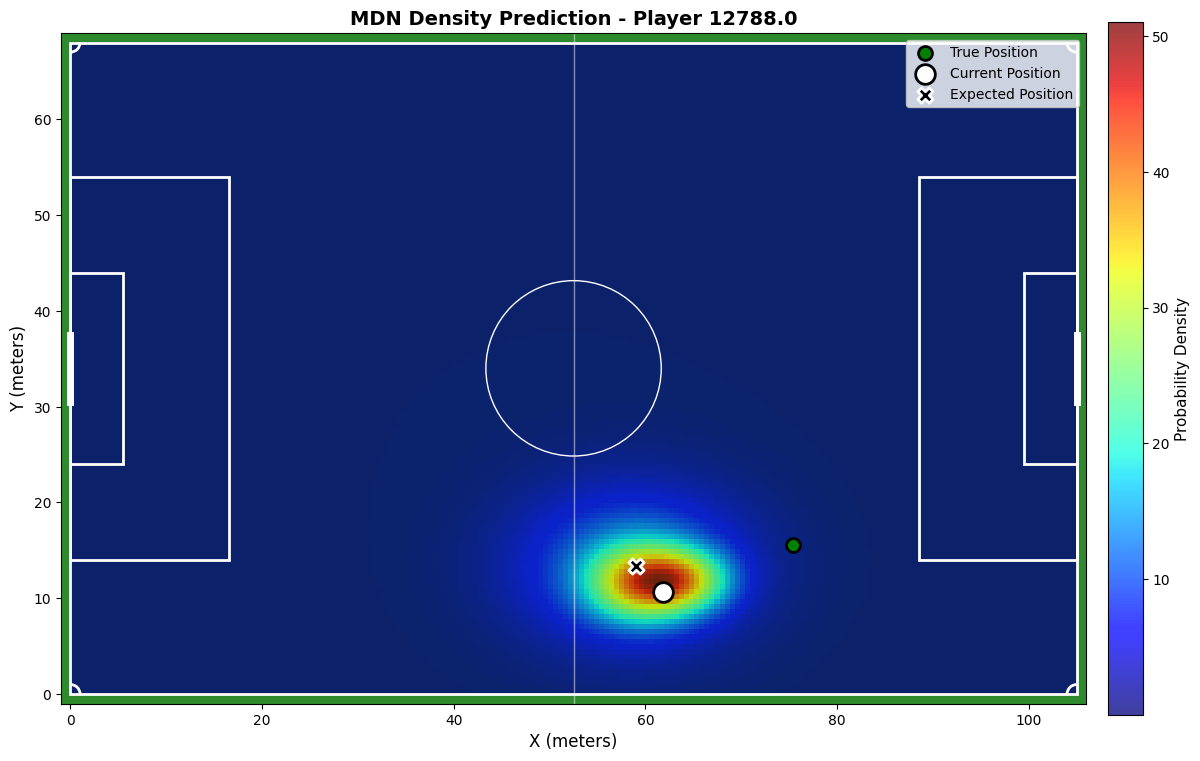

In [ ]:
# ============================================================================
# PREDICTION DEMONSTRATIONS
# ============================================================================
# Use existing output_dir or set default for local/Colab
print("\n" + "="*80)
print("🎯 PREDICTION DEMONSTRATIONS")
print("="*80)

available_matches = df['match_id'].unique()
print(f"\nAvailable matches: {available_matches}")

demo_match = available_matches[2]
demo_players = df[df['match_id'] == demo_match]['player_id'].unique()[:]
print(f"Using match {demo_match} | Demo players: {demo_players}")

# ── Example 1: Single player ────────────────────────────────────────────────
print("\n" + "="*80)
print("EXAMPLE 1: Single Player Prediction")
print("="*80)
model= loaded_mdn_model if MODEL_TYPE=="MDN_TCN" else reloaded_model_Classification
demo_player = demo_players[-2]


prediction_result = predict_for_player(
    model, df, demo_match, demo_player,
   scaler=scaler,start_frame=5470, top_k=5, return_all_probs=True,
)

if prediction_result:
    visualize_prediction(prediction_result)
else:
    print(f"❌ Could not predict for player {demo_player}")

# ── Example 2: Multiple players ─────────────────────────────────────────────
print("\n" + "="*80)
print("EXAMPLE 2: Multiple Players")
print("="*80)

multi_results = predict_for_multiple_players(
    model, df, demo_match, demo_players[:3],
    scaler=scaler, top_k=3
)

# ── Example 3: Quick prediction ──────────────────────────────────────────────
print("\n" + "="*80)
print("EXAMPLE 3: Quick Prediction")
print("="*80)

test_result = predict_player_next_zone(demo_match, demo_players[1])

# ── Save results ─────────────────────────────────────────────────────────────
print("\n💾 Saving prediction examples...")

if prediction_result:
    save_data = {
        'player_id': str(prediction_result['player_id']),
        'match_id': str(prediction_result['match_id']),
        'model_type': prediction_result['model_type'],
        'horizon_seconds': HORIZON_SECONDS,
        'current_frame': prediction_result.get('current_frame'),
        'prediction_frame': prediction_result.get('prediction_frame'),
    }

    if MODEL_TYPE == "MDN_TCN":
        save_data['predictions'] = prediction_result['predictions']
        save_data['expected_position'] = prediction_result['expected_position']
    elif CO_ORDINATES:
        save_data['predicted_x'] = prediction_result['predicted_x']
        save_data['predicted_y'] = prediction_result['predicted_y']
        save_data['predicted_zone'] = prediction_result['predicted_zone']
    else:
        save_data['top_zones'] = prediction_result['top_zones'].tolist()
        save_data['top_probabilities'] = prediction_result['top_probabilities'].tolist()
        save_data['top_coordinates'] = prediction_result['top_coordinates']

    # with open(f'{output_dir}/example_prediction.json', 'w') as f:
    #     json.dump(save_data, f, indent=2, default=str)

    # print(f"✓ Saved: {output_dir}/example_prediction.json")print("="*80)

print(f"Use predict_player_next_zone(match_id, player_id) for quick predictions")

print("\n" + "="*80)
print("✅ Prediction system ready!")

In [402]:
# ==== FINAL EVALUATION (Backend-Aware) ====
import numpy as np
from sklearn.metrics import accuracy_score, top_k_accuracy_score, classification_report


# Check if we are using MDN model
if MODEL_TYPE == "MDN_TCN":
    print("="*60)
    print("📊 MDN-SPECIFIC EVALUATION")
    print("="*60)
    print("Detected MDN model. Using probabilistic evaluation metrics (NLL, MAE) instead of classification accuracy.")
    print("To see classification metrics, you would need to convert coordinates to zones first.")
    
    # Use the MDN-specific evaluation function defined earlier
    # Use 'model' if 'trained_model' doesn't exist
    _eval_model = trained_model if 'trained_model' in dir() else loaded_mdn_model
    metrics = full_mdn_evaluation(_eval_model, test_loader.take(20), k=3)
    
elif not CO_ORDINATES and MODEL_TYPE != "MDN_TCN":
    # ────────────────────────────────────────────────────────────────────────
    # CLASSIFICATION EVALUATION LOGIC
    # ────────────────────────────────────────────────────────────────────────
    def evaluate_with_metrics(model, loader):
        """Backend-agnostic evaluation function."""
        all_preds = []
        all_labels = []
        all_probs = []

        if BACKEND == 'keras':
            print("Evaluating with Keras...")
            # Keras: Iterate through tf.data.Dataset
            for batch_x, batch_y in loader:
                probs = model.predict(batch_x, verbose=0)
                preds = np.argmax(probs, axis=1)

                all_probs.append(probs)
                all_preds.append(preds)
                all_labels.append(batch_y.numpy())

            all_probs = np.concatenate(all_probs, axis=0)
            all_preds = np.concatenate(all_preds, axis=0)
            all_labels = np.concatenate(all_labels, axis=0)

        # Calculate standard accuracy
        acc = accuracy_score(all_labels, all_preds)

        # Prepare full class list based on model output shape
        num_classes = all_probs.shape[1]
        all_classes = np.arange(num_classes)

        # Ensure k <= num_classes
        k = min(3, num_classes)

        # Pass the full label set to avoid ValueError
        top3_acc = top_k_accuracy_score(all_labels, all_probs, k=k, labels=all_classes)

        return acc, top3_acc, all_probs, all_preds, all_labels

    def evaluate_detailed(model, loader, zone_names):
        """Wrapper for detailed report using the generic evaluator."""
        _, _, _, preds, labels = evaluate_with_metrics(model, loader)

        print("\nDetailed Classification Report:")
        # Use a subset of labels if zone_names provided to avoid errors if some classes are missing
        unique_labels = np.unique(labels)
        target_names = [zone_names[i] for i in unique_labels] if zone_names else None

        report = classification_report(labels, preds, target_names=target_names, zero_division=0)
        print(report)

        return accuracy_score(labels, preds), preds, labels


    # ----------------------------------------------------------------------------
    # RUN EVALUATION
    # ----------------------------------------------------------------------------
    print("Evaluating model on test set...")

    # Use 'model' if 'trained_model' doesn't exist
    _eval_model = trained_model if 'trained_model' in dir() else model

    loader=test_loader.take(5)
    # Detailed evaluation
    test_acc, test_top3_acc, test_probs, _, _ = evaluate_with_metrics(_eval_model, loader)

    print(f"\nFinal Test Results:")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Top-3 Accuracy: {test_top3_acc:.4f}")

    # Generate zone names for detailed reporting
    zone_names = [f"Zone_{i}" for i in range(NUM_ZONES)]

    # Detailed classification report
    # We pass None for zone_names to let sklearn handle missing classes gracefully
    detailed_acc, test_preds, test_labels = evaluate_detailed(_eval_model, loader, None)

    # Performance summary
    print("\n" + "="*60)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*60)
    print(f"Grid Configuration: {N_ROWS} x {N_COLS} = {NUM_ZONES} zones")
    print(f"Prediction Horizon: {HORIZON_SECONDS} seconds ({HORIZON_FRAMES} frames)")
    print(f"Features Used: {len(FEATURE_COLS)}")
    print(f"Model Type: {MODEL_TYPE}")
    print(f"Backend: {BACKEND}")



    print("\nAccuracy Metrics:")
    print(f"- Top-1 Accuracy: {test_acc:.4f}")
    print(f"- Top-3 Accuracy: {test_top3_acc:.4f}")
    print("="*60)

📊 MDN-SPECIFIC EVALUATION
Detected MDN model. Using probabilistic evaluation metrics (NLL, MAE) instead of classification accuracy.
To see classification metrics, you would need to convert coordinates to zones first.
════════════════════════════════════════════════════════════
📊 MDN Evaluation
════════════════════════════════════════════════════════════
   Negative Log Likelihood: -2.0151

   MAE Metrics:
      Best-of-3 MAE:  0.0980
      Expected MAE:    0.1263
      Mode MAE:        0.1268

   Component Diversity:
      Active components: 3.20
      Entropy:           1.193
      Mode collapse:     0.0%
════════════════════════════════════════════════════════════


In [403]:
player_sequence, time_info = get_player_sequence_features(
        df, demo_match, demo_player, start_frame=5470
    )

In [404]:
import numpy as np

def inspect_mdn_output(model, player_sequence, top_k=5):
    """Inspect MDN model output (pi, mu, sigma) for the player sequence prediction"""
    # Expand dimensions to match model's input shape
    input_tensor = np.expand_dims(player_sequence, axis=0)
    
    # Get MDN output
    outputs = model(input_tensor, training=False)
    
    pi = outputs['pi'].numpy()[0]  # Mixture weights
    mu = outputs['mu'].numpy()[0]  # Means (x, y)
    sigma = outputs['sigma'].numpy()[0]  # Standard deviations
    
    print("Mixture weights (pi):", pi)
    print("Means (mu):", mu)
    print("Standard deviations (sigma):", sigma)

    # If top_k is requested, sort and print the top_k predictions
    sorted_indices = np.argsort(pi)[::-1][:top_k]
    for idx in sorted_indices:
        print(f"Component {idx}:")
        print(f"  Probability (pi): {pi[idx]}")
        print(f"  Mean (mu): {mu[idx]}")
        print(f"  Std Dev (sigma): {sigma[idx]}")

    return pi, mu, sigma

# Example usage:
# Assuming player_sequence is the input sequence for a player
# model: trained MDN model
pi, mu, sigma = inspect_mdn_output(model, player_sequence)

h:\anaconda3\envs\cuda-env-Keras-V3\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['sequence_input']
Received: inputs=Tensor(shape=(1, 100, 24))
  warnings.warn(msg)


Mixture weights (pi): [2.5036648e-05 3.8703405e-05 3.8473591e-01 1.7027511e-01 2.3169529e-04
 9.0935729e-02 3.5375774e-01]
Means (mu): [[0.3863745  0.16196272]
 [0.4610471  0.4331803 ]
 [0.54479456 0.60906744]
 [0.5857885  0.6687794 ]
 [0.5713712  0.3592803 ]
 [0.4994347  0.56787205]
 [0.53520644 0.5909779 ]]
Standard deviations (sigma): [[0.472356   0.357691  ]
 [0.18300816 0.23922478]
 [0.03954289 0.049362  ]
 [0.03659876 0.04560278]
 [0.21980964 0.1943171 ]
 [0.20697528 0.21722896]
 [0.07177225 0.09405772]]
Component 2:
  Probability (pi): 0.38473591208457947
  Mean (mu): [0.54479456 0.60906744]
  Std Dev (sigma): [0.03954289 0.049362  ]
Component 6:
  Probability (pi): 0.35375773906707764
  Mean (mu): [0.53520644 0.5909779 ]
  Std Dev (sigma): [0.07177225 0.09405772]
Component 3:
  Probability (pi): 0.17027510702610016
  Mean (mu): [0.5857885 0.6687794]
  Std Dev (sigma): [0.03659876 0.04560278]
Component 5:
  Probability (pi): 0.09093572944402695
  Mean (mu): [0.4994347  0.5678720

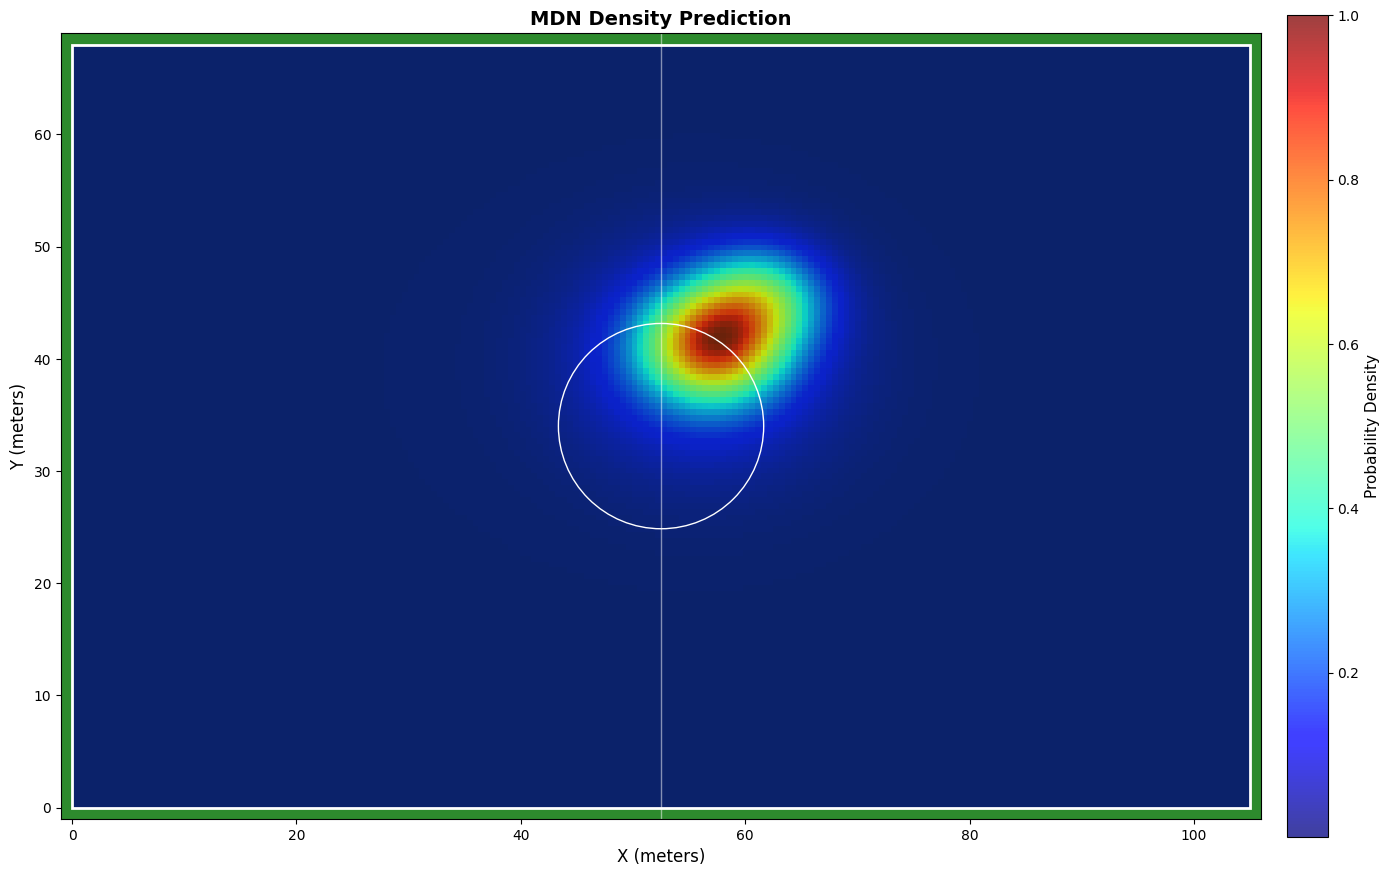

In [405]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import numpy as np

def plot_mdn_density(pi, mu, sigma, PITCH_LENGTH=105, PITCH_WIDTH=68):
    """Visualize the MDN density as a heatmap on a football field"""
    
    # Create grid for density calculation
    grid_res_x = 200
    grid_res_y = 130
    x = np.linspace(0, 1, grid_res_x)
    y = np.linspace(0, 1, grid_res_y)
    X, Y = np.meshgrid(x, y)

    # Calculate the density based on the MDN components
    density = np.zeros_like(X)
    
    for k in range(len(pi)):
        mu_x = mu[k, 0]
        mu_y = mu[k, 1]
        sigma_x = max(sigma[k, 0], 1e-4)  # Ensure no division by zero
        sigma_y = max(sigma[k, 1], 1e-4)

        # 2D Gaussian distribution for each component
        gaussian = (1 / (2 * np.pi * sigma_x * sigma_y)) * np.exp(
            -(((X - mu_x) ** 2) / (2 * sigma_x**2) + ((Y - mu_y) ** 2) / (2 * sigma_y**2))
        )
        
        density += pi[k] * gaussian

    # Normalize the density
    density /= np.max(density)

    # Plot the density
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(-1, PITCH_LENGTH + 1)
    ax.set_ylim(-1, PITCH_WIDTH + 1)
    ax.set_facecolor('#2d8a2d')
    
    # Draw the pitch boundary and other elements
    ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, edgecolor='white', linewidth=2))
    ax.axvline(x=PITCH_LENGTH / 2, color='white', linewidth=1, linestyle='-', alpha=0.5)
    ax.add_patch(plt.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, color='white', fill=False, linewidth=1))

    # Visualize the density as a heatmap
    heatmap = ax.imshow(
        density,
        extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH],
        origin='lower',
        cmap='jet',  # Color map: Blue → Green → Yellow → Red
        alpha=0.75,
        aspect='auto'
    )
    
    cbar = plt.colorbar(heatmap, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Probability Density", fontsize=11)

    ax.set_xlabel('X (meters)', fontsize=12)
    ax.set_ylabel('Y (meters)', fontsize=12)
    ax.set_aspect('equal')
    ax.set_title(f"MDN Density Prediction", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming pi, mu, sigma are extracted from the MDN output
plot_mdn_density(pi, mu, sigma)